# Анализ информативности признаков

Этот notebook предназначен только для чтения уже рассчитанных parquet-результатов и построения визуализаций. Тяжёлые расчёты выполняются серверным скриптом `build_feature_informativeness.py`; здесь мы не пересчитываем метрики по исходному датасету.

Основная идея анализа: признаки полезно оценивать не по одной цифре, а по нескольким независимым признакам качества. Мы смотрим описательную статистику, связь с целевой доходностью на горизонтах 10/20/30 минут, поведение доходности по децилям признака, статистические тесты различий между группами и дублирование признаков между собой.

## 1. Настройки чтения результатов

По умолчанию notebook читает локальную папку `analysis/feature_informativeness`, куда серверный скрипт сохраняет копии parquet-файлов. Если нужно читать напрямую из S3, переключите `READ_FROM_S3 = True` и проверьте `S3_BUCKET`/`S3_PREFIX`.

Ожидаемая структура результатов:

- `feature_summary.parquet` — описательная статистика признаков;
- `correlation_matrix.parquet` — список пар признаков с Pearson/Spearman корреляциями;
- `target_10/feature_metrics.parquet`, `target_20/...`, `target_30/...` — связь признака с таргетом;
- `target_*/feature_bins.parquet` — распределение доходности по децилям признака;
- `target_*/feature_tests.parquet` — статистические тесты различий между группами признака.

In [1]:
from __future__ import annotations

import io
import os
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

READ_FROM_S3 = False
LOCAL_RESULTS_DIR = Path("analysis/feature_informativeness")
if not LOCAL_RESULTS_DIR.exists() and Path("feature_summary.parquet").exists():
    LOCAL_RESULTS_DIR = Path(".")

S3_BUCKET = "binance-data-downloader"
S3_PREFIX = "analysis/feature_informativeness"

HORIZONS = ["target_10", "target_20", "target_30"]
TOP_N = 25
ABS_CORR_DUPLICATE_THRESHOLD = 0.95

plt.style.use("default")

In [2]:
def make_s3_client():
    return boto3.client(
        "s3",
        endpoint_url=os.getenv("YC_ENDPOINT"),
        region_name=os.getenv("YC_REGION"),
        aws_access_key_id=os.getenv("YC_ACCESS_KEY_ID"),
        aws_secret_access_key=os.getenv("YC_SECRET_ACCESS_KEY"),
    )


def read_result_parquet(relative_path: str) -> pd.DataFrame:
    if READ_FROM_S3:
        key = f"{S3_PREFIX.strip('/')}/{relative_path}"
        body = make_s3_client().get_object(Bucket=S3_BUCKET, Key=key)["Body"].read()
        return pd.read_parquet(io.BytesIO(body))

    path = LOCAL_RESULTS_DIR / relative_path
    return pd.read_parquet(path)


def pct(series: pd.Series) -> pd.Series:
    return series.astype(float) * 100.0


def barh(frame: pd.DataFrame, value: str, label: str, title: str, xlabel: str, n: int = TOP_N):
    data = frame.head(n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(5, 0.32 * len(data))))
    ax.barh(data[label], data[value])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.25)
    plt.show()


def safe_abs_column(frame: pd.DataFrame, column: str) -> pd.Series:
    return frame[column].abs().replace([np.inf, -np.inf], np.nan)

## 2. Загрузка parquet-результатов

На этом шаге мы загружаем только компактные аналитические артефакты. Если здесь возникает ошибка, обычно причина не в расчётах, а в том, что серверный скрипт ещё не был запущен, результаты лежат в другом prefix, или локальная папка не синхронизирована.

In [3]:
feature_summary = read_result_parquet("feature_summary.parquet")
correlation_pairs = read_result_parquet("correlation_matrix.parquet")

metrics_by_horizon = {
    horizon: read_result_parquet(f"{horizon}/feature_metrics.parquet")
    for horizon in HORIZONS
}
bins_by_horizon = {
    horizon: read_result_parquet(f"{horizon}/feature_bins.parquet")
    for horizon in HORIZONS
}
tests_by_horizon = {
    horizon: read_result_parquet(f"{horizon}/feature_tests.parquet")
    for horizon in HORIZONS
}

print("feature_summary", feature_summary.shape)
print("correlation_pairs", correlation_pairs.shape)
for horizon in HORIZONS:
    print(horizon, "metrics", metrics_by_horizon[horizon].shape, "bins", bins_by_horizon[horizon].shape, "tests", tests_by_horizon[horizon].shape)

feature_summary (122, 14)
correlation_pairs (7381, 4)
target_10 metrics (122, 11) bins (1151, 23) tests (122, 7)
target_20 metrics (122, 11) bins (1151, 23) tests (122, 7)
target_30 metrics (122, 11) bins (1151, 23) tests (122, 7)


## 3. Контроль качества признаков

Перед тем как ранжировать признаки по связи с таргетом, важно проверить базовую пригодность самих признаков.

Что ищем:

- много пропусков — признак может быть полезен, но его применимость ограничена;
- один или почти один уникальный уровень — признак почти не несёт информации;
- экстремальная асимметрия и эксцесс — возможны редкие выбросы, которые могут создавать ложную корреляцию;
- ошибки в строке `error` — конкретный признак не удалось обработать на сервере, его нельзя интерпретировать без разбора причины.

In [4]:
summary = feature_summary.copy()
summary["missing_rate"] = summary["missing"] / (summary["observations"] + summary["missing"])
summary["is_constant"] = summary["unique_values"].fillna(0).le(1)

display(summary.sort_values(["is_constant", "missing_rate"], ascending=[False, False]).head(20))

quality_overview = pd.DataFrame(
    {
        "features": [len(summary)],
        "features_with_errors": [summary["error"].fillna("").ne("").sum() if "error" in summary else 0],
        "constant_features": [summary["is_constant"].sum()],
        "missing_rate_gt_5pct": [summary["missing_rate"].gt(0.05).sum()],
        "missing_rate_gt_20pct": [summary["missing_rate"].gt(0.20).sum()],
    }
)
display(quality_overview)

,feature,observations,missing,unique_values,mean,std,min,max,median,q25,q75,skew,kurtosis,error,missing_rate,is_constant
117,is_weekend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xo...",NaN,True
118,is_asia_open,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xo...",NaN,True
119,is_cboe_europe_open,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xo...",NaN,True
120,is_europe_open,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xo...",NaN,True
121,is_us_open,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xo...",NaN,True
0,ada_log_return_lag_1,3157740.0,0.0,1003767.0,5.206803e-07,0.001588,-0.246990,0.160251,0.0,-0.000597,0.000597,-2.828080,798.832583,,0.0,False
1,ada_log_return_lag_2,3157740.0,0.0,1003767.0,5.209139e-07,0.001588,-0.246990,0.160251,0.0,-0.000597,0.000597,-2.828080,798.832371,,0.0,False
2,ada_log_return_lag_3,3157740.0,0.0,1003767.0,5.214064e-07,0.001588,-0.246990,0.160251,0.0,-0.000597,0.000597,-2.828083,798.833202,,0.0,False
3,ada_log_return_lag_5,3157740.0,0.0,1003767.0,5.209139e-07,0.001588,-0.246990,0.160251,0.0,-0.000597,0.000597,-2.828083,798.833631,,0.0,False
4,ada_log_return_lag_10,3157740.0,0.0,1003767.0,5.219769e-07,0.001588,-0.246990,0.160251,0.0,-0.000597,0.000597,-2.828088,798.837826,,0.0,False


,features,features_with_errors,constant_features,missing_rate_gt_5pct,missing_rate_gt_20pct
0,122,5,5,0,0


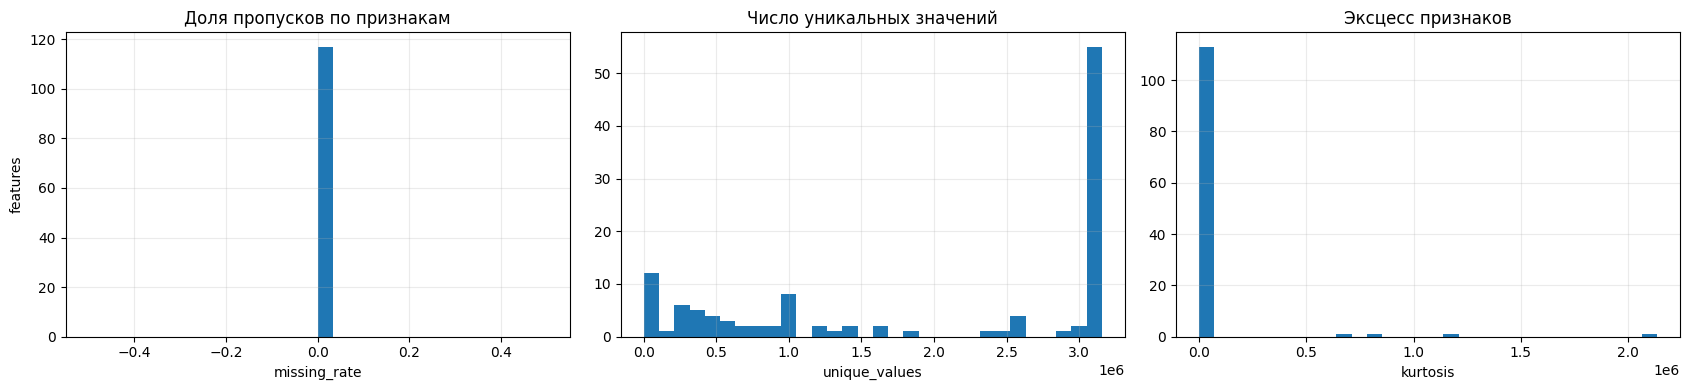

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(summary["missing_rate"].dropna(), bins=30)
axes[0].set_title("Доля пропусков по признакам")
axes[0].set_xlabel("missing_rate")
axes[0].set_ylabel("features")

axes[1].hist(summary["unique_values"].dropna(), bins=30)
axes[1].set_title("Число уникальных значений")
axes[1].set_xlabel("unique_values")

axes[2].hist(summary["kurtosis"].replace([np.inf, -np.inf], np.nan).dropna(), bins=30)
axes[2].set_title("Эксцесс признаков")
axes[2].set_xlabel("kurtosis")

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Метрики связи признаков с таргетами

Здесь мы объединяем `feature_metrics.parquet` по всем горизонтам.

Как читать метрики:

- `pearson` — линейная связь. Полезен, если эффект примерно линейный, но плохо ловит нелинейность;
- `spearman` — монотонная связь через ранги. Часто устойчивее к выбросам;
- `mutual_information` — общая зависимость между признаком и таргетом после дискретизации. Не показывает направление, зато может ловить нелинейность;
- `distance_correlation` — зависимость более общего вида. В конфиге она может считаться на выборке, потому что полная оценка дорогая по памяти;
- `p-value` — статистическая значимость корреляции, но при большом числе наблюдений даже маленький эффект может стать статистически значимым. Поэтому p-value нельзя использовать без размера эффекта.

Практически хорошие признаки обычно проявляются сразу в нескольких колонках и не исчезают при переходе от `target_10` к `target_20`/`target_30`.

In [6]:
metrics = []
for horizon, frame in metrics_by_horizon.items():
    item = frame.copy()
    item["horizon"] = horizon
    item["abs_pearson"] = safe_abs_column(item, "pearson")
    item["abs_spearman"] = safe_abs_column(item, "spearman")
    metrics.append(item)
metrics = pd.concat(metrics, ignore_index=True)

display(metrics.head())
display(metrics.groupby("horizon")[["pearson", "spearman", "mutual_information", "distance_correlation"]].describe().round(6))

,feature,observations,pearson,pearson_p_value,spearman,spearman_p_value,mutual_information,distance_correlation,distance_correlation_rows,distance_correlation_sampled,error,horizon,abs_pearson,abs_spearman
0,ada_log_return_lag_1,3157740,-0.016598,3.243890e-191,-0.020671,1.977772e-295,0.036879,0.116563,5000,True,,target_10,0.016598,0.020671
1,ada_log_return_lag_2,3157740,-0.019176,1.523350e-254,-0.013783,1.702092e-132,0.035548,0.131484,5000,True,,target_10,0.019176,0.013783
2,ada_log_return_lag_3,3157740,-0.014232,3.983050e-141,-0.010030,4.647085e-71,0.034693,0.119072,5000,True,,target_10,0.014232,0.010030
3,ada_log_return_lag_5,3157740,-0.014336,3.676925e-143,-0.009228,1.938556e-60,0.033805,0.111258,5000,True,,target_10,0.014336,0.009228
4,ada_log_return_lag_10,3157740,-0.001596,4.564539e-03,-0.005113,1.026776e-19,0.032254,0.111743,5000,True,,target_10,0.001596,0.005113


pearson                                                                       spearman                                                              \
            count      mean       std       min       25%       50%       75%       max    count      mean       std       min       25%       50%       75%   
horizon                                                                                                                                                        
target_10   122.0  0.003878  0.022862 -0.048742 -0.009697 -0.000778  0.007287  0.061265    122.0 -0.006478  0.016482 -0.042781 -0.019503  0.000609  0.007756   
target_20   122.0  0.005637  0.027222 -0.054278 -0.010265 -0.000749  0.008026  0.072312    122.0 -0.006015  0.018074 -0.046878 -0.017994 -0.000687  0.008368   
target_30   122.0  0.006966  0.031043 -0.054601 -0.009833 -0.001053  0.009860  0.083856    122.0 -0.005610  0.018210 -0.046273 -0.017871 -0.001126  0.008613   

                    mutual_information                                                                  distance_correlation                                \
                max              count      mean       std  min       25%       50%       75%       max                count      mean       std       min   
horizon                                                                                                                                                      
target_10  0.011457              122.0  0.027928  0.034434 -0.0  0.002087  0.006132  0.041531  0.115849                122.0  0.111359  0.085589  0.012486   
target_20  0.015004              122.0  0.026091  0.032236  0.0  0.002011  0.005857  0.038230  0.110506                122.0  0.108710  0.086303  0.010195   
target_30  0.017416              122.0  0.024684  0.030527  0.0  0.001881  0.005590  0.036323  0.105498                122.0  0.106496  0.085795  0.012296   

                                                   
                25%       50%       75%       max  
horizon                                            
target_10  0.046107  0.074138  0.138274  0.293304  
target_20  0.041848  0.068502  0.140636  0.296800  
target_30  0.042271  0.060271  0.134270  0.292702


=== target_10: top by Mutual Information ===


,feature,observations,mutual_information,spearman,pearson,distance_correlation
40,ada_realized_volatility_60m,3157740,0.115849,0.008976,0.044037,0.291694
35,ada_return_std_60m,3157740,0.115220,0.008898,0.043575,0.290744
39,ada_realized_volatility_30m,3157740,0.114765,0.009258,0.054841,0.293304
34,ada_return_std_30m,3157740,0.113633,0.009051,0.054396,0.292099
38,ada_realized_volatility_20m,3157740,0.111459,0.009921,0.054242,0.291507
33,ada_return_std_20m,3157740,0.109761,0.009643,0.053202,0.290157
58,ada_log_range_30m,3157740,0.102835,0.011457,0.057797,0.281810
63,ada_log_range_60m,3157740,0.102305,0.010918,0.049638,0.278567
37,ada_realized_volatility_10m,3157740,0.101457,0.009819,0.052763,0.278714
53,ada_log_range_20m,3157740,0.101140,0.011238,0.058289,0.281634


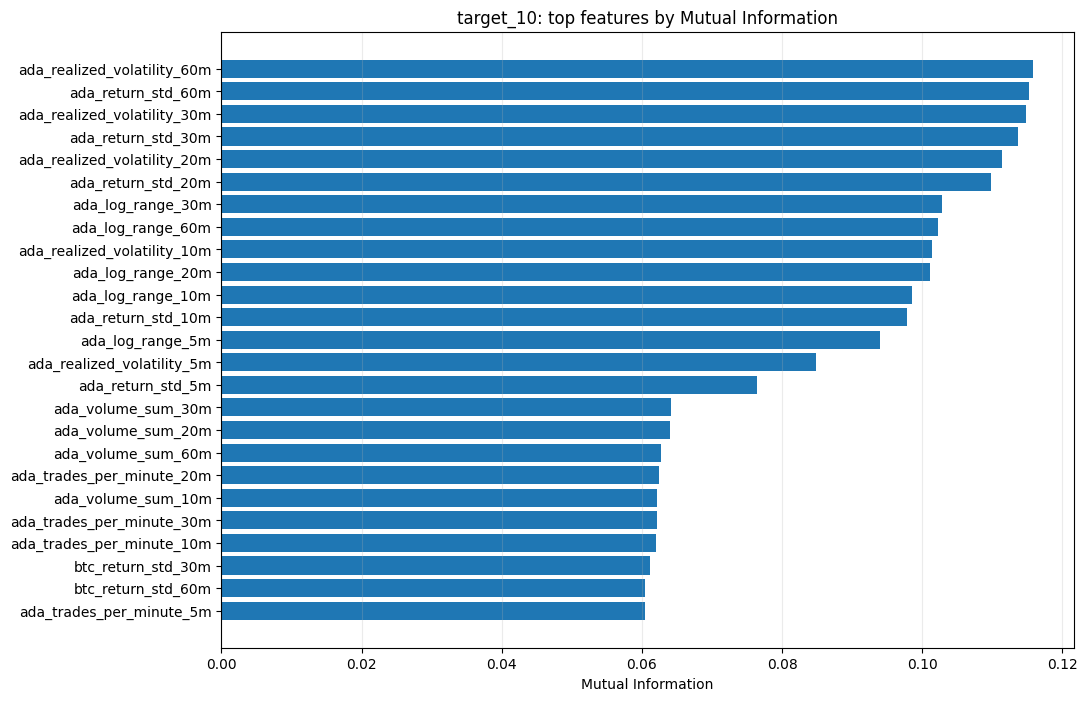

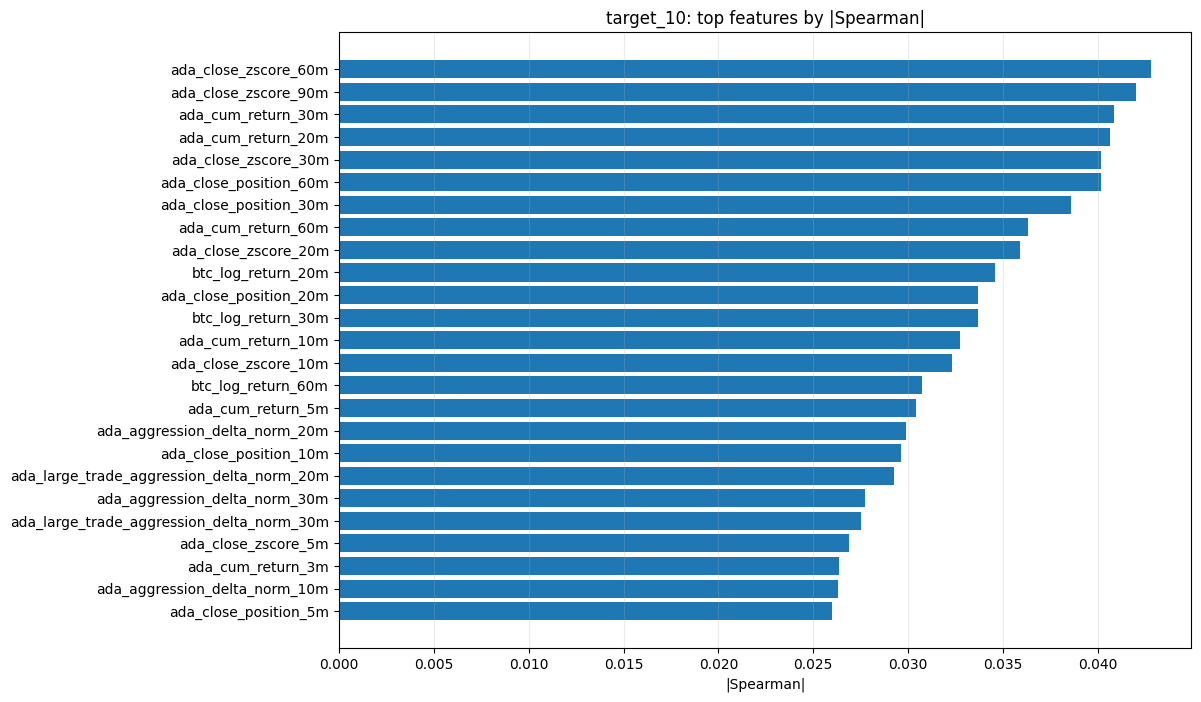

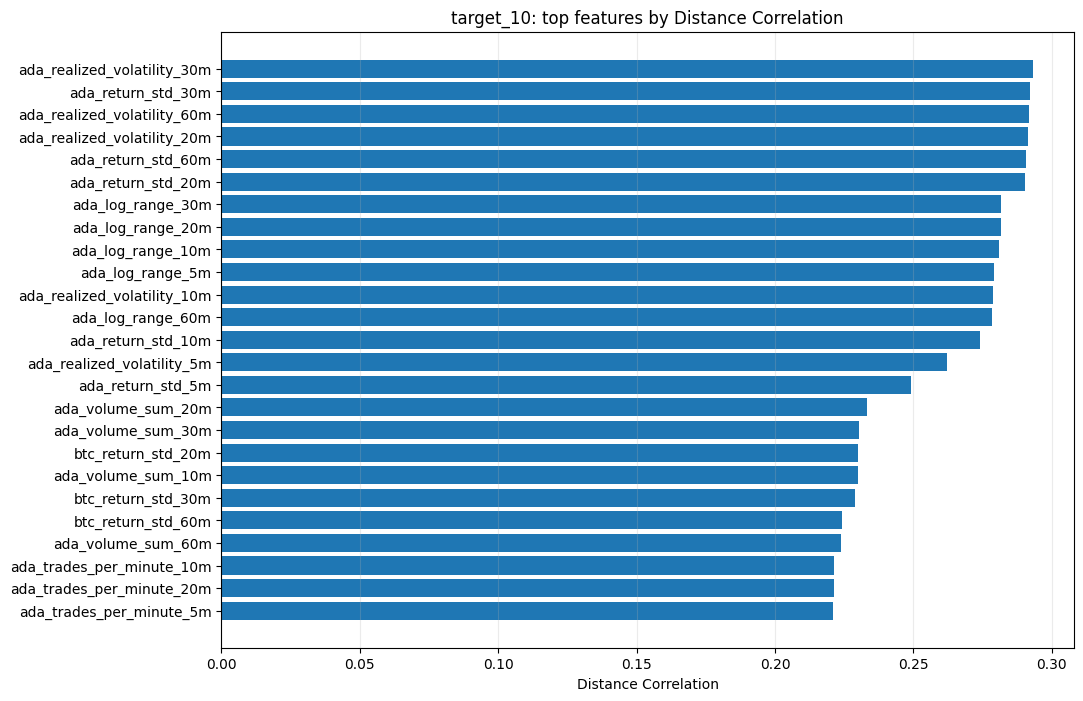


=== target_20: top by Mutual Information ===


,feature,observations,mutual_information,spearman,pearson,distance_correlation
162,ada_realized_volatility_60m,3157740,0.110506,0.012910,0.054413,0.296800
157,ada_return_std_60m,3157740,0.110016,0.012807,0.053841,0.296125
161,ada_realized_volatility_30m,3157740,0.107881,0.012913,0.066844,0.292997
156,ada_return_std_30m,3157740,0.107017,0.012685,0.066173,0.292340
160,ada_realized_volatility_20m,3157740,0.104392,0.013389,0.070741,0.286062
155,ada_return_std_20m,3157740,0.102987,0.013114,0.070077,0.285624
185,ada_log_range_60m,3157740,0.095439,0.014637,0.060240,0.277260
180,ada_log_range_30m,3157740,0.095382,0.014749,0.070020,0.274041
175,ada_log_range_20m,3157740,0.094397,0.014860,0.072312,0.270697
159,ada_realized_volatility_10m,3157740,0.094078,0.013653,0.066579,0.272907


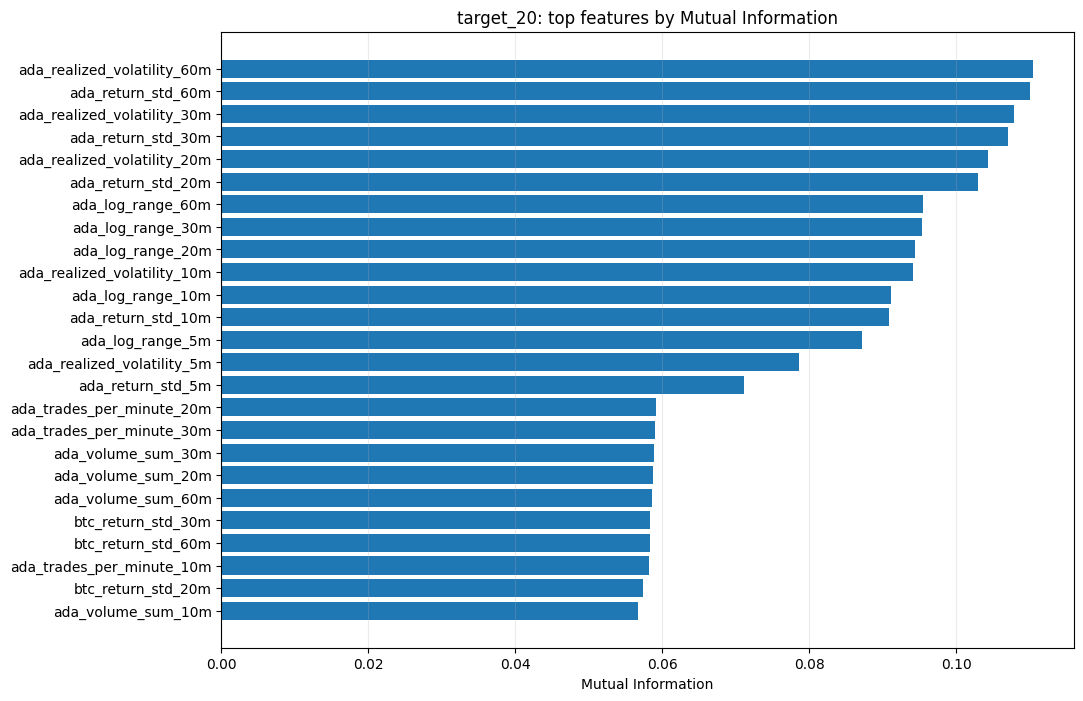

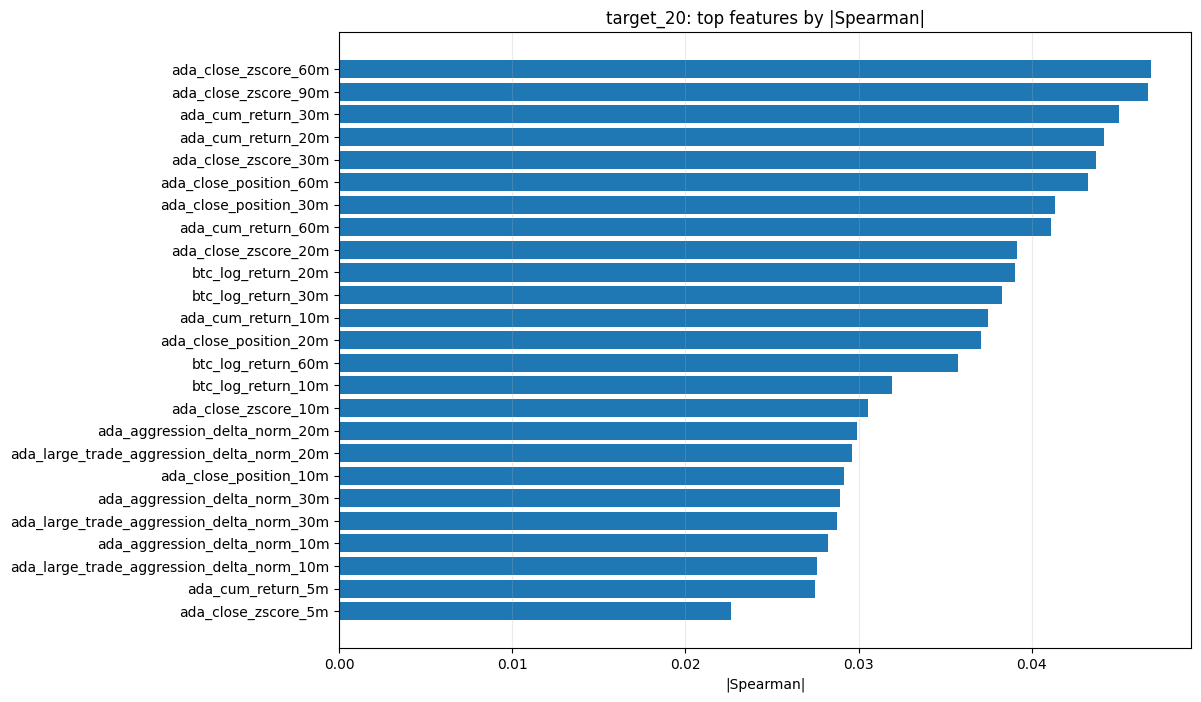

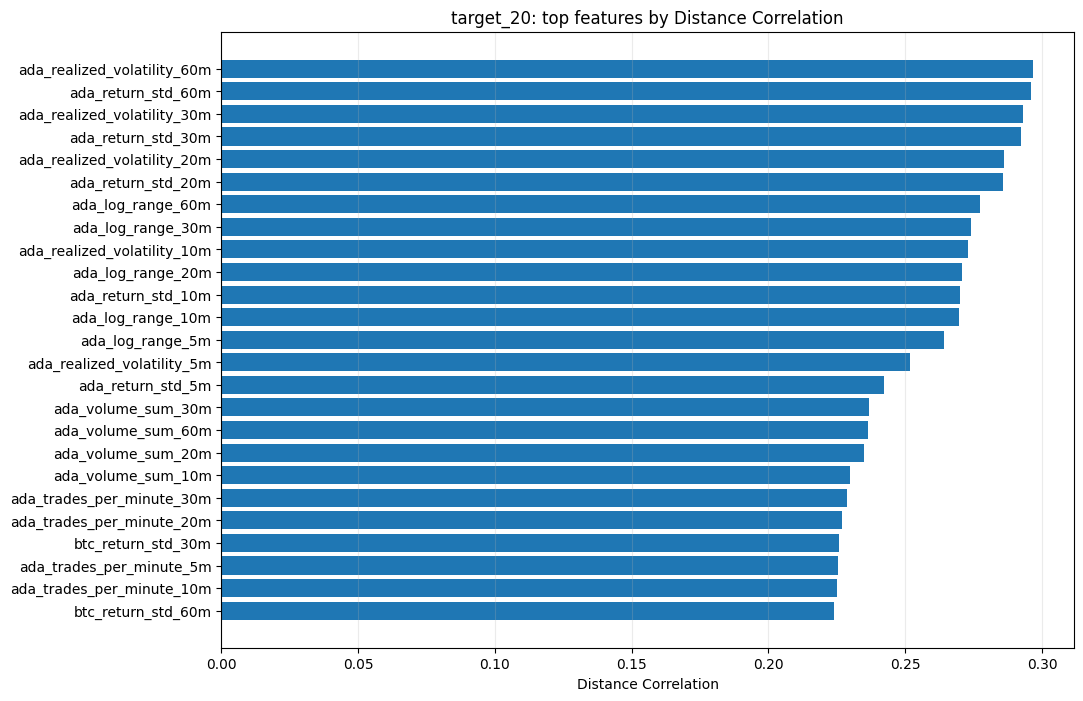


=== target_30: top by Mutual Information ===


,feature,observations,mutual_information,spearman,pearson,distance_correlation
284,ada_realized_volatility_60m,3157740,0.105498,0.015386,0.060250,0.292702
279,ada_return_std_60m,3157740,0.105078,0.015283,0.059570,0.292184
283,ada_realized_volatility_30m,3157740,0.102112,0.015085,0.073589,0.289693
278,ada_return_std_30m,3157740,0.101308,0.014819,0.072541,0.288474
282,ada_realized_volatility_20m,3157740,0.098499,0.015366,0.077865,0.286007
277,ada_return_std_20m,3157740,0.097260,0.015025,0.076528,0.284950
307,ada_log_range_60m,3157740,0.090396,0.016889,0.066604,0.273628
302,ada_log_range_30m,3157740,0.090186,0.016745,0.078246,0.274828
297,ada_log_range_20m,3157740,0.089168,0.016515,0.081084,0.269576
281,ada_realized_volatility_10m,3157740,0.088955,0.015227,0.079495,0.278812


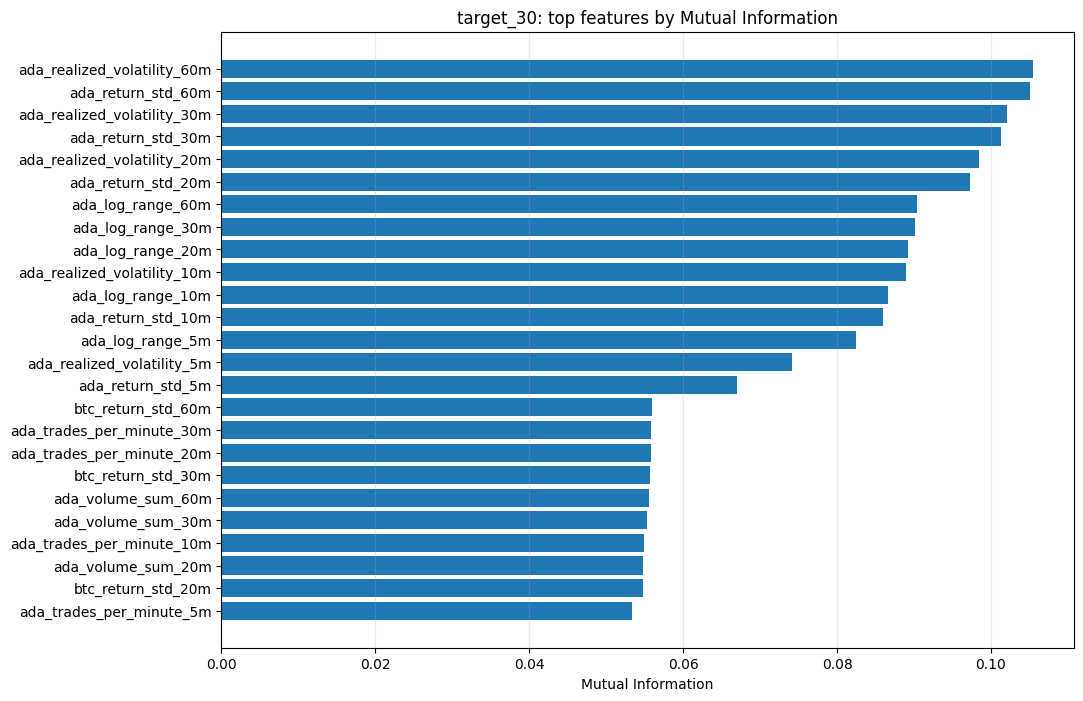

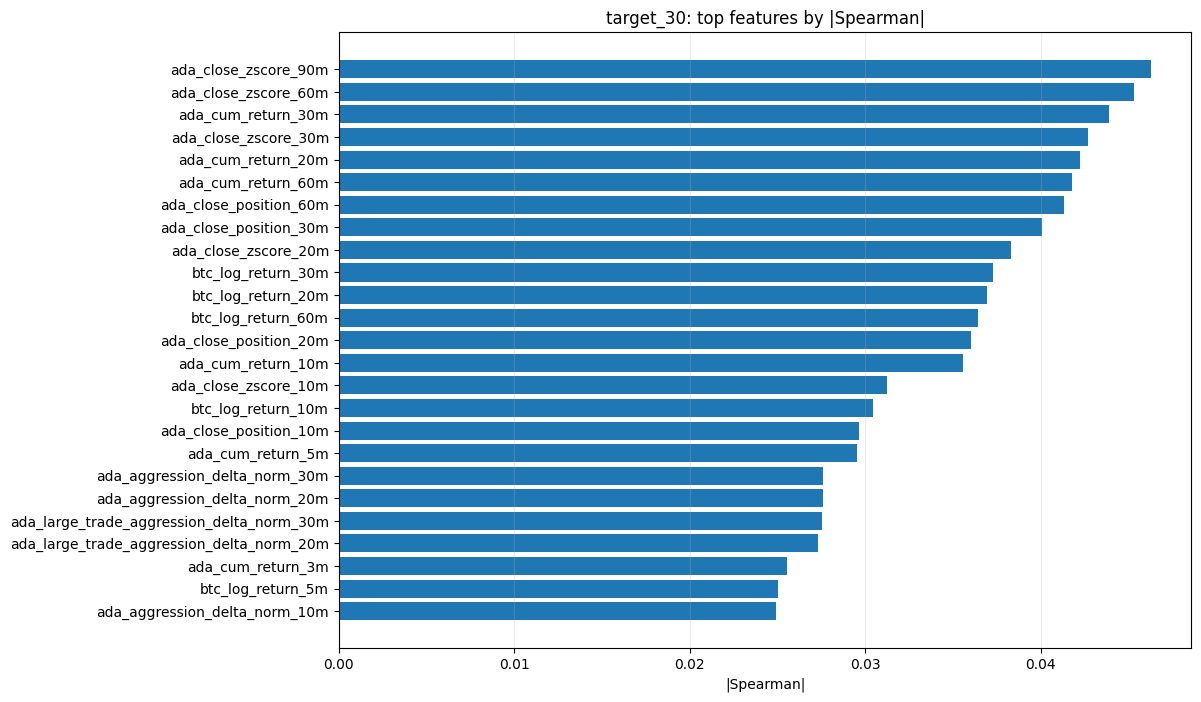

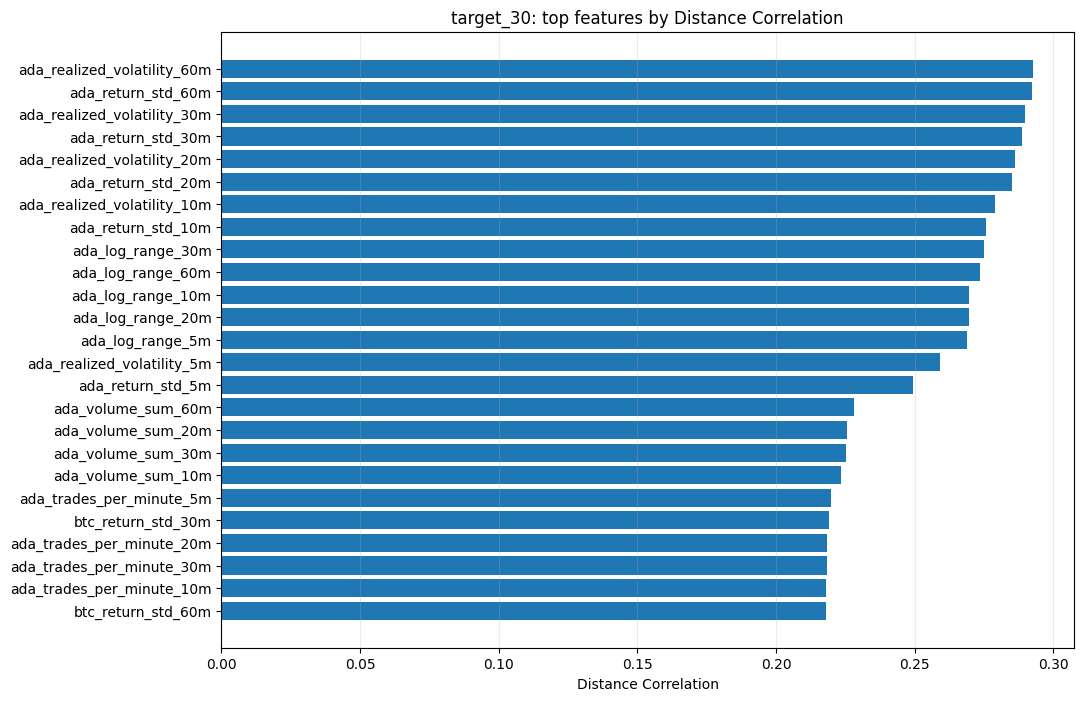

In [7]:
for horizon in HORIZONS:
    frame = metrics.query("horizon == @horizon").copy()
    top_mi = frame.sort_values("mutual_information", ascending=False)
    top_spearman = frame.sort_values("abs_spearman", ascending=False)
    top_dcor = frame.sort_values("distance_correlation", ascending=False)

    print(f"\n=== {horizon}: top by Mutual Information ===")
    display(top_mi[["feature", "observations", "mutual_information", "spearman", "pearson", "distance_correlation"]].head(15))

    barh(top_mi, "mutual_information", "feature", f"{horizon}: top features by Mutual Information", "Mutual Information")
    barh(top_spearman, "abs_spearman", "feature", f"{horizon}: top features by |Spearman|", "|Spearman|")
    barh(top_dcor, "distance_correlation", "feature", f"{horizon}: top features by Distance Correlation", "Distance Correlation")

## 5. Сводный рейтинг признаков

Одна метрика может давать перекос. Поэтому ниже строится простой агрегированный рейтинг: каждая метрика нормируется внутри горизонта, затем усредняется. Это не модель и не финальное решение, а удобный способ поднять наверх признаки, которые стабильно выглядят сильными по нескольким независимым критериям.

Особенно интересны признаки, которые:

- имеют высокий средний score;
- появляются в топе на нескольких горизонтах;
- имеют не только MI, но и заметный `abs_spearman` или `distance_correlation`;
- не являются почти полными дублями других признаков.

,feature,mean_score,min_score,max_score,horizons_seen,mean_abs_spearman,mean_mi,mean_dcor
0,ada_realized_volatility_30m,0.783599,0.773499,0.788978,3,0.012419,0.108253,0.291998
1,ada_realized_volatility_20m,0.782698,0.766232,0.791421,3,0.012892,0.104783,0.287859
2,ada_return_std_30m,0.776862,0.766943,0.782234,3,0.012185,0.107319,0.290971
3,ada_return_std_20m,0.773418,0.755463,0.783097,3,0.012594,0.103336,0.286910
4,ada_log_range_20m,0.765948,0.759509,0.770521,3,0.014205,0.094902,0.273969
5,ada_log_range_30m,0.765805,0.762601,0.770392,3,0.014317,0.096134,0.276893
6,ada_log_range_10m,0.763120,0.754179,0.771804,3,0.013936,0.092147,0.273373
7,ada_realized_volatility_60m,0.748182,0.728525,0.761508,3,0.012424,0.110618,0.293732
8,ada_realized_volatility_10m,0.745250,0.726603,0.766499,3,0.012900,0.094830,0.276811
9,ada_return_std_60m,0.743904,0.723968,0.757462,3,0.012329,0.110105,0.293017


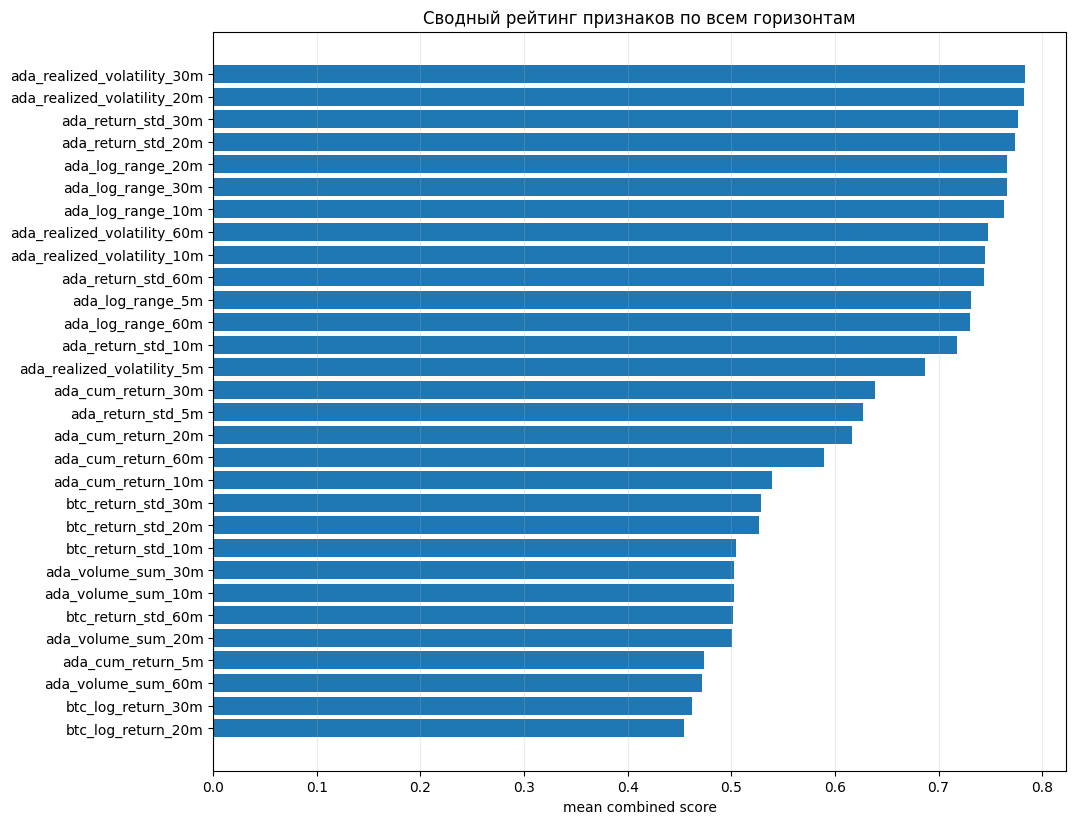

In [8]:
score_parts = []
score_columns = ["abs_pearson", "abs_spearman", "mutual_information", "distance_correlation"]

for horizon, frame in metrics.groupby("horizon"):
    scored = frame.copy()
    for column in score_columns:
        values = scored[column].replace([np.inf, -np.inf], np.nan)
        min_value = values.min()
        max_value = values.max()
        if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
            scored[f"score_{column}"] = np.nan
        else:
            scored[f"score_{column}"] = (values - min_value) / (max_value - min_value)
    scored["combined_score"] = scored[[f"score_{column}" for column in score_columns]].mean(axis=1)
    score_parts.append(scored)

scored_metrics = pd.concat(score_parts, ignore_index=True)

feature_rank = (
    scored_metrics.groupby("feature")
    .agg(
        mean_score=("combined_score", "mean"),
        min_score=("combined_score", "min"),
        max_score=("combined_score", "max"),
        horizons_seen=("horizon", "nunique"),
        mean_abs_spearman=("abs_spearman", "mean"),
        mean_mi=("mutual_information", "mean"),
        mean_dcor=("distance_correlation", "mean"),
    )
    .sort_values("mean_score", ascending=False)
    .reset_index()
)

display(feature_rank.head(30))
barh(feature_rank, "mean_score", "feature", "Сводный рейтинг признаков по всем горизонтам", "mean combined score", n=30)

## 6. Тепловая карта устойчивости по горизонтам

Следующий график показывает, сохраняется ли информативность признака при изменении горизонта прогнозирования. Это важно: признак, который работает только на одном горизонте, может отражать очень локальный эффект; признак, устойчивый на 10/20/30 минутах, обычно интереснее для дальнейшего изучения.

На карте используются агрегированные score по каждому горизонту, а признаки отсортированы по среднему score.

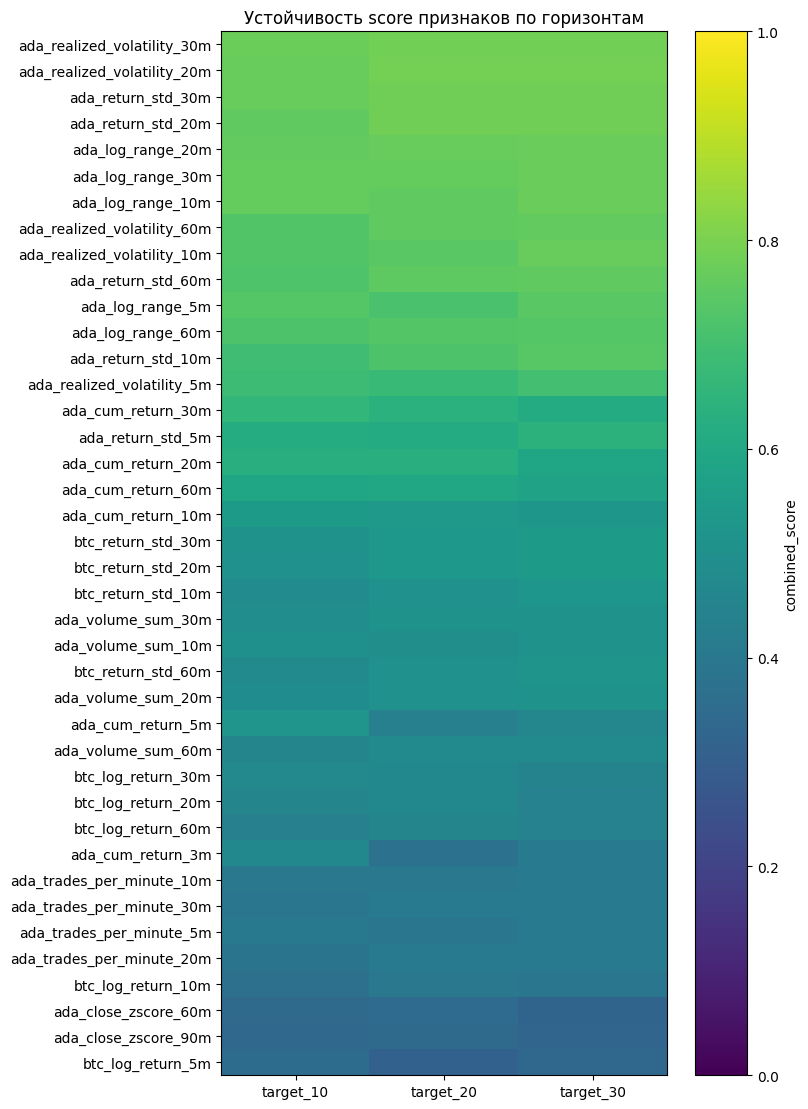

In [9]:
top_features = feature_rank.head(40)["feature"].tolist()
heatmap_data = (
    scored_metrics[scored_metrics["feature"].isin(top_features)]
    .pivot(index="feature", columns="horizon", values="combined_score")
    .reindex(top_features)
)

fig, ax = plt.subplots(figsize=(8, max(7, 0.28 * len(heatmap_data))))
image = ax.imshow(heatmap_data.to_numpy(), aspect="auto", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(heatmap_data.columns)), heatmap_data.columns)
ax.set_yticks(np.arange(len(heatmap_data.index)), heatmap_data.index)
ax.set_title("Устойчивость score признаков по горизонтам")
fig.colorbar(image, ax=ax, label="combined_score")
plt.tight_layout()
plt.show()

## 7. Доходность по децилям признака

Это один из самых важных блоков для интерпретации. Даже если признак имеет высокую MI или корреляцию, нужно увидеть, как именно меняется распределение доходности при переходе от низких значений признака к высоким.

Что смотрим:

- монотонно ли растёт/падает средняя или медианная доходность;
- есть ли эффект только в крайних децилях;
- растёт ли риск: стандартное отклонение, хвостовые перцентили, вероятность больших абсолютных доходностей;
- согласованы ли `mean` и `median`. Если среднее сильно отличается от медианы, эффект может быть вызван редкими выбросами.

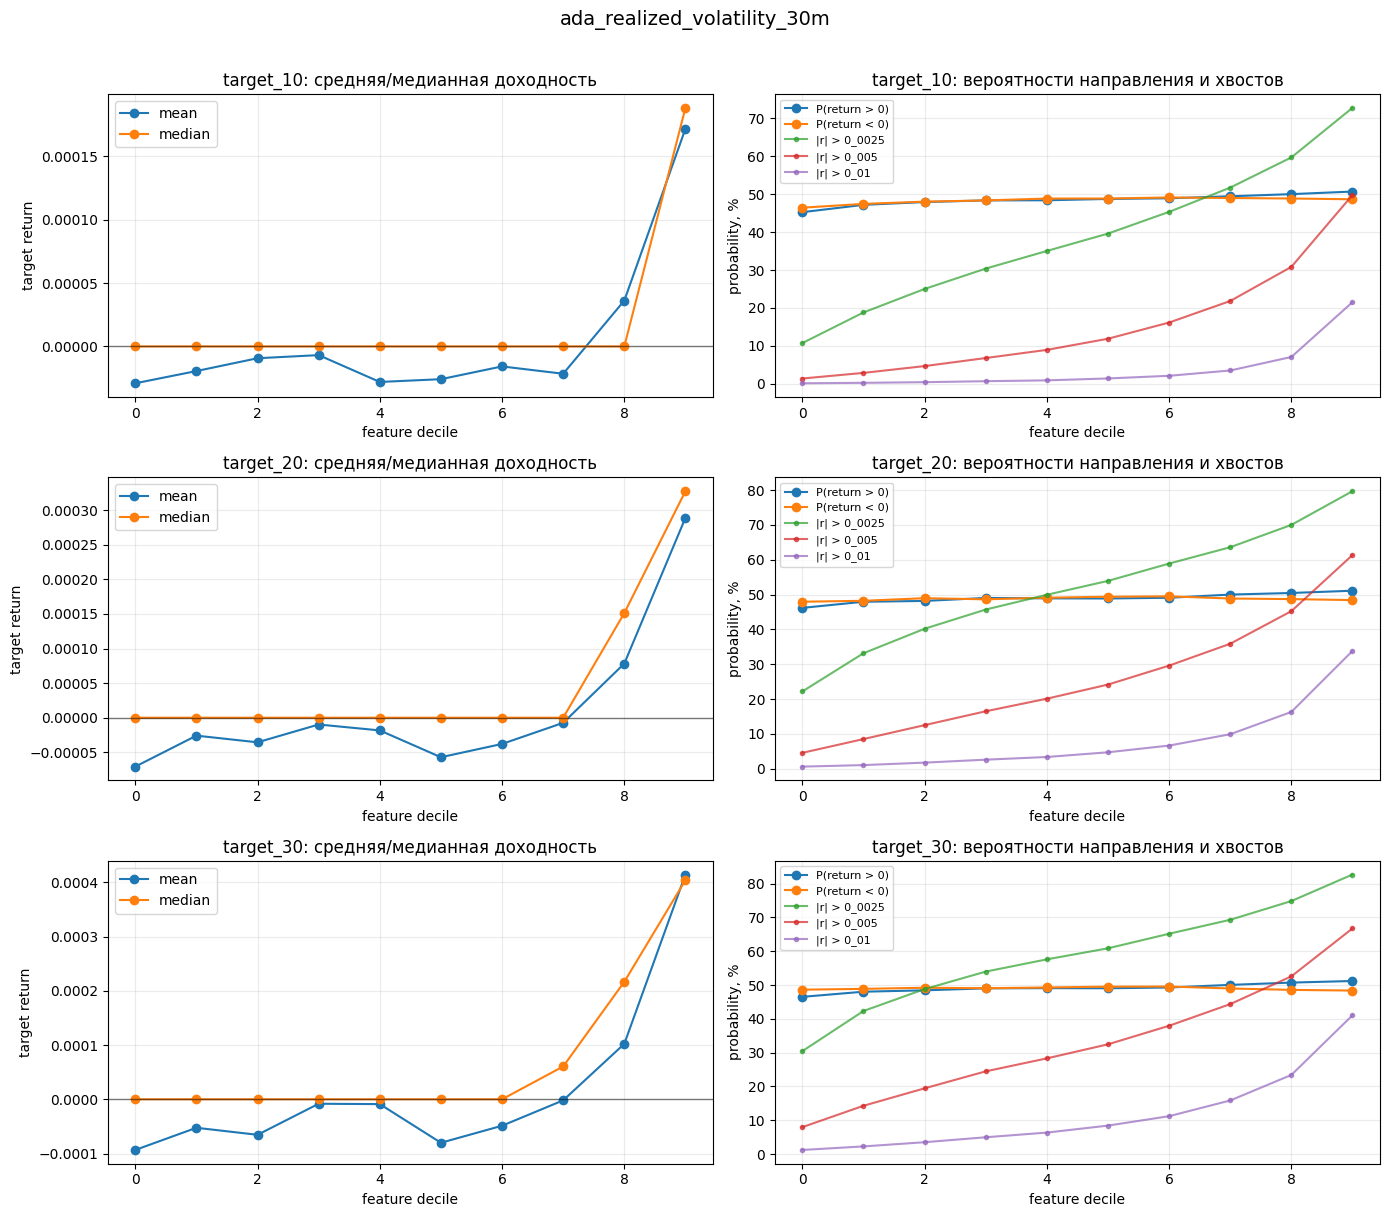

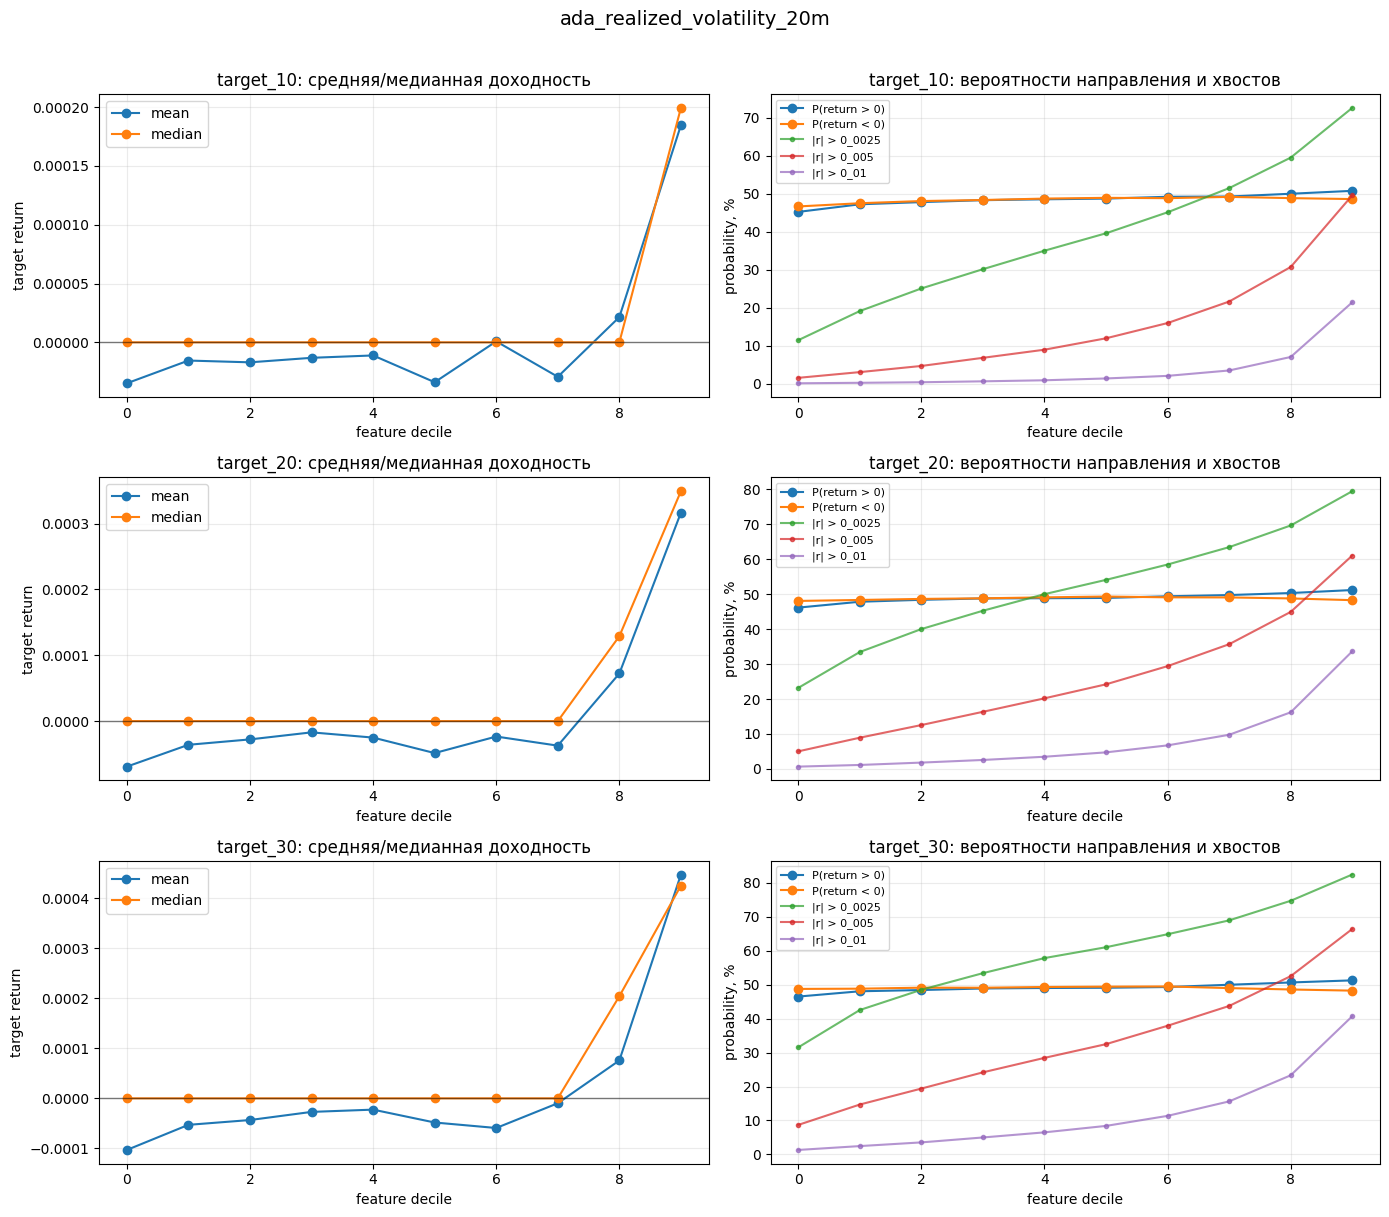

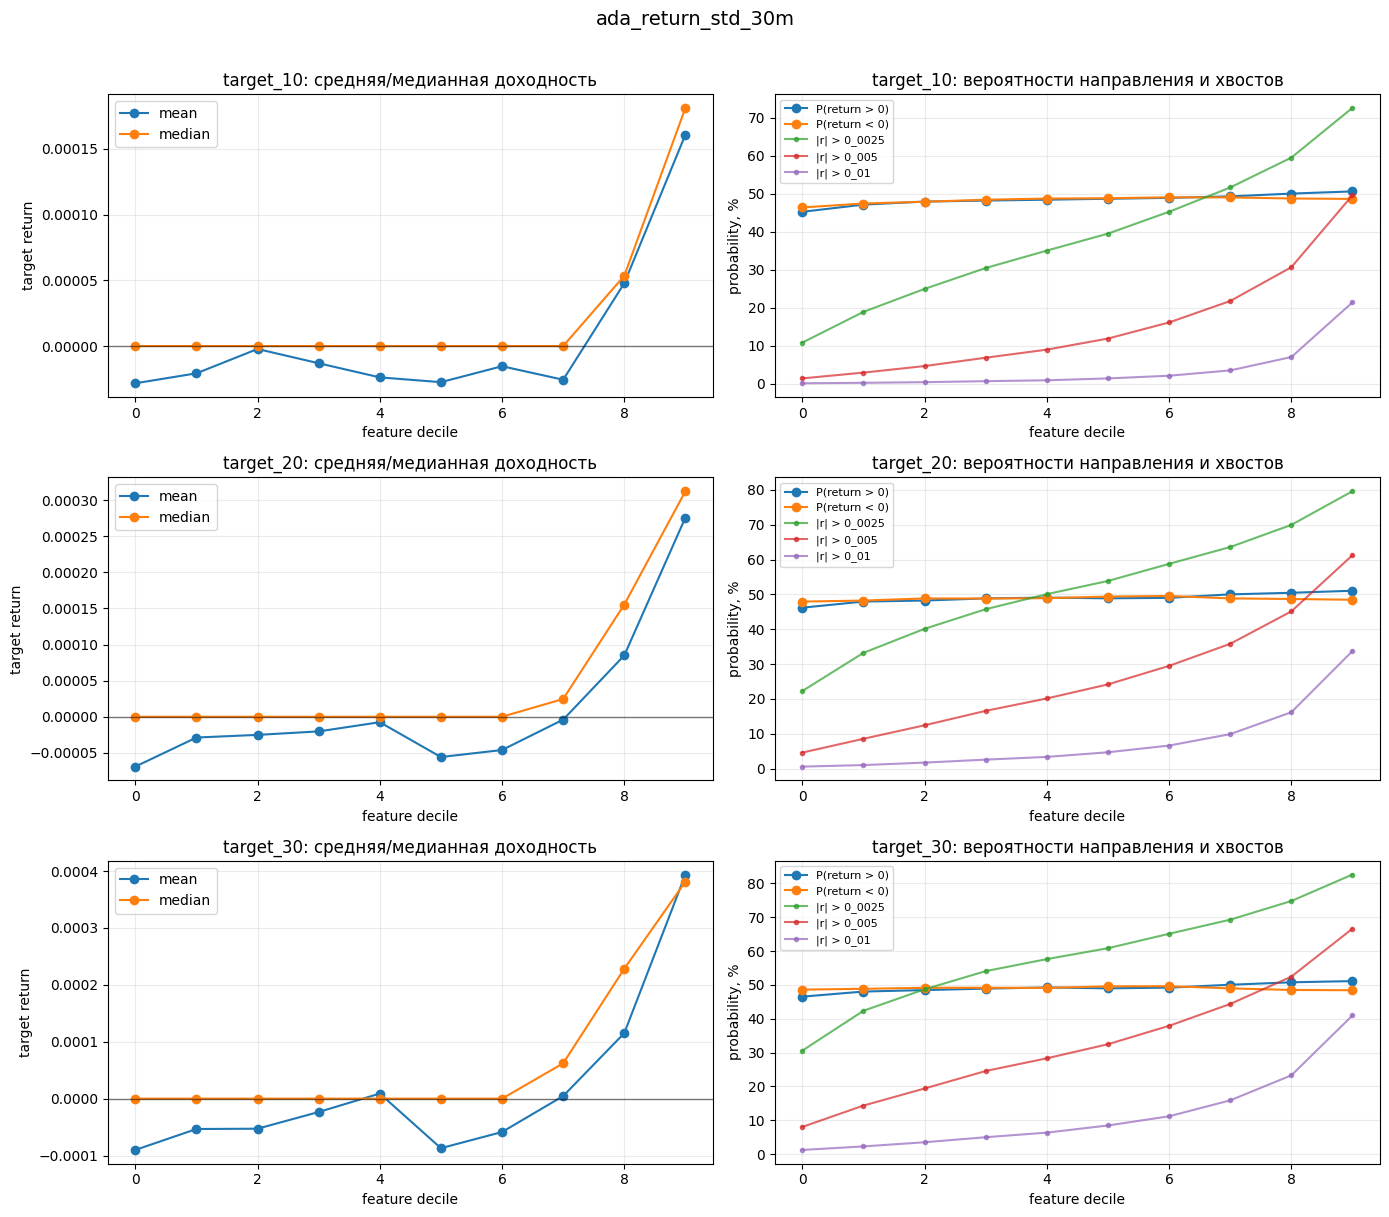

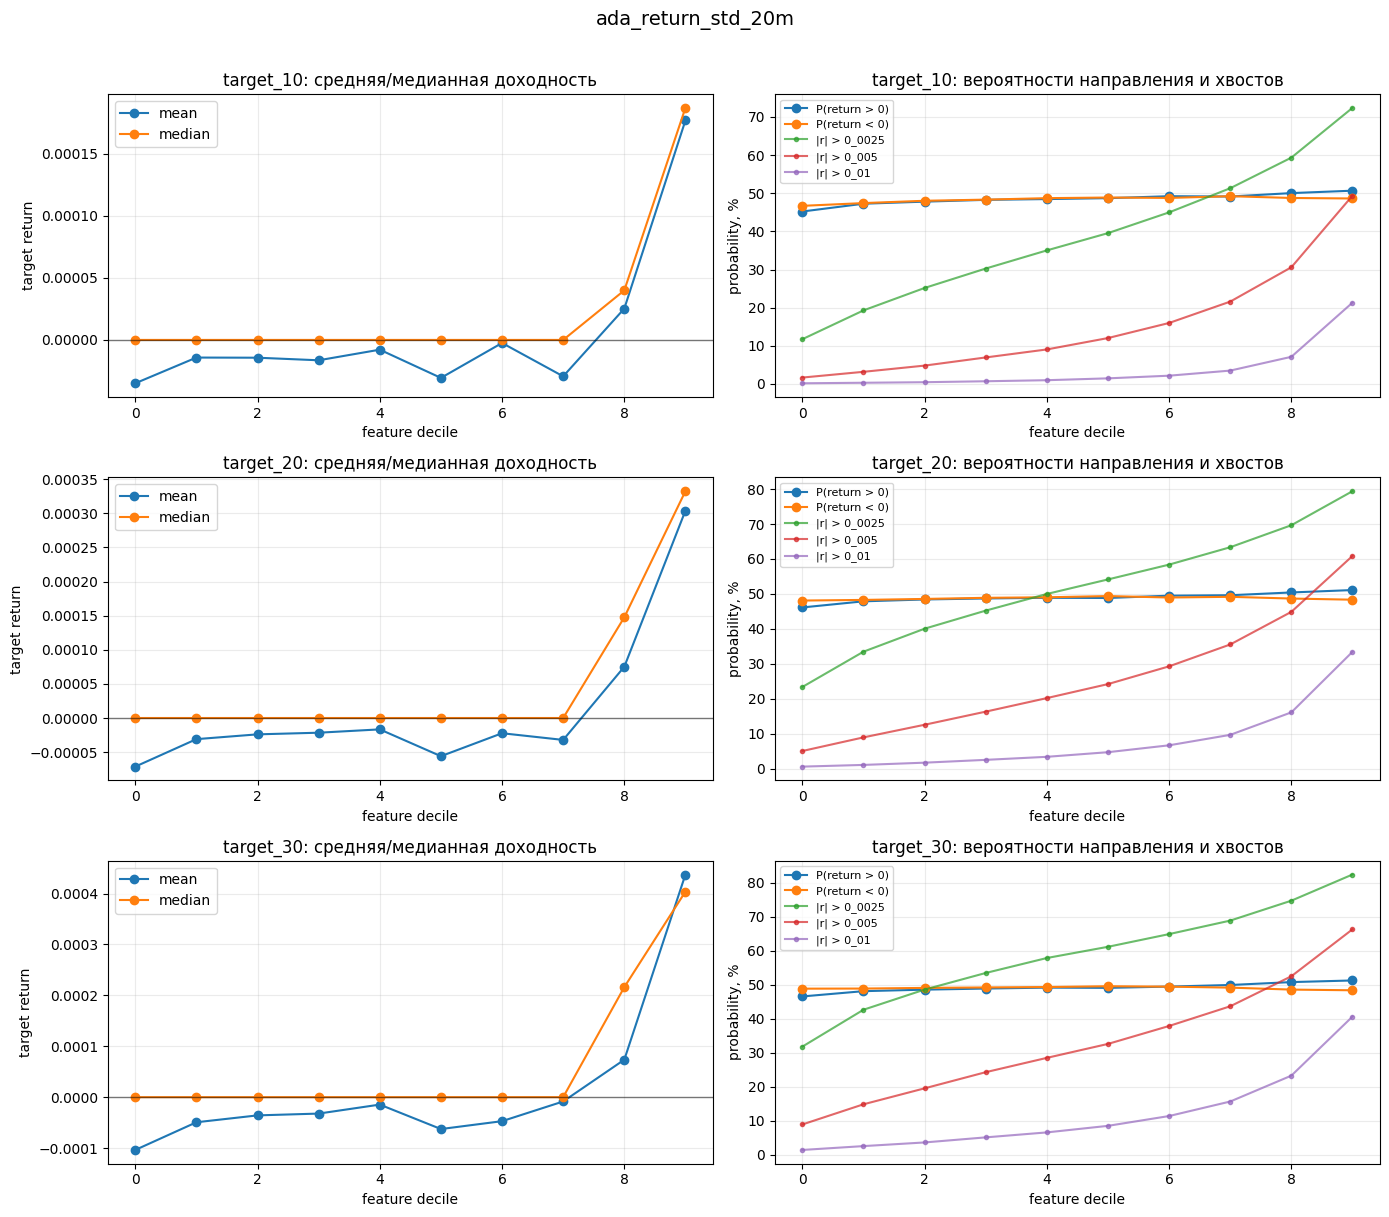

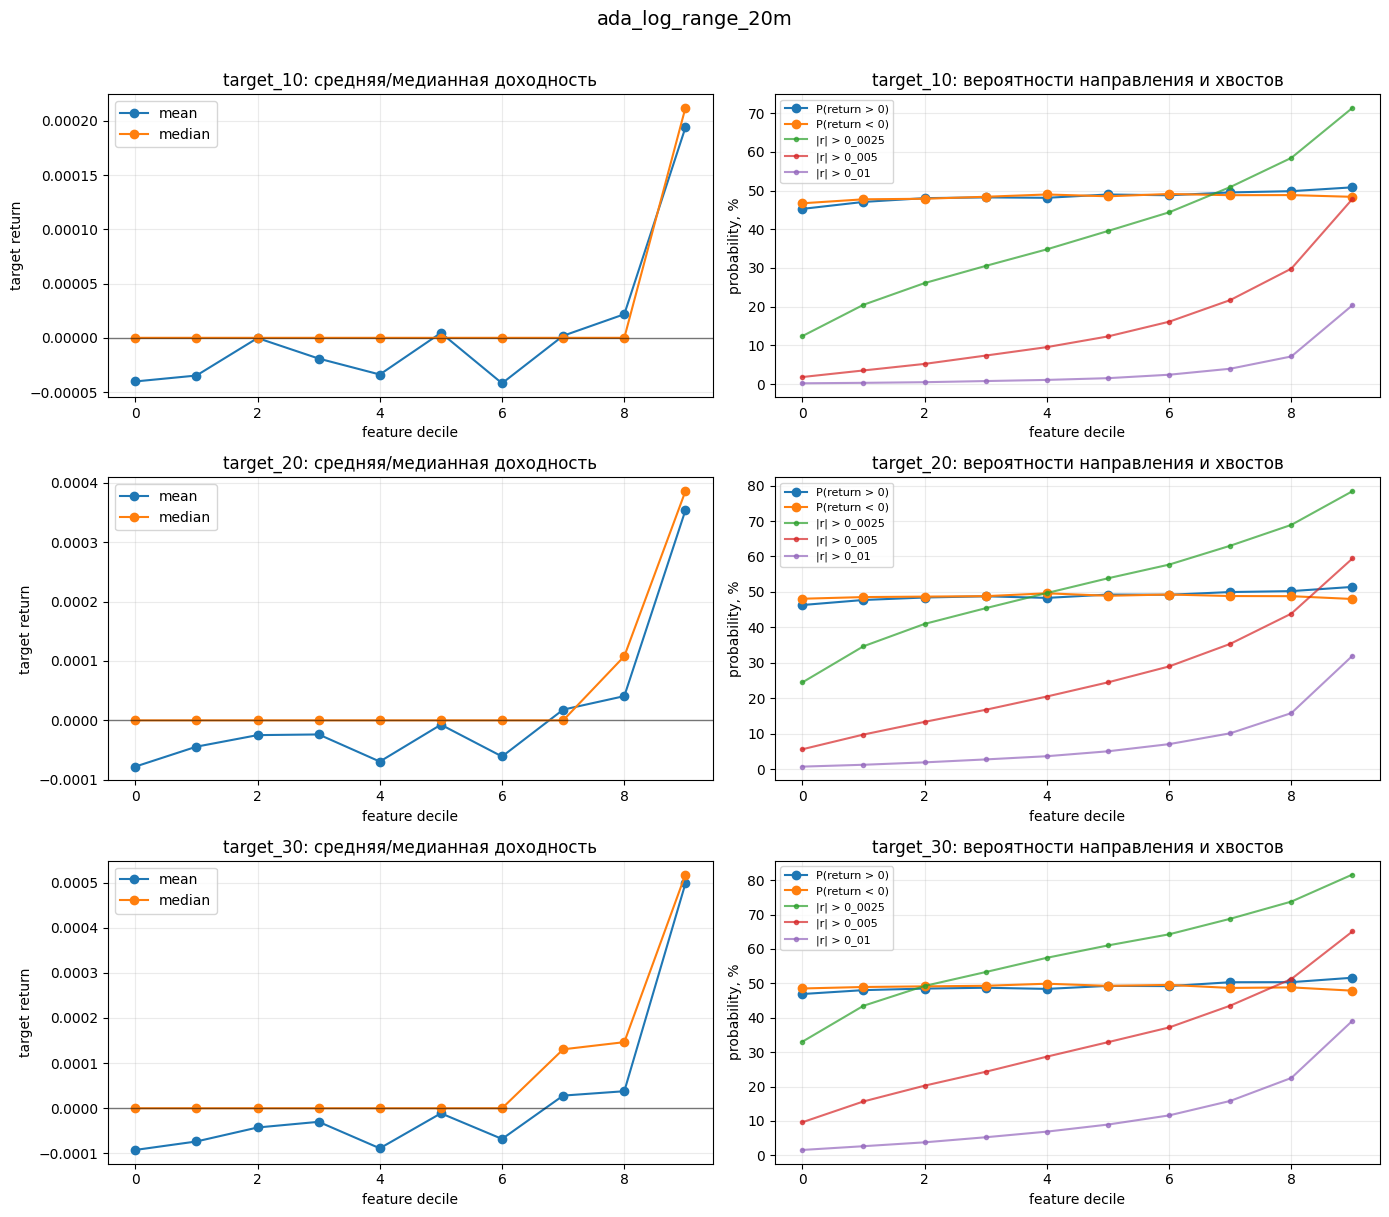

In [10]:
def plot_feature_bins(feature: str, horizons: list[str] = HORIZONS):
    fig, axes = plt.subplots(len(horizons), 2, figsize=(14, 4 * len(horizons)), squeeze=False)

    for row, horizon in enumerate(horizons):
        frame = bins_by_horizon[horizon].query("feature == @feature").sort_values("bin")
        if frame.empty:
            axes[row, 0].set_title(f"{horizon}: no bins for {feature}")
            axes[row, 1].set_axis_off()
            continue

        x = frame["bin"].astype(int)
        axes[row, 0].plot(x, frame["target_mean"], marker="o", label="mean")
        axes[row, 0].plot(x, frame["target_median"], marker="o", label="median")
        axes[row, 0].axhline(0, color="black", linewidth=1, alpha=0.5)
        axes[row, 0].set_title(f"{horizon}: средняя/медианная доходность")
        axes[row, 0].set_xlabel("feature decile")
        axes[row, 0].set_ylabel("target return")
        axes[row, 0].legend()
        axes[row, 0].grid(alpha=0.25)

        axes[row, 1].plot(x, pct(frame["prob_positive_return"]), marker="o", label="P(return > 0)")
        axes[row, 1].plot(x, pct(frame["prob_negative_return"]), marker="o", label="P(return < 0)")
        threshold_columns = [column for column in frame.columns if column.startswith("prob_abs_return_gt_")]
        for column in threshold_columns:
            axes[row, 1].plot(x, pct(frame[column]), marker=".", alpha=0.7, label=column.replace("prob_abs_return_gt_", "|r| > "))
        axes[row, 1].set_title(f"{horizon}: вероятности направления и хвостов")
        axes[row, 1].set_xlabel("feature decile")
        axes[row, 1].set_ylabel("probability, %")
        axes[row, 1].legend(fontsize=8)
        axes[row, 1].grid(alpha=0.25)

    fig.suptitle(feature, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


for feature in feature_rank.head(5)["feature"]:
    plot_feature_bins(feature)

## 8. Статистические тесты различий между группами

Здесь мы смотрим, отличаются ли распределения доходности между децилями признака.

- KS-тест в текущих результатах сравнивает крайние группы признака: нижний и верхний дециль. Это хорошо отвечает на вопрос: отличаются ли хвостовые состояния признака;
- Anderson-Darling `anderson_ksamp` сравнивает все группы сразу и чувствительнее к различиям в хвостах распределений;
- маленький p-value означает статистическое отличие распределений, но не говорит, что эффект экономически значим. Поэтому тесты нужно читать вместе с графиками bins и размерами эффекта из метрик.

In [11]:
tests = []
for horizon, frame in tests_by_horizon.items():
    item = frame.copy()
    item["horizon"] = horizon
    tests.append(item)
tests = pd.concat(tests, ignore_index=True)

display(tests.head())

for horizon in HORIZONS:
    frame = tests.query("horizon == @horizon").copy()
    print(f"\n=== {horizon}: strongest distribution differences by Anderson-Darling ===")
    display(
        frame.sort_values("anderson_darling_statistic", ascending=False)[
            ["feature", "groups", "ks_statistic", "ks_p_value", "anderson_darling_statistic", "anderson_darling_p_value"]
        ].head(20)
    )

,feature,groups,error,ks_statistic,ks_p_value,anderson_darling_statistic,anderson_darling_p_value,horizon
0,ada_log_return_lag_1,10,,0.033157,3.086288e-151,15418.383164,0.001,target_10
1,ada_log_return_lag_2,10,,0.023729,1.163082e-77,14772.369719,0.001,target_10
2,ada_log_return_lag_3,10,,0.018590,7.936253e-48,14349.570907,0.001,target_10
3,ada_log_return_lag_5,10,,0.017373,7.961262e-42,13986.830752,0.001,target_10
4,ada_log_return_lag_10,10,,0.012278,4.207267e-21,13313.788899,0.001,target_10



=== target_10: strongest distribution differences by Anderson-Darling ===


,feature,groups,ks_statistic,ks_p_value,anderson_darling_statistic,anderson_darling_p_value
40,ada_realized_volatility_60m,10,0.322268,0.0,50150.139013,0.001
39,ada_realized_volatility_30m,10,0.321923,0.0,49971.089748,0.001
35,ada_return_std_60m,10,0.321461,0.0,49895.922970,0.001
34,ada_return_std_30m,10,0.320308,0.0,49525.715762,0.001
38,ada_realized_volatility_20m,10,0.318123,0.0,48921.002337,0.001
33,ada_return_std_20m,10,0.315666,0.0,48247.517684,0.001
37,ada_realized_volatility_10m,10,0.306666,0.0,45414.274469,0.001
58,ada_log_range_30m,10,0.312373,0.0,45234.304759,0.001
63,ada_log_range_60m,10,0.310923,0.0,44989.336492,0.001
53,ada_log_range_20m,10,0.310067,0.0,44584.888050,0.001



=== target_20: strongest distribution differences by Anderson-Darling ===


,feature,groups,ks_statistic,ks_p_value,anderson_darling_statistic,anderson_darling_p_value
162,ada_realized_volatility_60m,10,0.320707,0.0,48131.203259,0.001
157,ada_return_std_60m,10,0.320036,0.0,47918.807366,0.001
161,ada_realized_volatility_30m,10,0.318421,0.0,47326.285185,0.001
156,ada_return_std_30m,10,0.316841,0.0,46991.720140,0.001
160,ada_realized_volatility_20m,10,0.314282,0.0,46140.896314,0.001
155,ada_return_std_20m,10,0.311878,0.0,45594.856070,0.001
159,ada_realized_volatility_10m,10,0.301269,0.0,42343.730438,0.001
185,ada_log_range_60m,10,0.305777,0.0,42276.050461,0.001
180,ada_log_range_30m,10,0.306454,0.0,42255.624726,0.001
175,ada_log_range_20m,10,0.304911,0.0,41793.490919,0.001



=== target_30: strongest distribution differences by Anderson-Darling ===


,feature,groups,ks_statistic,ks_p_value,anderson_darling_statistic,anderson_darling_p_value
284,ada_realized_volatility_60m,10,0.316723,0.0,45994.512178,0.001
279,ada_return_std_60m,10,0.315932,0.0,45828.256262,0.001
283,ada_realized_volatility_30m,10,0.314237,0.0,44891.751877,0.001
278,ada_return_std_30m,10,0.312049,0.0,44566.225843,0.001
282,ada_realized_volatility_20m,10,0.310336,0.0,43647.470382,0.001
277,ada_return_std_20m,10,0.307948,0.0,43152.690437,0.001
281,ada_realized_volatility_10m,10,0.296240,0.0,40105.224930,0.001
307,ada_log_range_60m,10,0.302262,0.0,40081.353678,0.001
302,ada_log_range_30m,10,0.301755,0.0,40021.990397,0.001
297,ada_log_range_20m,10,0.300899,0.0,39607.087682,0.001


## 9. Дублирование признаков

Даже если несколько признаков выглядят сильными, они могут описывать почти один и тот же сигнал. `correlation_matrix.parquet` хранит пары признаков и их корреляции.

Что делаем:

- ищем пары с высокой абсолютной корреляцией;
- при отборе признаков стараемся не брать много почти одинаковых факторов;
- внутри группы дублей обычно оставляем более интерпретируемый, устойчивый и менее проблемный по пропускам признак.

,feature_1,feature_2,pearson,spearman,abs_pearson,abs_spearman,max_abs_corr
3644,ada_return_std_60m,ada_realized_volatility_60m,0.999883,0.999835,0.999883,0.999835,0.999883
3557,ada_return_std_30m,ada_realized_volatility_30m,0.999487,0.999269,0.999487,0.999269,0.999487
3469,ada_return_std_20m,ada_realized_volatility_20m,0.998791,0.998239,0.998791,0.998239,0.998791
3380,ada_return_std_10m,ada_realized_volatility_10m,0.994816,0.992109,0.994816,0.992109,0.994816
6346,ada_trades_per_minute_20m,ada_trades_per_minute_30m,0.979585,0.990552,0.979585,0.990552,0.990552
6435,ada_aggression_delta_norm_5m,ada_large_trade_aggression_delta_norm_5m,0.987834,0.988247,0.987834,0.988247,0.988247
6678,ada_aggression_delta_norm_10m,ada_large_trade_aggression_delta_norm_10m,0.985834,0.986290,0.985834,0.986290,0.986290
6885,ada_aggression_delta_norm_20m,ada_large_trade_aggression_delta_norm_20m,0.983297,0.983845,0.983297,0.983845,0.983845
7056,ada_aggression_delta_norm_30m,ada_large_trade_aggression_delta_norm_30m,0.981425,0.982176,0.981425,0.982176,0.982176
6300,ada_trades_per_minute_10m,ada_trades_per_minute_20m,0.958183,0.981275,0.958183,0.981275,0.981275


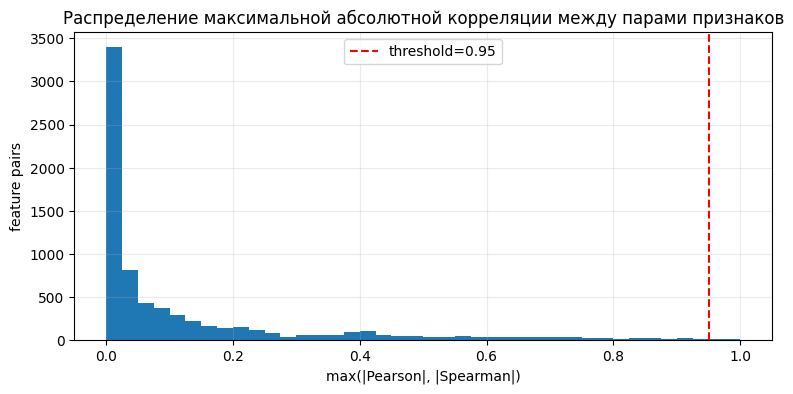

In [12]:
corr = correlation_pairs.copy()
corr["abs_pearson"] = corr["pearson"].abs()
corr["abs_spearman"] = corr["spearman"].abs()
corr["max_abs_corr"] = corr[["abs_pearson", "abs_spearman"]].max(axis=1)

strong_duplicates = corr.query("max_abs_corr >= @ABS_CORR_DUPLICATE_THRESHOLD").sort_values("max_abs_corr", ascending=False)
display(strong_duplicates.head(40))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(corr["max_abs_corr"].dropna(), bins=40)
ax.axvline(ABS_CORR_DUPLICATE_THRESHOLD, color="red", linestyle="--", label=f"threshold={ABS_CORR_DUPLICATE_THRESHOLD}")
ax.set_title("Распределение максимальной абсолютной корреляции между парами признаков")
ax.set_xlabel("max(|Pearson|, |Spearman|)")
ax.set_ylabel("feature pairs")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 10. Кандидаты для дальнейшего исследования

Финальная таблица ниже не является автоматическим отбором признаков для модели. Это список кандидатов, которые стоит разобрать вручную: посмотреть bins-графики, проверить экономический смысл и убедиться, что они не являются дублями более простых признаков.

Рекомендуемый порядок ручного анализа:

1. взять top-20 по `mean_score`;
2. для каждого признака посмотреть графики децилей;
3. проверить устойчивость по трём горизонтам;
4. удалить очевидные дубли по блоку корреляций;
5. отдельно отметить признаки, где эффект есть только в хвостах распределения.

In [13]:
candidate_table = feature_rank.merge(
    summary[["feature", "missing_rate", "unique_values", "skew", "kurtosis", "is_constant"]],
    on="feature",
    how="left",
)

duplicate_counts = pd.concat(
    [
        strong_duplicates[["feature_1"]].rename(columns={"feature_1": "feature"}),
        strong_duplicates[["feature_2"]].rename(columns={"feature_2": "feature"}),
    ],
    ignore_index=True,
).value_counts("feature").rename("high_corr_pair_count").reset_index()

candidate_table = candidate_table.merge(duplicate_counts, on="feature", how="left")
candidate_table["high_corr_pair_count"] = candidate_table["high_corr_pair_count"].fillna(0).astype(int)

display(
    candidate_table[
        [
            "feature",
            "mean_score",
            "min_score",
            "mean_abs_spearman",
            "mean_mi",
            "mean_dcor",
            "missing_rate",
            "unique_values",
            "high_corr_pair_count",
            "skew",
            "kurtosis",
        ]
    ].head(50)
)

output_path = LOCAL_RESULTS_DIR / "feature_candidate_ranking.csv"
candidate_table.to_csv(output_path, index=False)
print(f"Saved candidate ranking: {output_path.resolve()}")

,feature,mean_score,min_score,mean_abs_spearman,mean_mi,mean_dcor,missing_rate,unique_values,high_corr_pair_count,skew,kurtosis
0,ada_realized_volatility_30m,0.783599,0.773499,0.012419,0.108253,0.291998,0.0,3089438.0,3,15.602782,853.589305
1,ada_realized_volatility_20m,0.782698,0.766232,0.012892,0.104783,0.287859,0.0,3087264.0,3,16.849688,1058.390858
2,ada_return_std_30m,0.776862,0.766943,0.012185,0.107319,0.290971,0.0,3088357.0,3,15.714333,867.065220
3,ada_return_std_20m,0.773418,0.755463,0.012594,0.103336,0.286910,0.0,3087040.0,3,16.950740,1071.803798
4,ada_log_range_20m,0.765948,0.759509,0.014205,0.094902,0.273969,0.0,741506.0,0,19.669912,1455.769255
5,ada_log_range_30m,0.765805,0.762601,0.014317,0.096134,0.276893,0.0,669858.0,0,17.929464,1134.916879
6,ada_log_range_10m,0.763120,0.754179,0.013936,0.092147,0.273373,0.0,846070.0,0,23.508008,2309.111576
7,ada_realized_volatility_60m,0.748182,0.728525,0.012424,0.110618,0.293732,0.0,3093010.0,1,13.643871,604.314533
8,ada_realized_volatility_10m,0.745250,0.726603,0.012900,0.094830,0.276811,0.0,3079917.0,1,18.833303,1476.053976
9,ada_return_std_60m,0.743904,0.723968,0.012329,0.110105,0.293017,0.0,3091794.0,1,13.742605,613.419759


Saved candidate ranking: C:\projects\binance-dowloader-3.0\analysis\feature_informativeness\feature_candidate_ranking.csv


## 11. Быстрый ручной просмотр конкретного признака

Используйте эту ячейку как рабочий инструмент. Поменяйте `FEATURE_TO_INSPECT` на любой признак из таблиц выше. Notebook покажет его метрики по горизонтам, статистику качества, список сильно коррелирующих соседей и графики децилей.

Feature: ada_realized_volatility_30m


,feature,observations,missing,unique_values,mean,std,min,max,median,q25,q75,skew,kurtosis,error,missing_rate,is_constant
39,ada_realized_volatility_30m,3157740.0,0.0,3089438.0,0.006638,0.005623,0.0,0.496681,0.005298,0.003777,0.007773,15.602782,853.589305,,0.0,False


,feature,observations,pearson,pearson_p_value,spearman,spearman_p_value,mutual_information,distance_correlation,distance_correlation_rows,distance_correlation_sampled,error,horizon,abs_pearson,abs_spearman,score_abs_pearson,score_abs_spearman,score_mutual_information,score_distance_correlation,combined_score
39,ada_realized_volatility_30m,3157740,0.054841,0.0,0.009258,8.145329e-61,0.114765,0.293304,5000,True,,target_10,0.054841,0.009258,0.894830,0.208527,0.990639,1.000000,0.773499
161,ada_realized_volatility_30m,3157740,0.066844,0.0,0.012913,1.544032e-116,0.107881,0.292997,5000,True,,target_20,0.066844,0.012913,0.924261,0.266041,0.976252,0.986731,0.788321
283,ada_realized_volatility_30m,3157740,0.073589,0.0,0.015085,2.598573e-158,0.102112,0.289693,5000,True,,target_30,0.073589,0.015085,0.877424,0.321313,0.967906,0.989269,0.788978


,feature_1,feature_2,pearson,spearman,abs_pearson,abs_spearman,max_abs_corr
3557,ada_return_std_30m,ada_realized_volatility_30m,0.999487,0.999269,0.999487,0.999269,0.999487
3895,ada_realized_volatility_20m,ada_realized_volatility_30m,0.962435,0.965331,0.962435,0.965331,0.965331
3470,ada_return_std_20m,ada_realized_volatility_30m,0.961455,0.963825,0.961455,0.963825,0.963825
3978,ada_realized_volatility_30m,ada_realized_volatility_60m,0.930313,0.946231,0.930313,0.946231,0.946231
3643,ada_return_std_60m,ada_realized_volatility_30m,0.928916,0.945191,0.928916,0.945191,0.945191
3996,ada_realized_volatility_30m,ada_log_range_30m,0.918065,0.898772,0.918065,0.898772,0.918065
4001,ada_realized_volatility_30m,ada_log_range_60m,0.885107,0.875228,0.885107,0.875228,0.885107
3812,ada_realized_volatility_10m,ada_realized_volatility_30m,0.879702,0.884745,0.879702,0.884745,0.884745
3991,ada_realized_volatility_30m,ada_log_range_20m,0.882752,0.873890,0.882752,0.873890,0.882752
3382,ada_return_std_10m,ada_realized_volatility_30m,0.876373,0.877657,0.876373,0.877657,0.877657


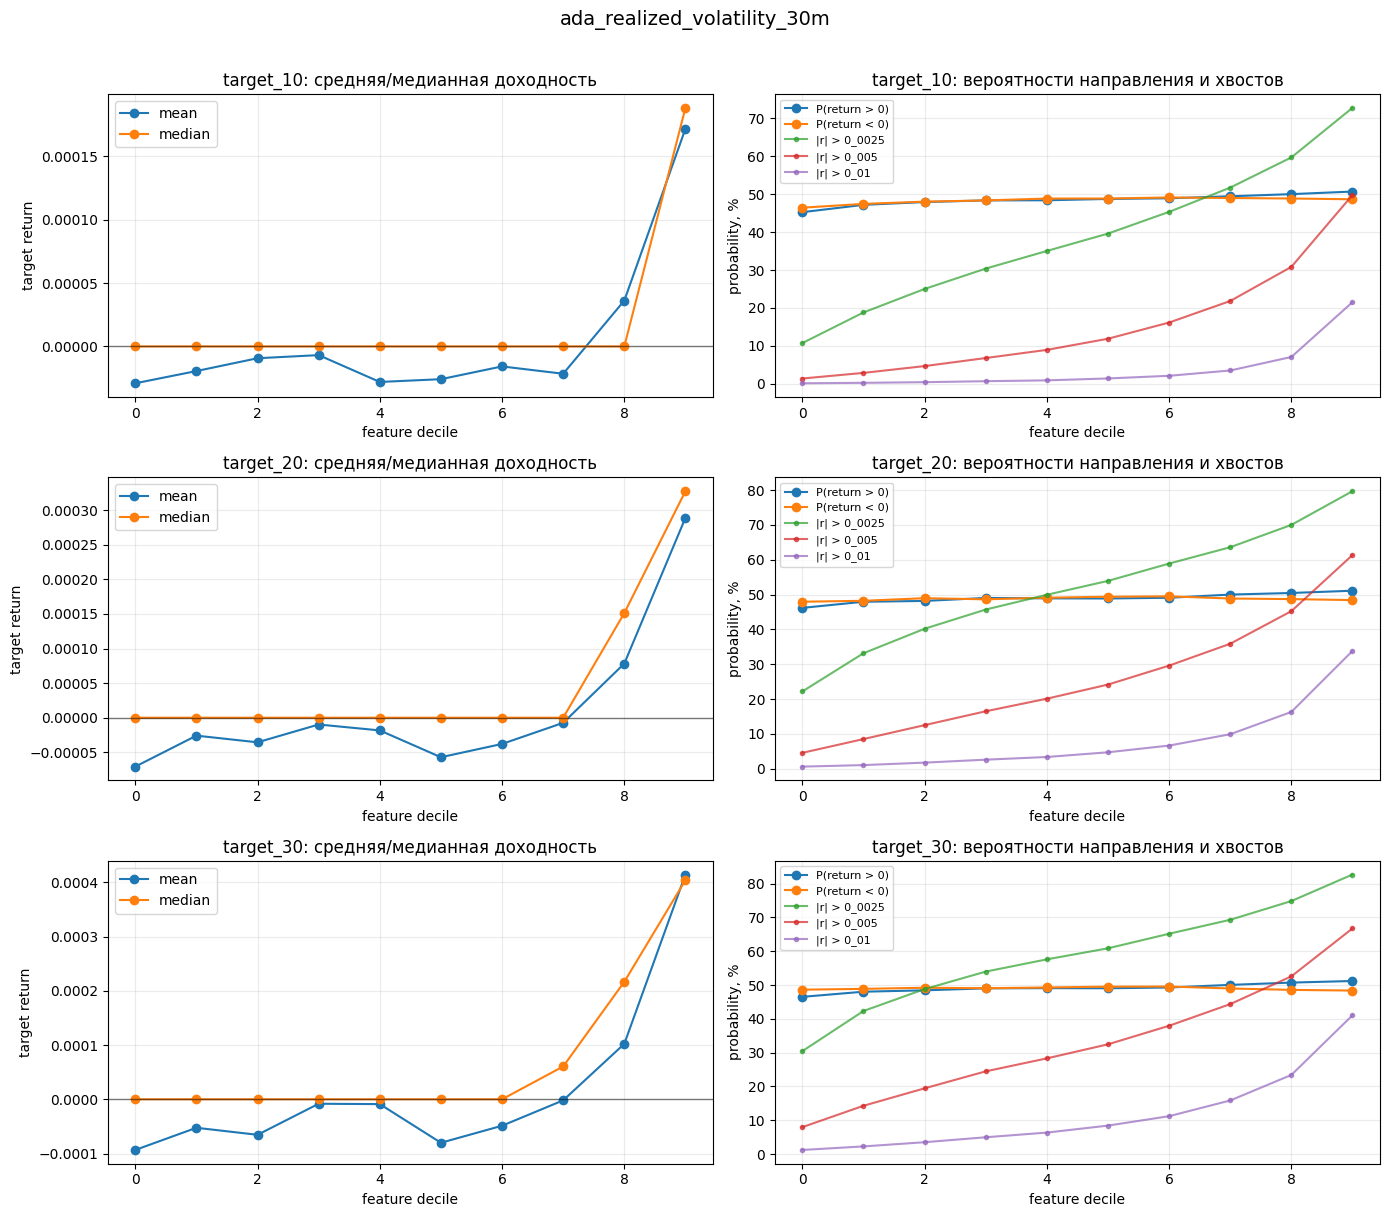

In [14]:
FEATURE_TO_INSPECT = feature_rank.iloc[0]["feature"]

print("Feature:", FEATURE_TO_INSPECT)
display(summary.query("feature == @FEATURE_TO_INSPECT"))
display(scored_metrics.query("feature == @FEATURE_TO_INSPECT").sort_values("horizon"))

neighbors = corr.query("feature_1 == @FEATURE_TO_INSPECT or feature_2 == @FEATURE_TO_INSPECT").sort_values("max_abs_corr", ascending=False)
display(neighbors.head(20))

plot_feature_bins(FEATURE_TO_INSPECT)

## Итоговая интерпретация

После прохода по notebook желательно зафиксировать выводы вручную:

- какие признаки стабильно сильные на всех горизонтах;
- какие признаки работают только на коротком или длинном горизонте;
- где эффект выглядит монотонным, а где только хвостовым;
- какие признаки стоит исключить из-за пропусков, константности или дублей;
- какие группы признаков дают похожую информацию.

Хороший кандидат для дальнейшего использования — это не просто верхняя строка рейтинга, а признак с понятным поведением по bins, стабильностью по горизонту и приемлемым уровнем дублирования.

In [15]:
family = "ada_realized_volatility"

cols = [
    "horizon",
    "feature",
    "abs_pearson",
    "abs_spearman",
    "mutual_information",
    "distance_correlation",
    "combined_score",
]

display(
    scored_metrics[
        scored_metrics["feature"].str.startswith(family)
    ][cols]
    .sort_values(["horizon", "feature"])
)

,horizon,feature,abs_pearson,abs_spearman,mutual_information,distance_correlation,combined_score
37,target_10,ada_realized_volatility_10m,0.052763,0.009819,0.101457,0.278714,0.726603
38,target_10,ada_realized_volatility_20m,0.054242,0.009921,0.111459,0.291507,0.766232
39,target_10,ada_realized_volatility_30m,0.054841,0.009258,0.114765,0.293304,0.773499
36,target_10,ada_realized_volatility_5m,0.055956,0.009344,0.084890,0.262230,0.686440
40,target_10,ada_realized_volatility_60m,0.044037,0.008976,0.115849,0.291694,0.728525
159,target_20,ada_realized_volatility_10m,0.066579,0.013653,0.094078,0.272907,0.742648
160,target_20,ada_realized_volatility_20m,0.070741,0.013389,0.104392,0.286062,0.790440
161,target_20,ada_realized_volatility_30m,0.066844,0.012913,0.107881,0.292997,0.788321
158,target_20,ada_realized_volatility_5m,0.062873,0.013023,0.078614,0.251624,0.672864
162,target_20,ada_realized_volatility_60m,0.054413,0.012910,0.110506,0.296800,0.754513


In [16]:
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------- Красивые названия ----------

METRIC_NAMES = {
    "abs_pearson": "Корреляция Пирсона",
    "abs_spearman": "Корреляция Спирмена",
    "mutual_information": "Взаимная информация",
    "distance_correlation": "Distance Correlation",
}

FAMILY_NAMES = {
    "ada_realized_volatility": "Реализованная волатильность ADA",
    "ada_return_std": "Стандартное отклонение доходности ADA",
    "ada_log_range": "Логарифмический диапазон ADA",
    "ada_close_zscore": "Z-score цены ADA",
    "ada_close_position": "Положение цены внутри диапазона ADA",
    "ada_cum_return": "Накопленная доходность ADA",
    "ada_volume_sum": "Объем торгов ADA",
    "ada_volume_zscore": "Z-score объема ADA",
    "ada_trades_per_minute": "Количество сделок ADA",
    "ada_aggression_delta_norm": "Дисбаланс агрессивных сделок ADA",
    "ada_large_trade_aggression_delta_norm": "Дисбаланс крупных агрессивных сделок ADA",
    "btc_log_return": "Доходность BTC",
    "btc_return_std": "Волатильность BTC",
}


def plot_family(
    scored_metrics,
    family_prefix,
    normalize=True,
):

    df = scored_metrics[
        scored_metrics["feature"].str.startswith(family_prefix)
    ].copy()

    if df.empty:
        print(f"Семейство '{family_prefix}' не найдено.")
        return

    df["window"] = (
        df["feature"]
        .str.extract(r"_(\d+)m$")
        .astype(int)
    )

    metrics = [
        "abs_pearson",
        "abs_spearman",
        "mutual_information",
        "distance_correlation",
    ]

    horizons = [
        ("target_10", "10 минут"),
        ("target_20", "20 минут"),
        ("target_30", "30 минут"),
    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 9),
        sharex=True,
        sharey=normalize,
    )

    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):

        for horizon, label in horizons:

            tmp = (
                df[df["horizon"] == horizon]
                .sort_values("window")
                .copy()
            )

            y = tmp[metric].values

            if normalize:
                if np.max(y) > 0:
                    y = y / np.max(y)

            ax.plot(
                tmp["window"],
                y,
                marker="o",
                linewidth=2.5,
                markersize=6,
                label=label,
            )

            # максимум
            idx = np.argmax(y)

            ax.scatter(
                tmp["window"].iloc[idx],
                y[idx],
                s=80,
                zorder=10,
            )

            ax.axvline(
                tmp["window"].iloc[idx],
                linestyle="--",
                alpha=0.15,
            )

        ax.set_title(
            METRIC_NAMES[metric],
            fontsize=13,
            fontweight="bold",
        )

        ax.set_xticks(sorted(df["window"].unique()))

        ax.grid(
            linestyle="--",
            alpha=0.25,
        )

        ax.set_xlabel("Размер окна, мин")

        if normalize:
            ax.set_ylabel("Нормированная информативность")
            ax.set_ylim(0, 1.05)
        else:
            ax.set_ylabel("Значение метрики")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Горизонт прогноза",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=3,
        frameon=True,
    )

    fig.suptitle(
        FAMILY_NAMES.get(family_prefix, family_prefix),
        fontsize=18,
        fontweight="bold",
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    plt.show()

In [ ]:
plot_family(scored_metrics, "ada_realized_volatility")
plot_family(scored_metrics, "ada_log_range")
plot_family(scored_metrics, "ada_return_std")
plot_family(scored_metrics, "ada_close_zscore")
plot_family(scored_metrics, "ada_close_position")
plot_family(scored_metrics, "ada_cum_return")

In [18]:
WINDOW_FAMILIES = [
    "ada_cum_return",
    "ada_return_acceleration",
    "ada_kaufman_efficiency",

    "ada_close_zscore",
    "ada_close_position",

    "ada_return_std",
    "ada_realized_volatility",

    "ada_upper_wick",
    "ada_lower_wick",
    "ada_high_close_ratio",
    "ada_log_range",

    "ada_volume_sum",
    "ada_volume_zscore",

    "ada_trades_per_minute",

    "ada_aggression_delta_norm",
    "ada_large_trade_aggression_delta_norm",

    "ada_volume_entropy_norm",
    "ada_inverse_simpson_norm",
    "ada_average_trade_size_quote",
    "ada_pressure_concentration",

    "btc_log_return",
    "btc_return_std",
    "btc_kaufman_efficiency",
]

In [19]:
import numpy as np
import matplotlib.pyplot as plt


METRIC_NAMES = {
    "abs_pearson": "Корреляция Пирсона",
    "abs_spearman": "Корреляция Спирмена",
    "mutual_information": "Взаимная информация",
    "distance_correlation": "Distance Correlation",
}


FAMILY_NAMES = {
    "ada_cum_return": "Накопленная доходность ADA",
    "ada_return_acceleration": "Ускорение доходности ADA",
    "ada_kaufman_efficiency": "Коэффициент эффективности Кауфмана ADA",

    "ada_close_zscore": "Z-score цены ADA",
    "ada_close_position": "Положение цены внутри диапазона ADA",

    "ada_return_std": "Стандартное отклонение доходности ADA",
    "ada_realized_volatility": "Реализованная волатильность ADA",

    "ada_upper_wick": "Верхняя тень свечи ADA",
    "ada_lower_wick": "Нижняя тень свечи ADA",
    "ada_high_close_ratio": "Отношение Close к High ADA",
    "ada_log_range": "Логарифмический диапазон ADA",

    "ada_volume_sum": "Объем торгов ADA",
    "ada_volume_zscore": "Z-score объема ADA",

    "ada_trades_per_minute": "Количество сделок ADA",

    "ada_aggression_delta_norm": "Дисбаланс агрессивных сделок ADA",
    "ada_large_trade_aggression_delta_norm": "Дисбаланс крупных агрессивных сделок ADA",

    "ada_volume_entropy_norm": "Энтропия объемов ADA",
    "ada_inverse_simpson_norm": "Индекс Симпсона ADA",
    "ada_average_trade_size_quote": "Средний размер сделки ADA",
    "ada_pressure_concentration": "Концентрация торгового давления ADA",

    "btc_log_return": "Доходность BTC",
    "btc_return_std": "Волатильность BTC",
    "btc_kaufman_efficiency": "Коэффициент эффективности Кауфмана BTC",
}


def plot_family(scored_metrics, family_prefix, normalize=True):

    df = scored_metrics[
        scored_metrics["feature"].str.startswith(family_prefix)
    ].copy()

    if df.empty:
        print(f"Семейство '{family_prefix}' не найдено.")
        return

    # оставляем только признаки, оканчивающиеся на "_Xm"
    df = df[
        df["feature"].str.contains(r"_\d+m$", regex=True)
    ].copy()

    if df.empty:
        print(f"У семейства '{family_prefix}' отсутствуют оконные признаки.")
        return

    df["window"] = (
        df["feature"]
        .str.extract(r"_(\d+)m$")[0]
        .astype(int)
    )

    metrics = [
        "abs_pearson",
        "abs_spearman",
        "mutual_information",
        "distance_correlation",
    ]

    horizons = [
        ("target_10", "10 минут"),
        ("target_20", "20 минут"),
        ("target_30", "30 минут"),
    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 10),
        sharex=True,
        sharey=normalize,
    )

    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):

        for horizon, label in horizons:

            tmp = (
                df[df["horizon"] == horizon]
                .sort_values("window")
            )

            y = tmp[metric].to_numpy()

            if normalize:
                ymax = np.nanmax(y)
                if ymax > 0:
                    y = y / ymax

            ax.plot(
                tmp["window"],
                y,
                marker="o",
                linewidth=2.5,
                markersize=7,
                label=label,
            )

            idx = np.nanargmax(y)

            ax.scatter(
                tmp["window"].iloc[idx],
                y[idx],
                s=70,
                zorder=10,
            )

        ax.set_title(
            METRIC_NAMES[metric],
            fontsize=13,
            fontweight="bold",
        )

        ax.grid(
            linestyle="--",
            alpha=0.3,
        )

        ax.set_xticks(sorted(df["window"].unique()))

        ax.set_xlabel("Размер окна, мин")

        if normalize:
            ax.set_ylabel("Нормированная сила связи")
            ax.set_ylim(0, 1.05)
        else:
            ax.set_ylabel("Значение метрики")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Горизонт прогнозирования",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=3,
        frameon=True,
    )

    fig.suptitle(
        FAMILY_NAMES.get(family_prefix, family_prefix),
        fontsize=18,
        fontweight="bold",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    plt.show()

In [21]:
def plot_family_raw(scored_metrics, family_prefix):

    df = scored_metrics[
        scored_metrics["feature"].str.startswith(family_prefix)
    ].copy()

    if df.empty:
        print(f"Семейство '{family_prefix}' не найдено.")
        return

    df = df[
        df["feature"].str.contains(r"_\d+m$", regex=True)
    ].copy()

    if df.empty:
        print(f"У семейства '{family_prefix}' отсутствуют оконные признаки.")
        return

    df["window"] = (
        df["feature"]
        .str.extract(r"_(\d+)m$")[0]
        .astype(int)
    )

    metrics = [
        "abs_pearson",
        "abs_spearman",
        "mutual_information",
        "distance_correlation",
    ]

    horizons = [
        ("target_10", "10 минут"),
        ("target_20", "20 минут"),
        ("target_30", "30 минут"),
    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 10),
        sharex=True,
    )

    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):

        for horizon, label in horizons:

            tmp = (
                df[df["horizon"] == horizon]
                .sort_values("window")
            )

            y = tmp[metric].to_numpy()

            ax.plot(
                tmp["window"],
                y,
                marker="o",
                linewidth=2.5,
                markersize=7,
                label=label,
            )

            idx = np.nanargmax(y)

            ax.scatter(
                tmp["window"].iloc[idx],
                y[idx],
                s=70,
                zorder=10,
            )

        ax.set_title(
            METRIC_NAMES[metric],
            fontsize=13,
            fontweight="bold",
        )

        ax.grid(
            linestyle="--",
            alpha=0.3,
        )

        ax.set_xticks(sorted(df["window"].unique()))
        ax.set_xlabel("Размер окна, мин")
        ax.set_ylabel("Значение метрики")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Горизонт прогнозирования",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=3,
        frameon=True,
    )

    fig.suptitle(
        FAMILY_NAMES.get(family_prefix, family_prefix),
        fontsize=18,
        fontweight="bold",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

Накопленная доходность ADA


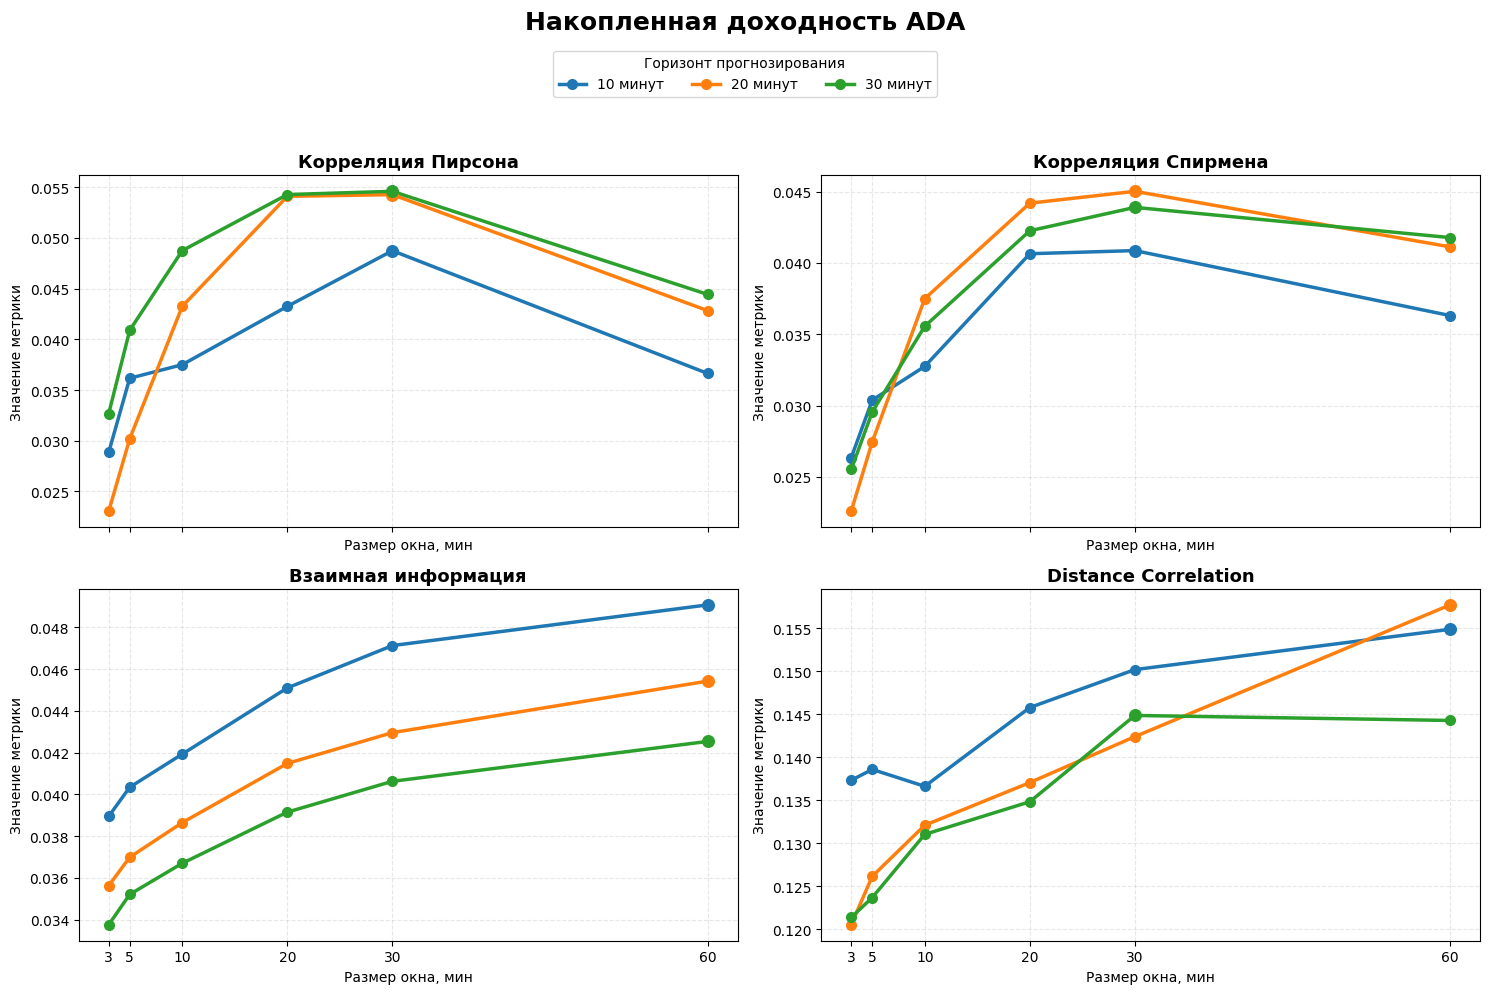

Ускорение доходности ADA


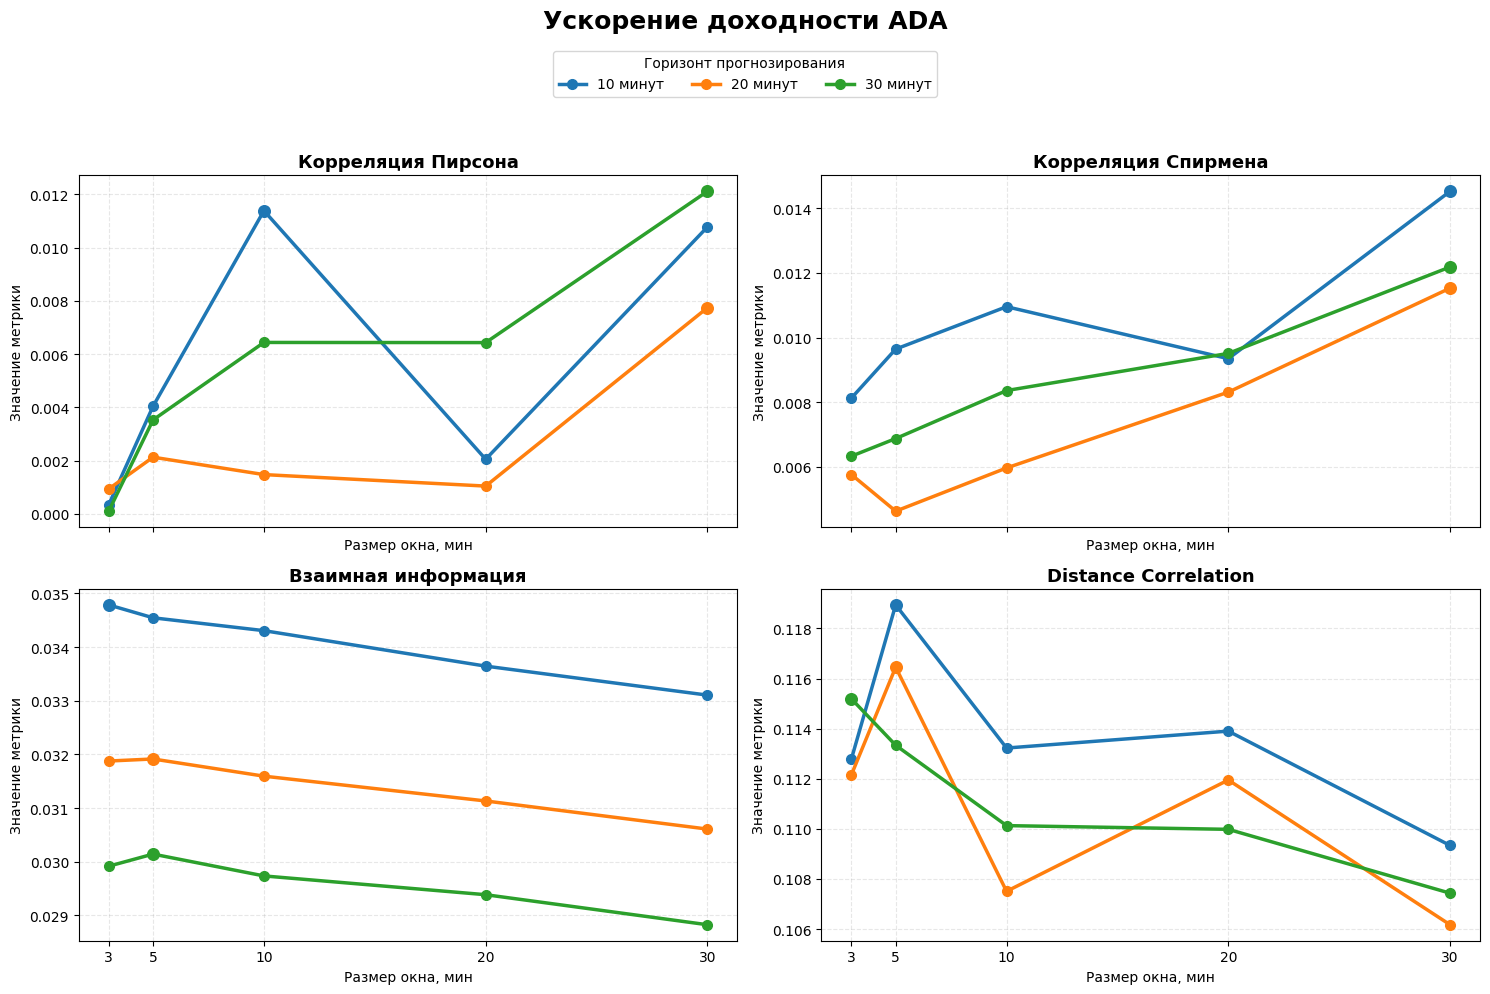

Коэффициент эффективности Кауфмана ADA


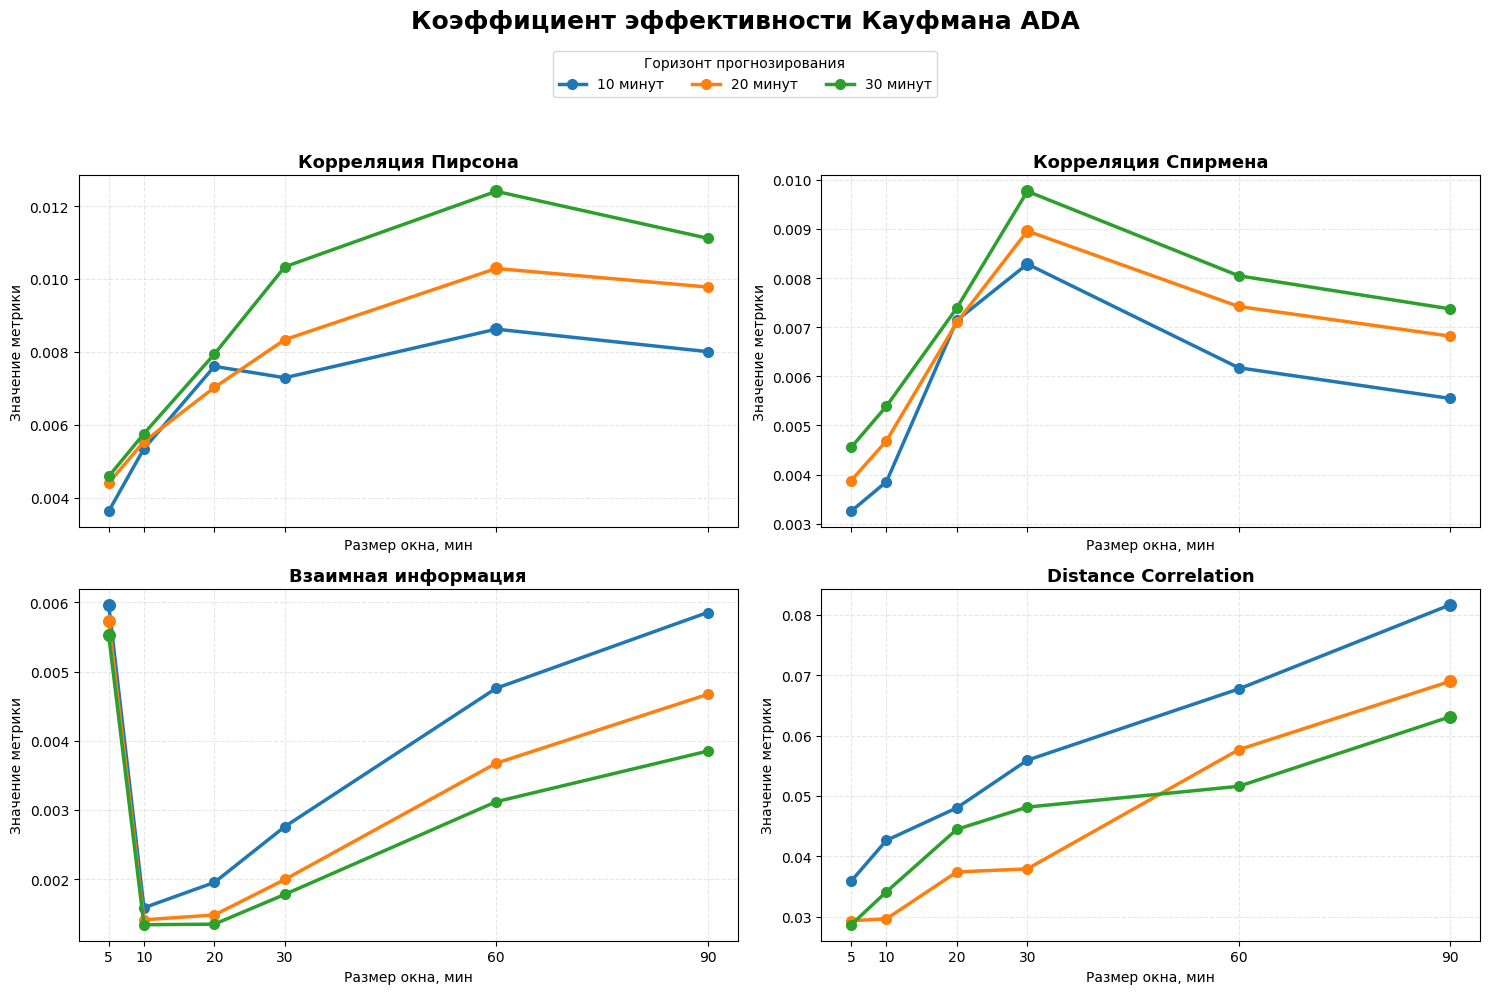

Z-score цены ADA


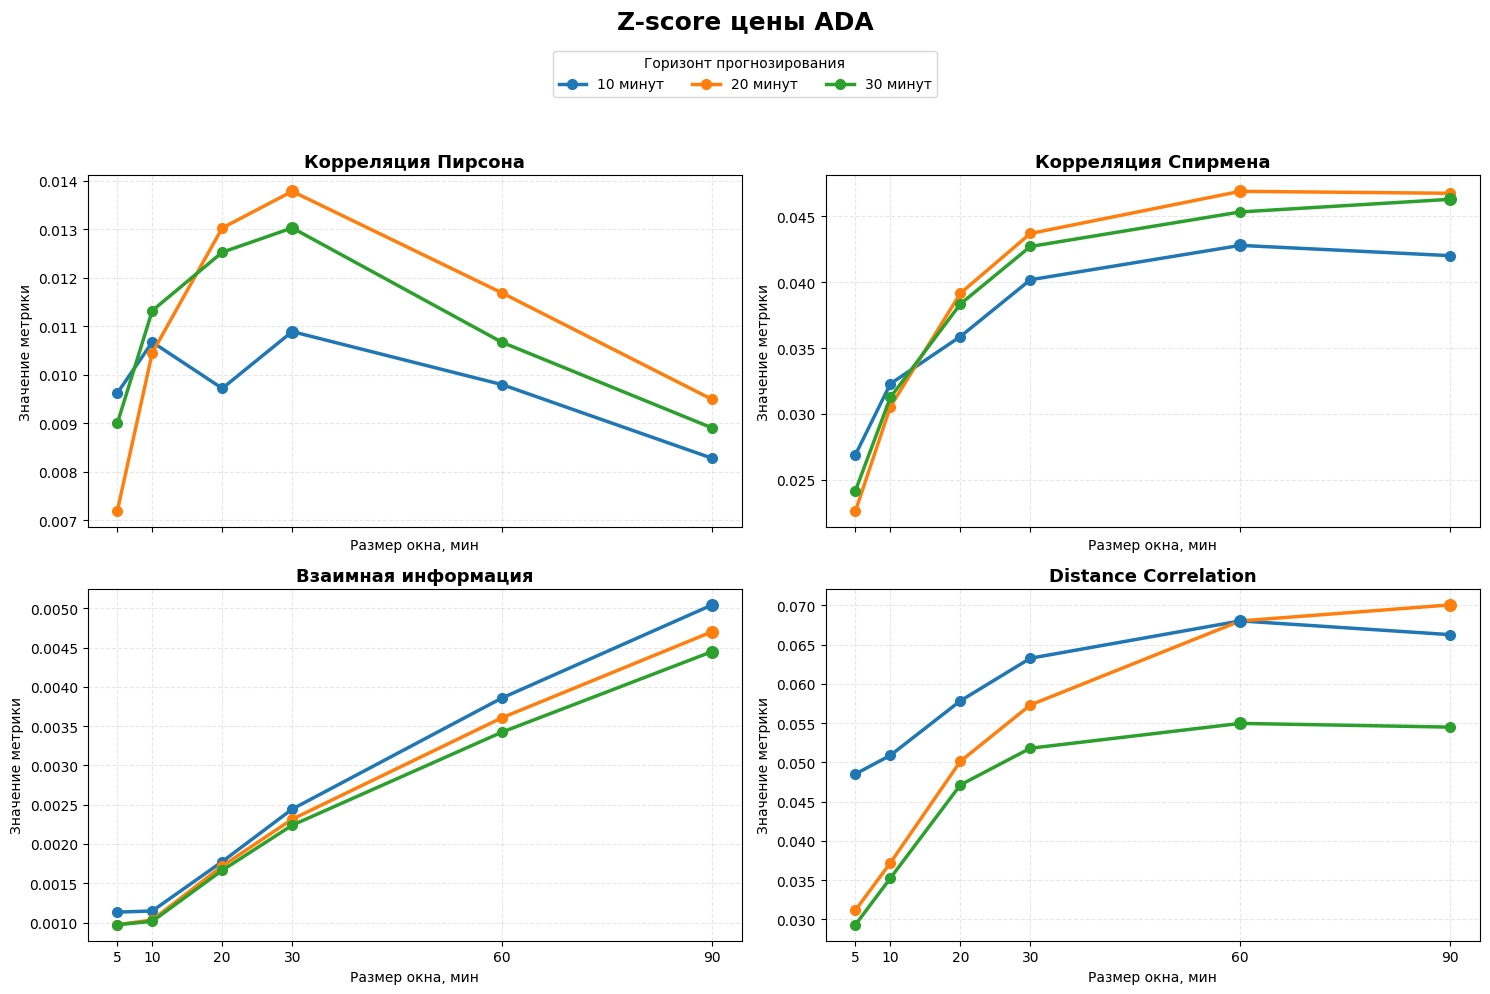

Положение цены внутри диапазона ADA


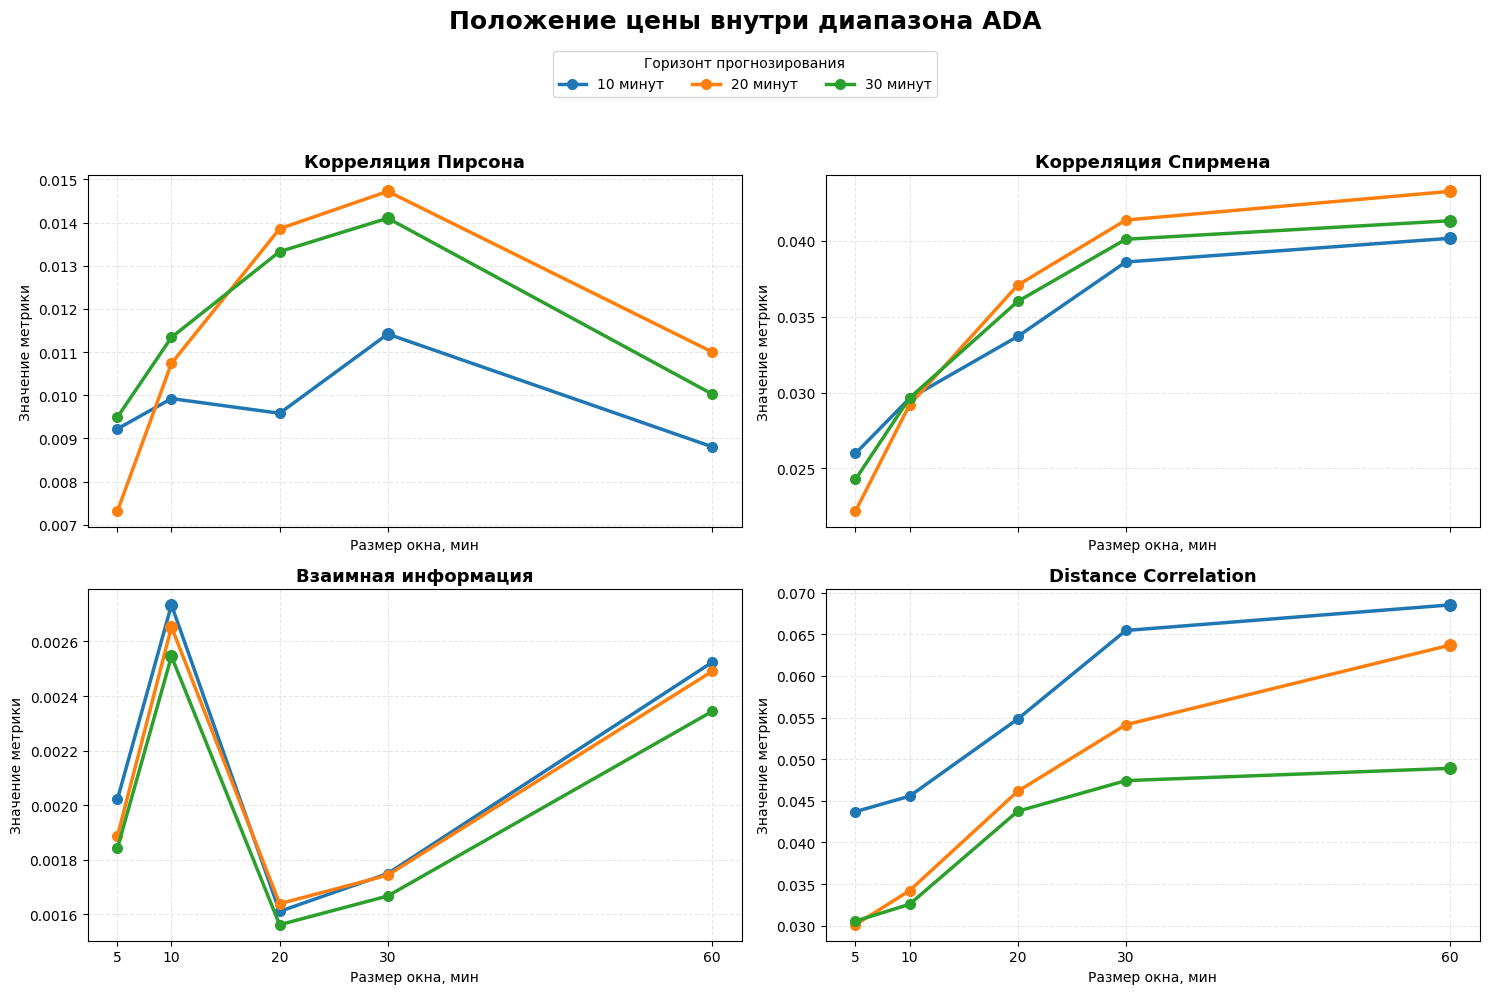

Стандартное отклонение доходности ADA


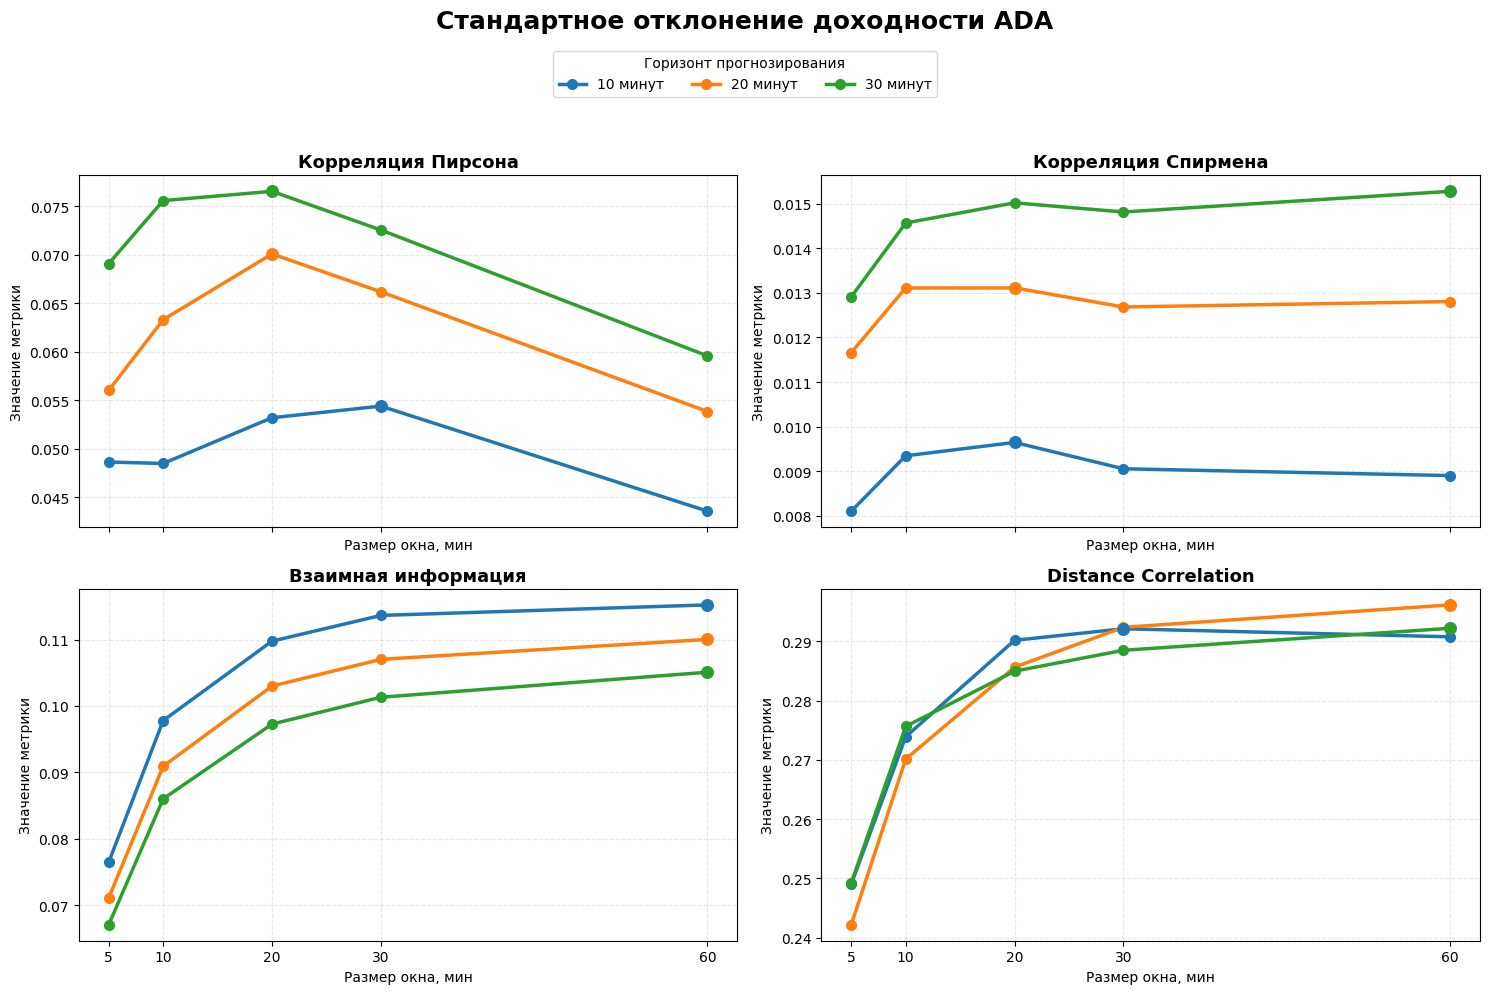

Реализованная волатильность ADA


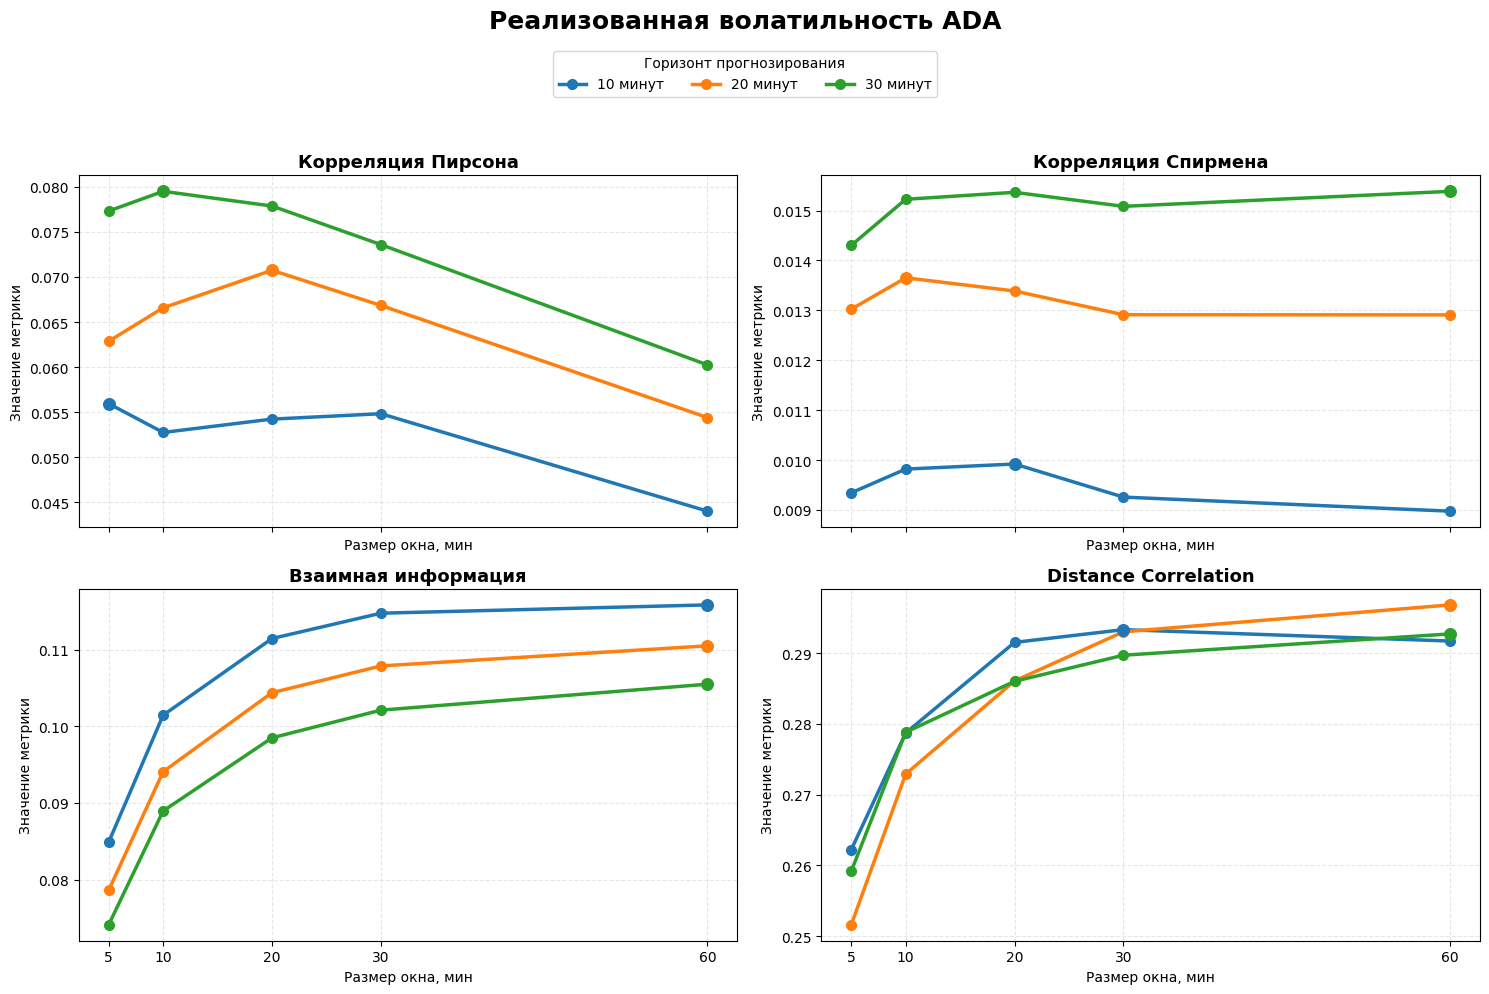

Верхняя тень свечи ADA


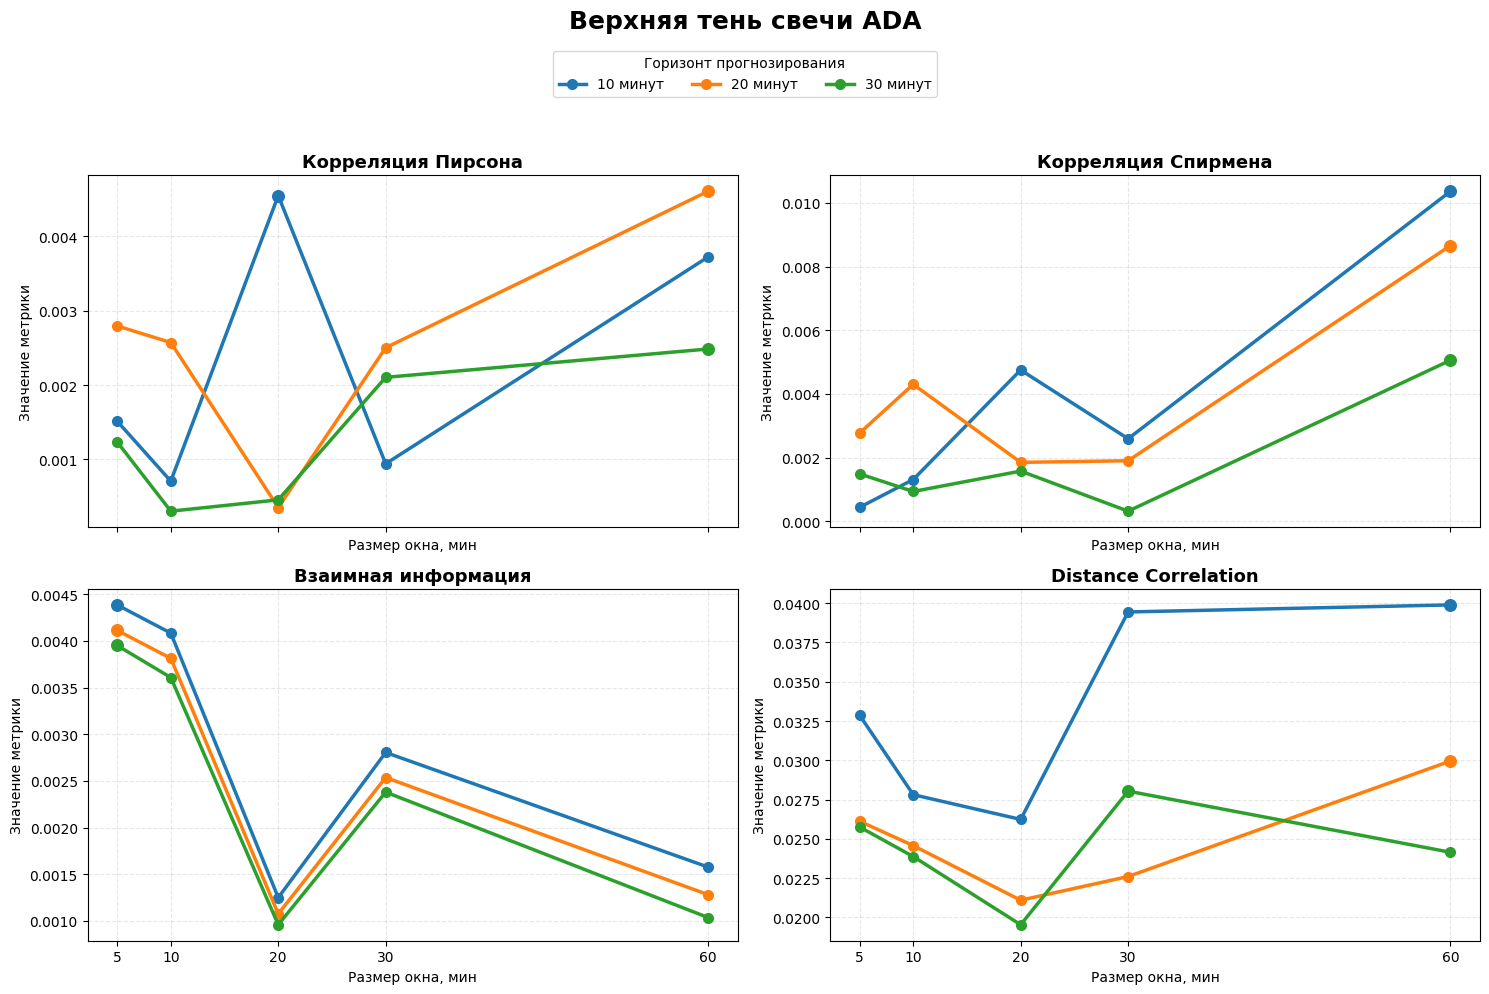

Нижняя тень свечи ADA


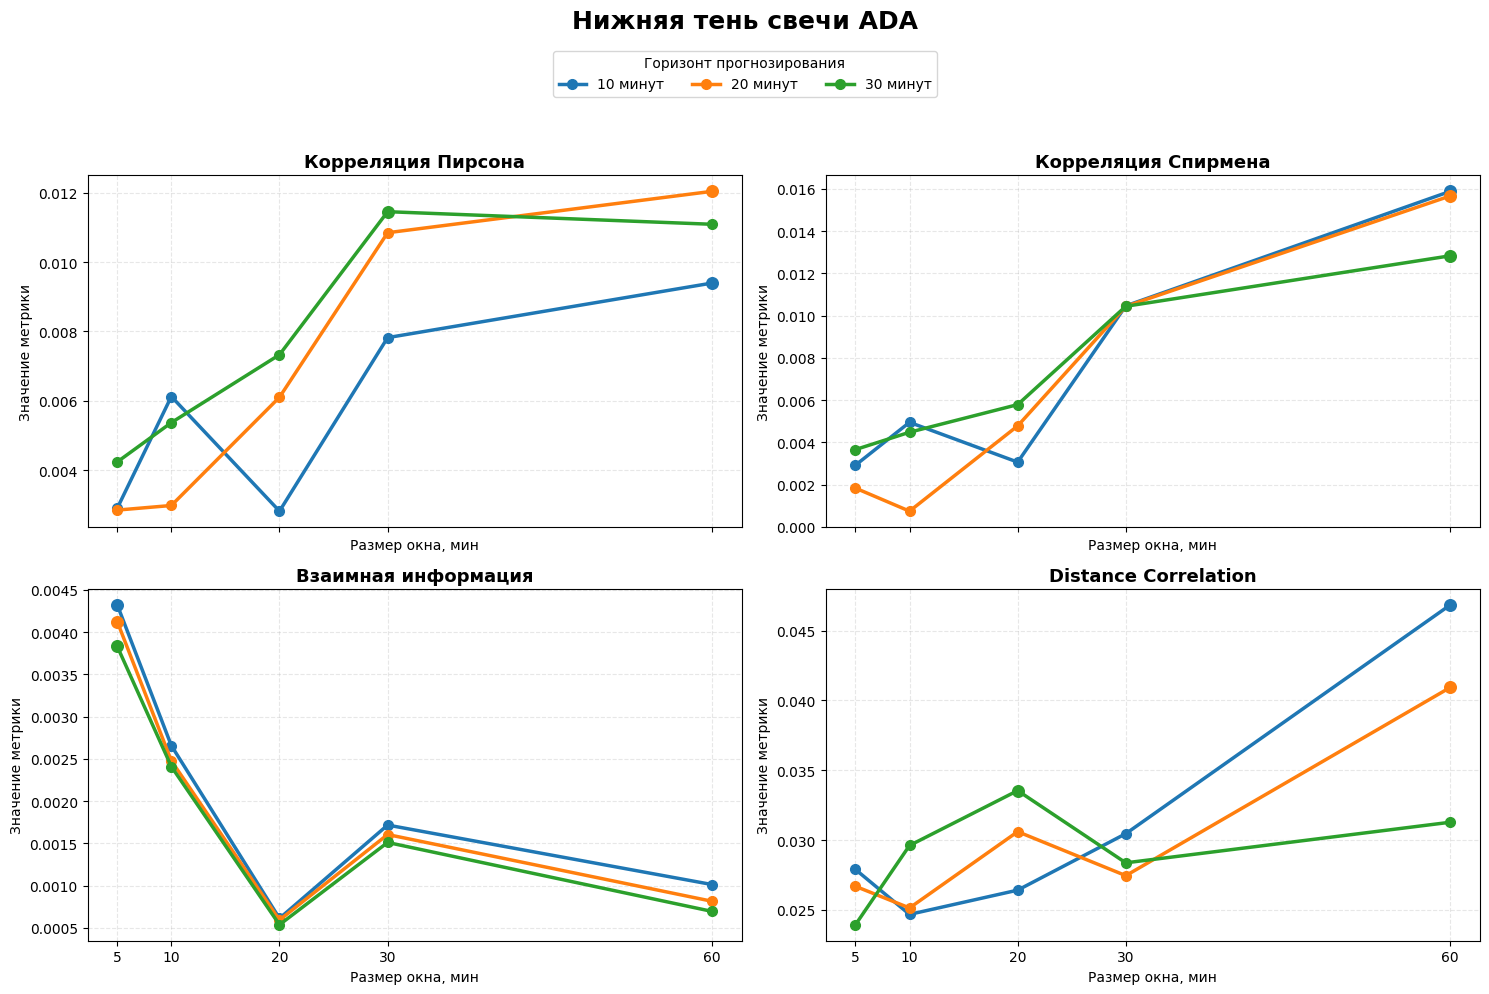

Отношение Close к High ADA


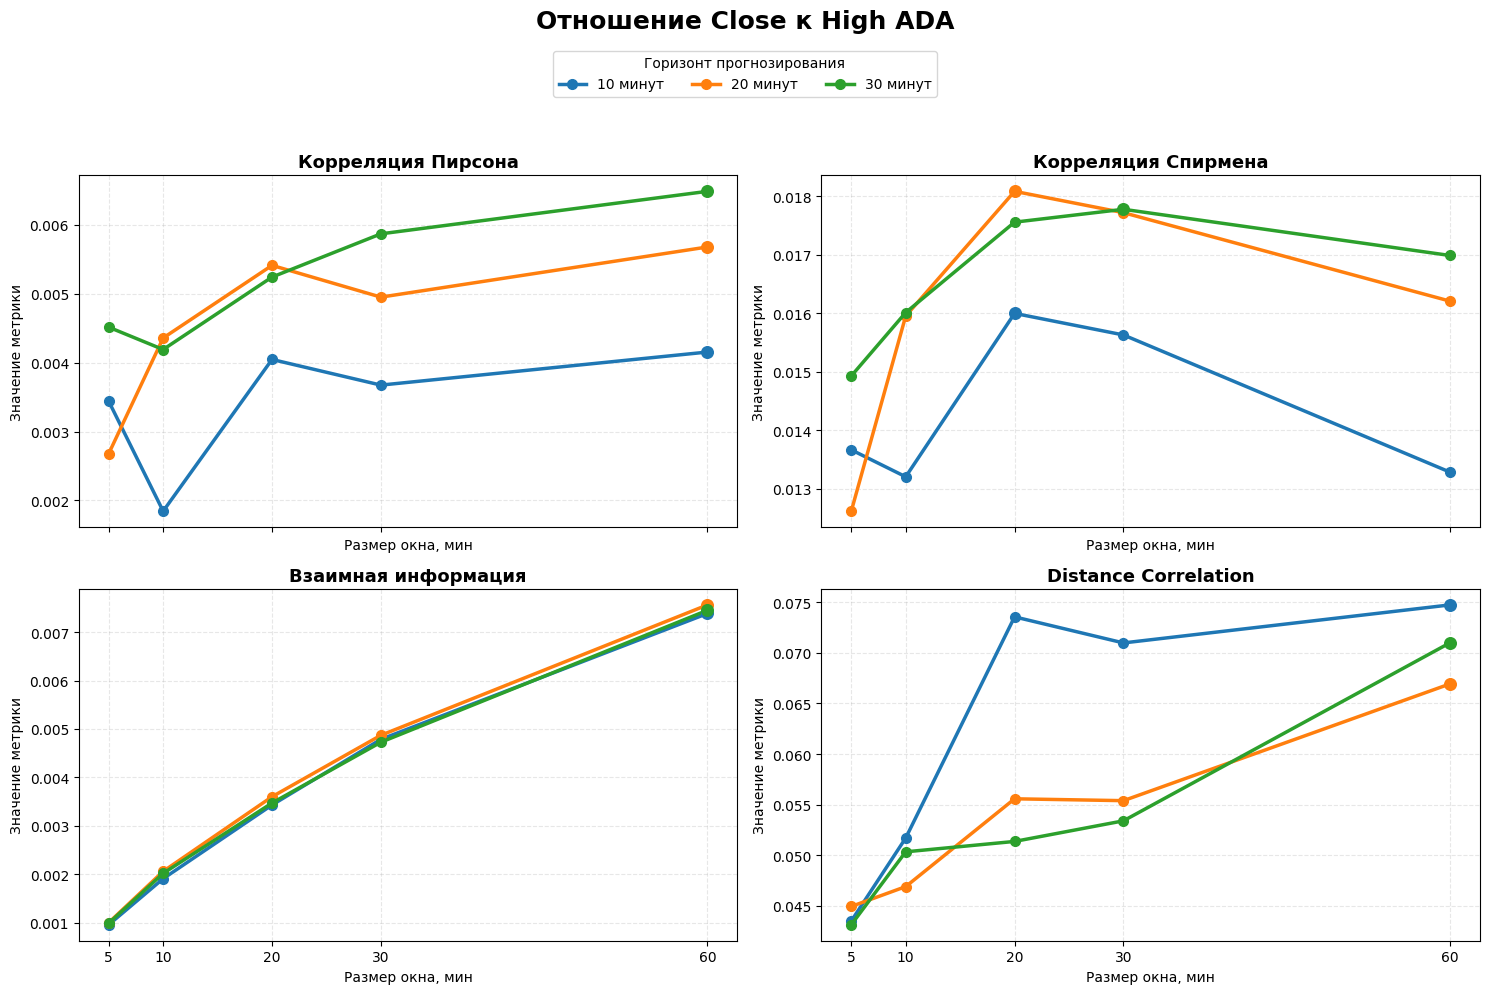

Логарифмический диапазон ADA


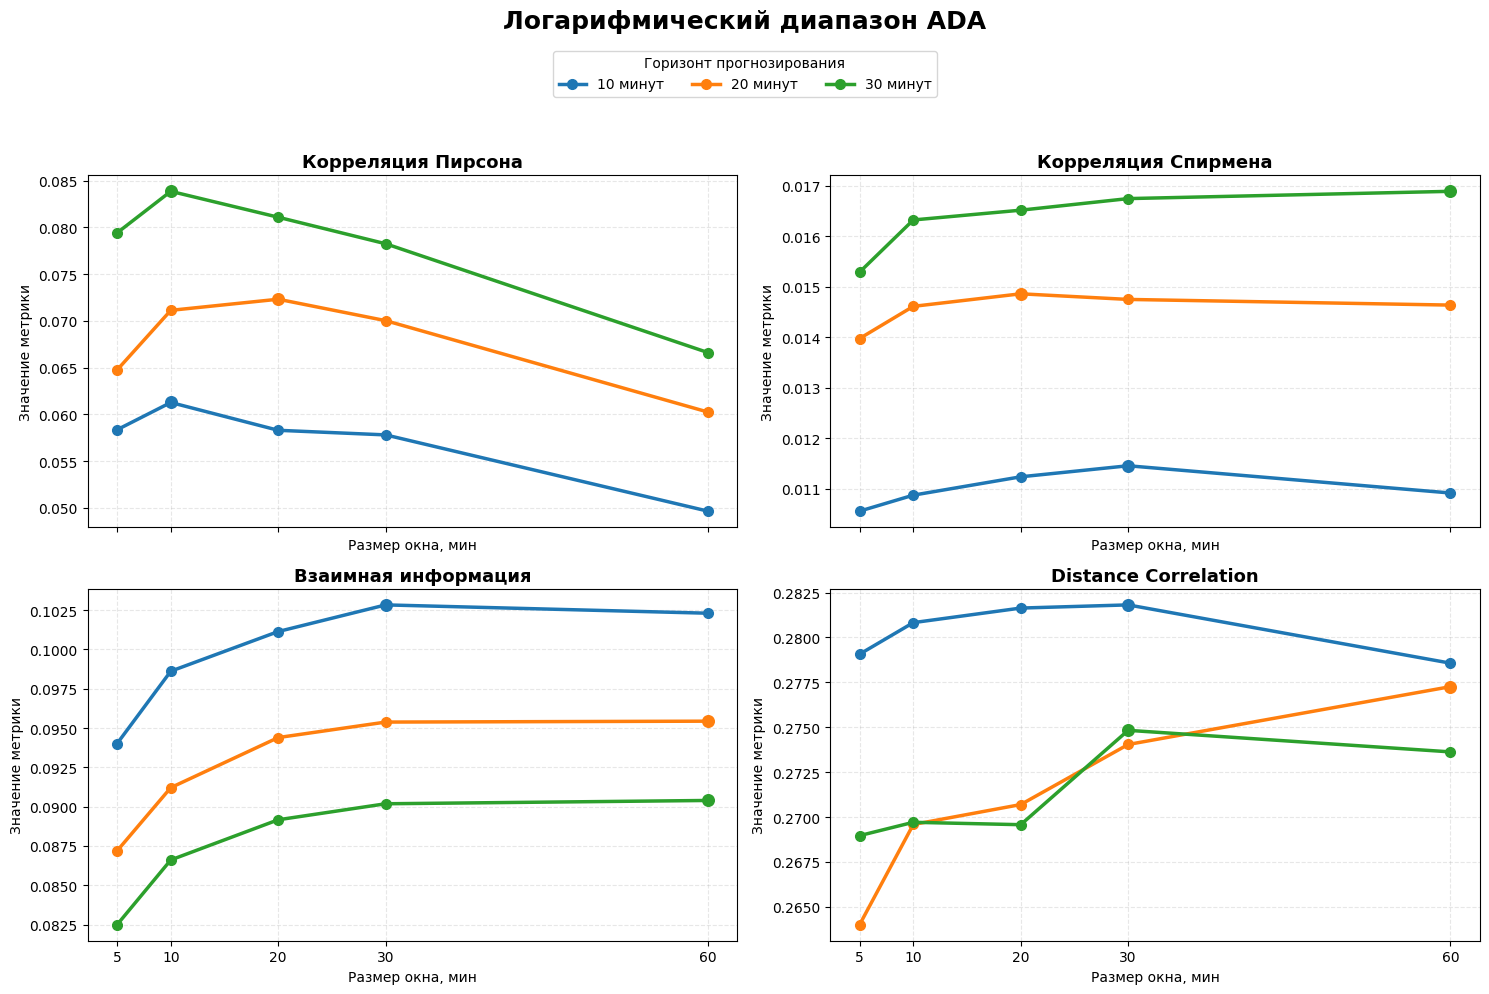

Объем торгов ADA


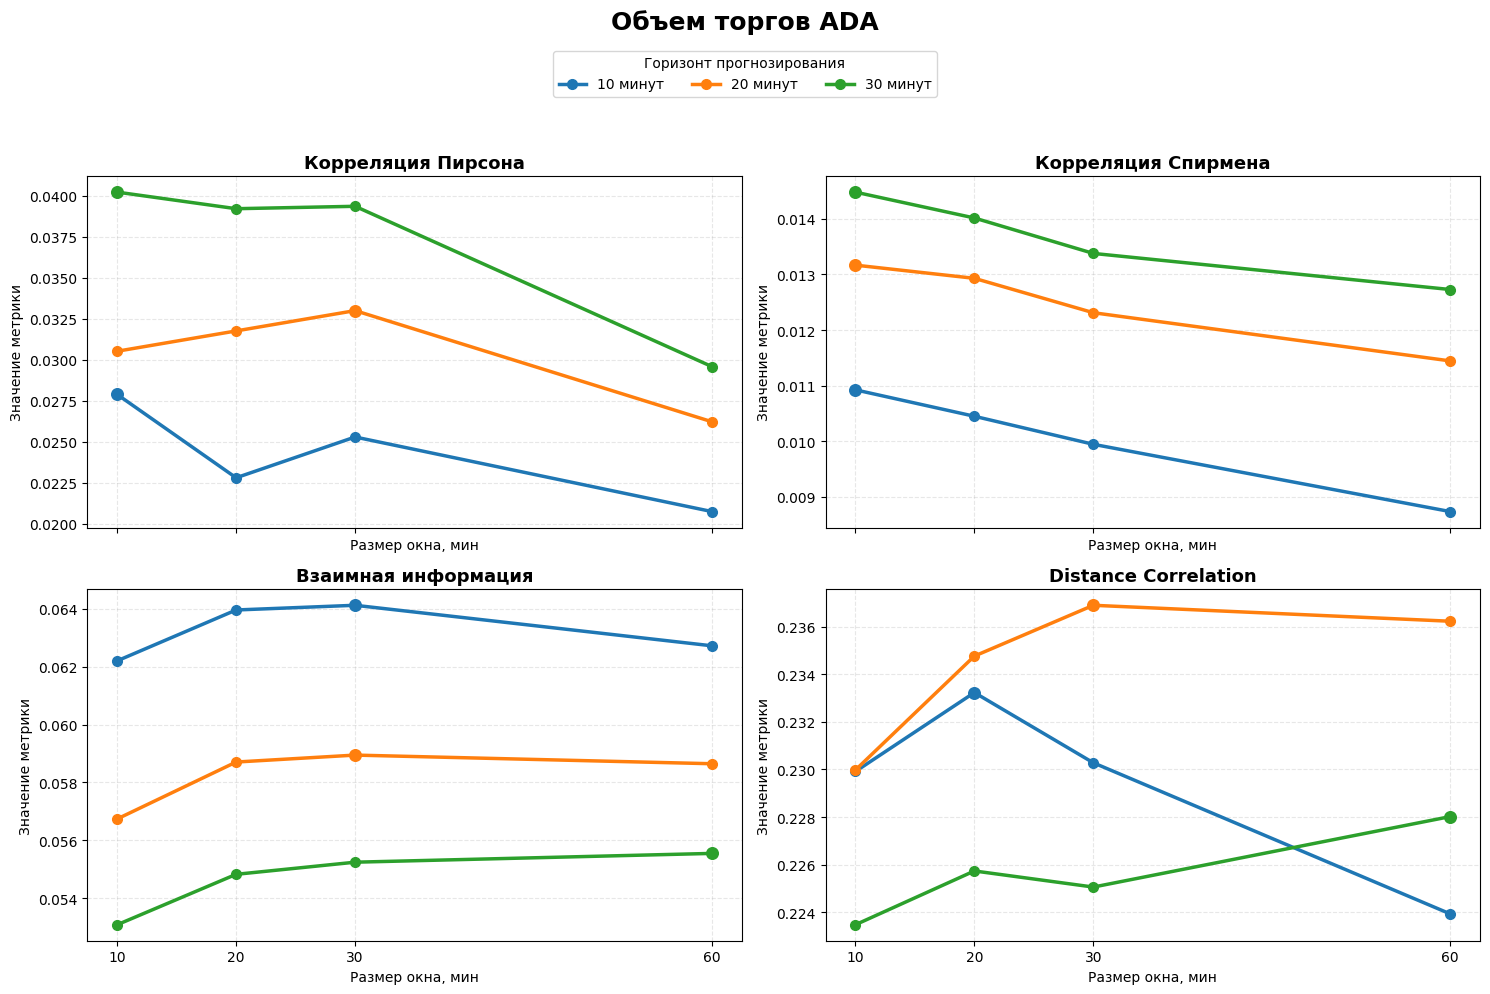

Z-score объема ADA


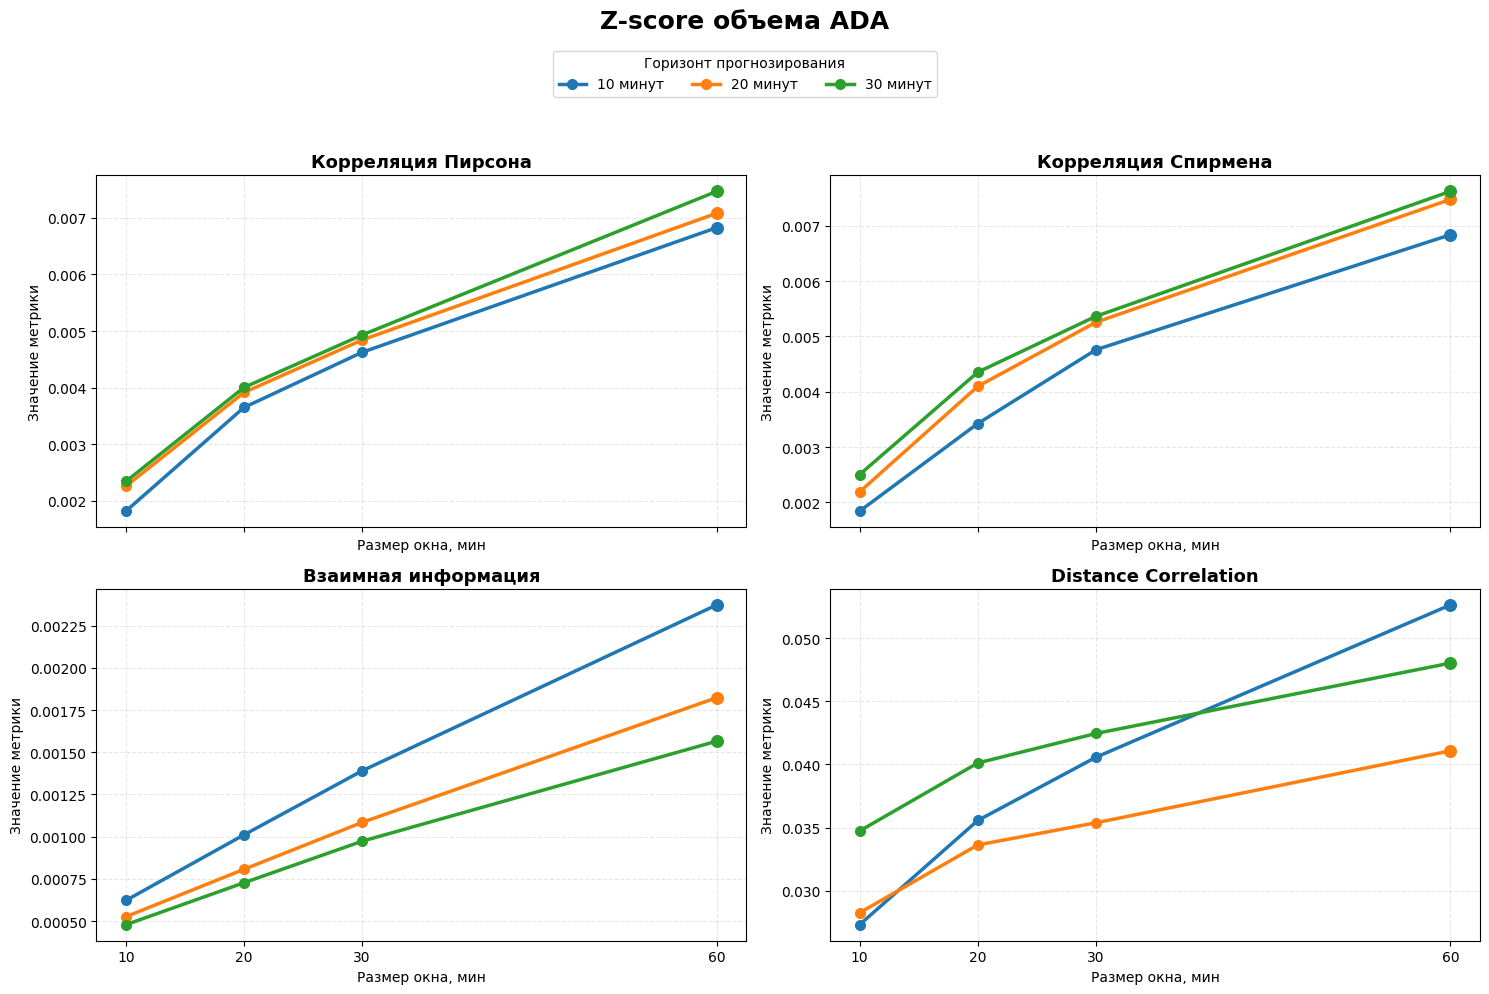

Количество сделок ADA


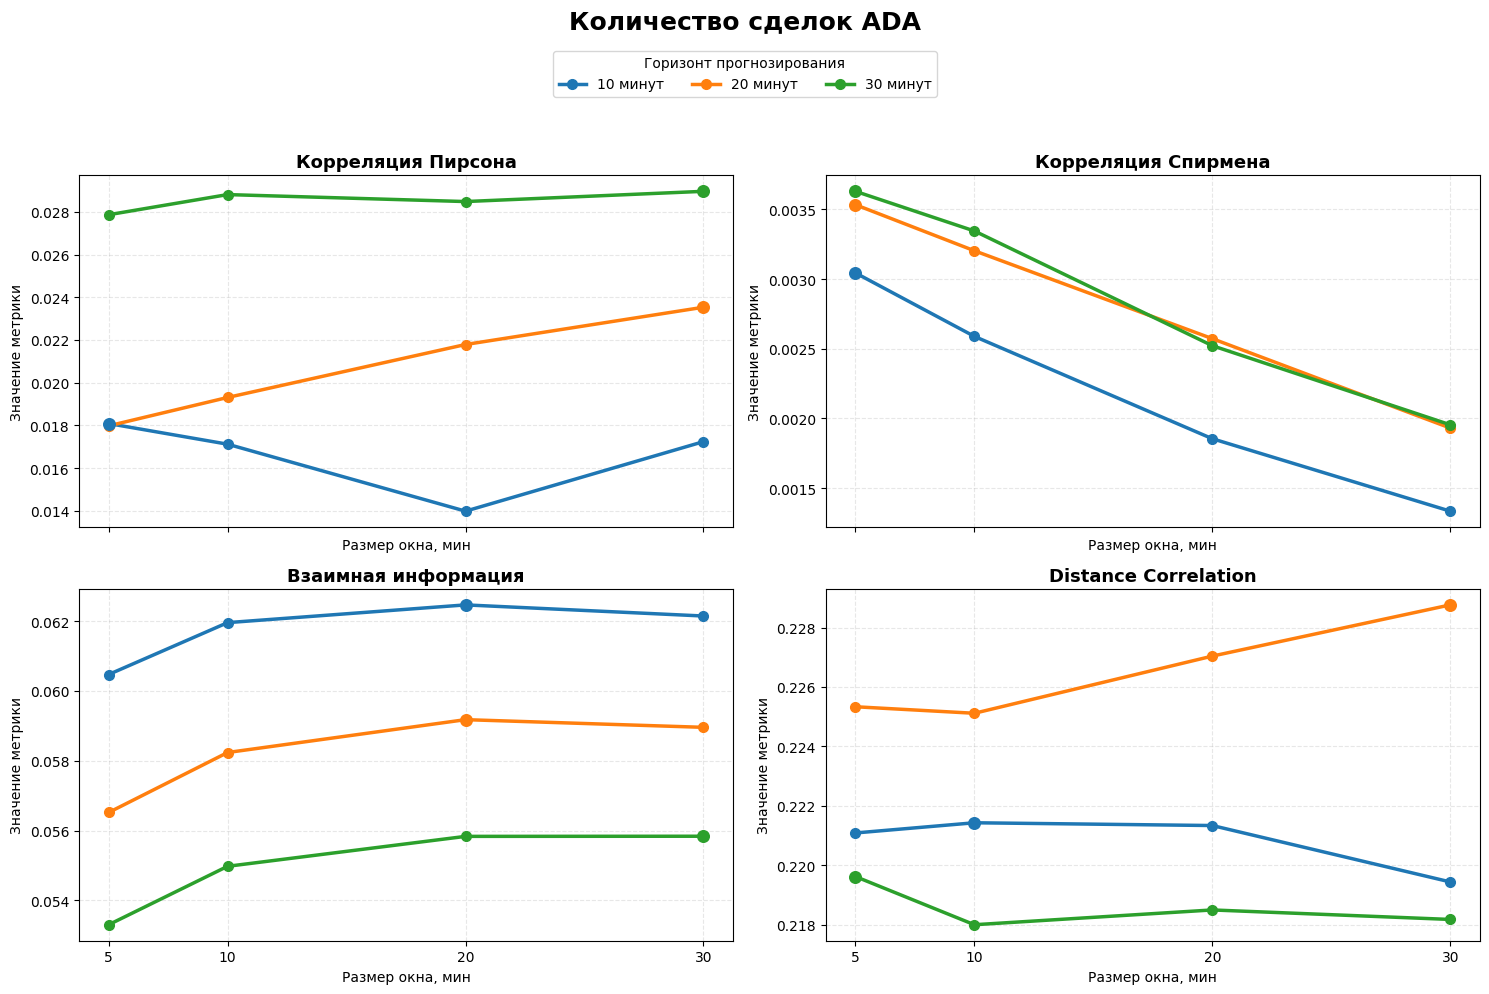

Дисбаланс агрессивных сделок ADA


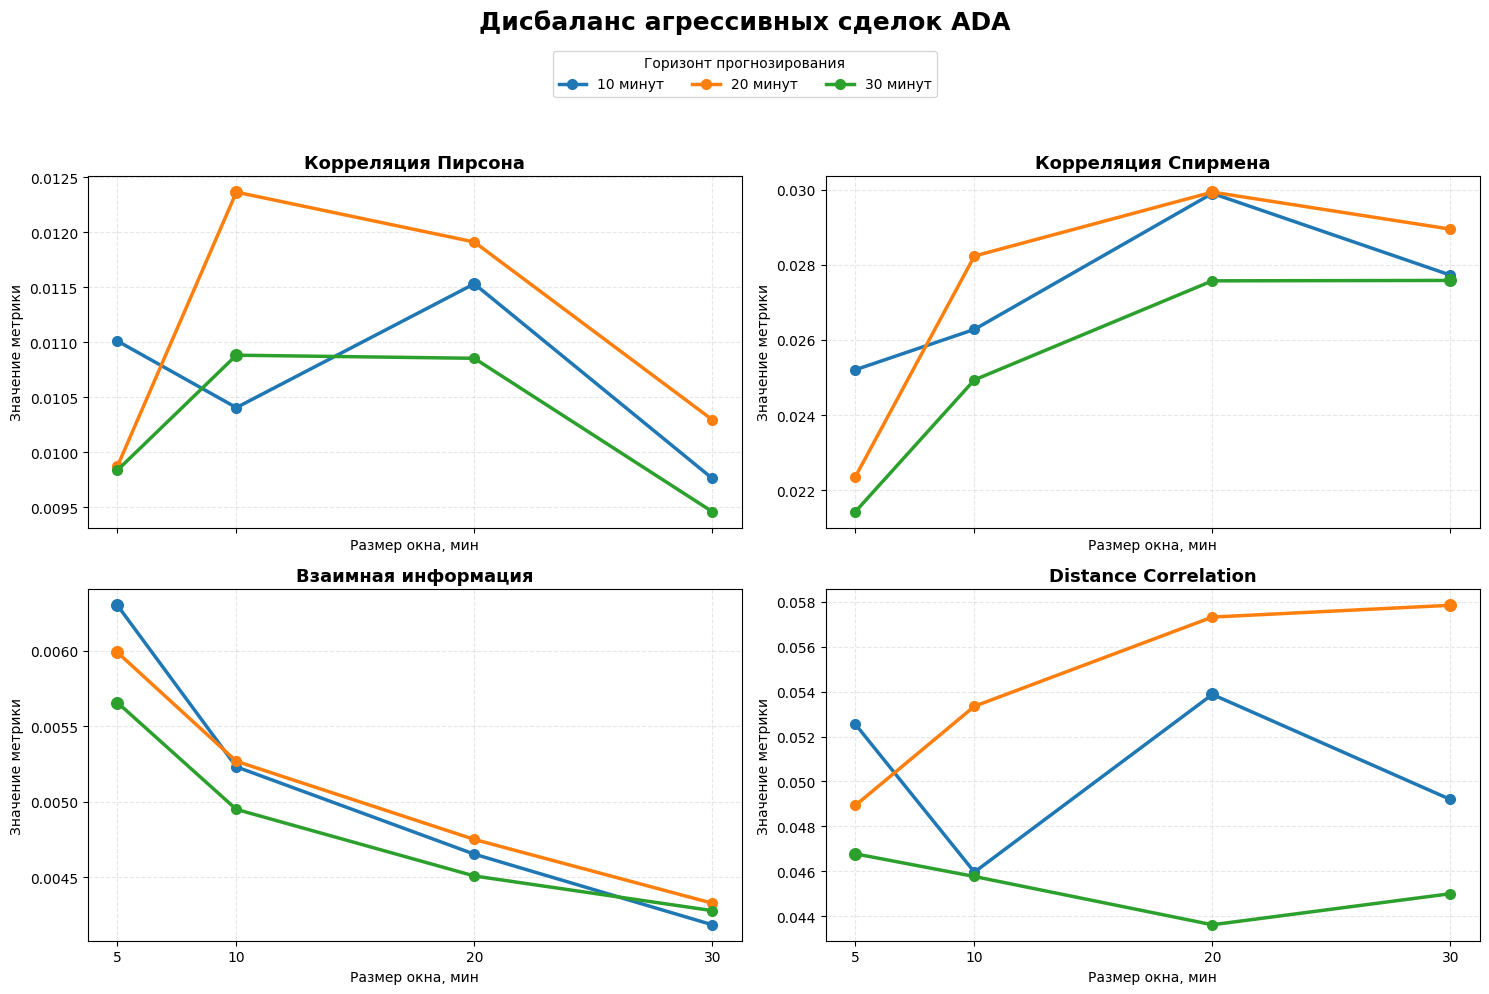

Дисбаланс крупных агрессивных сделок ADA


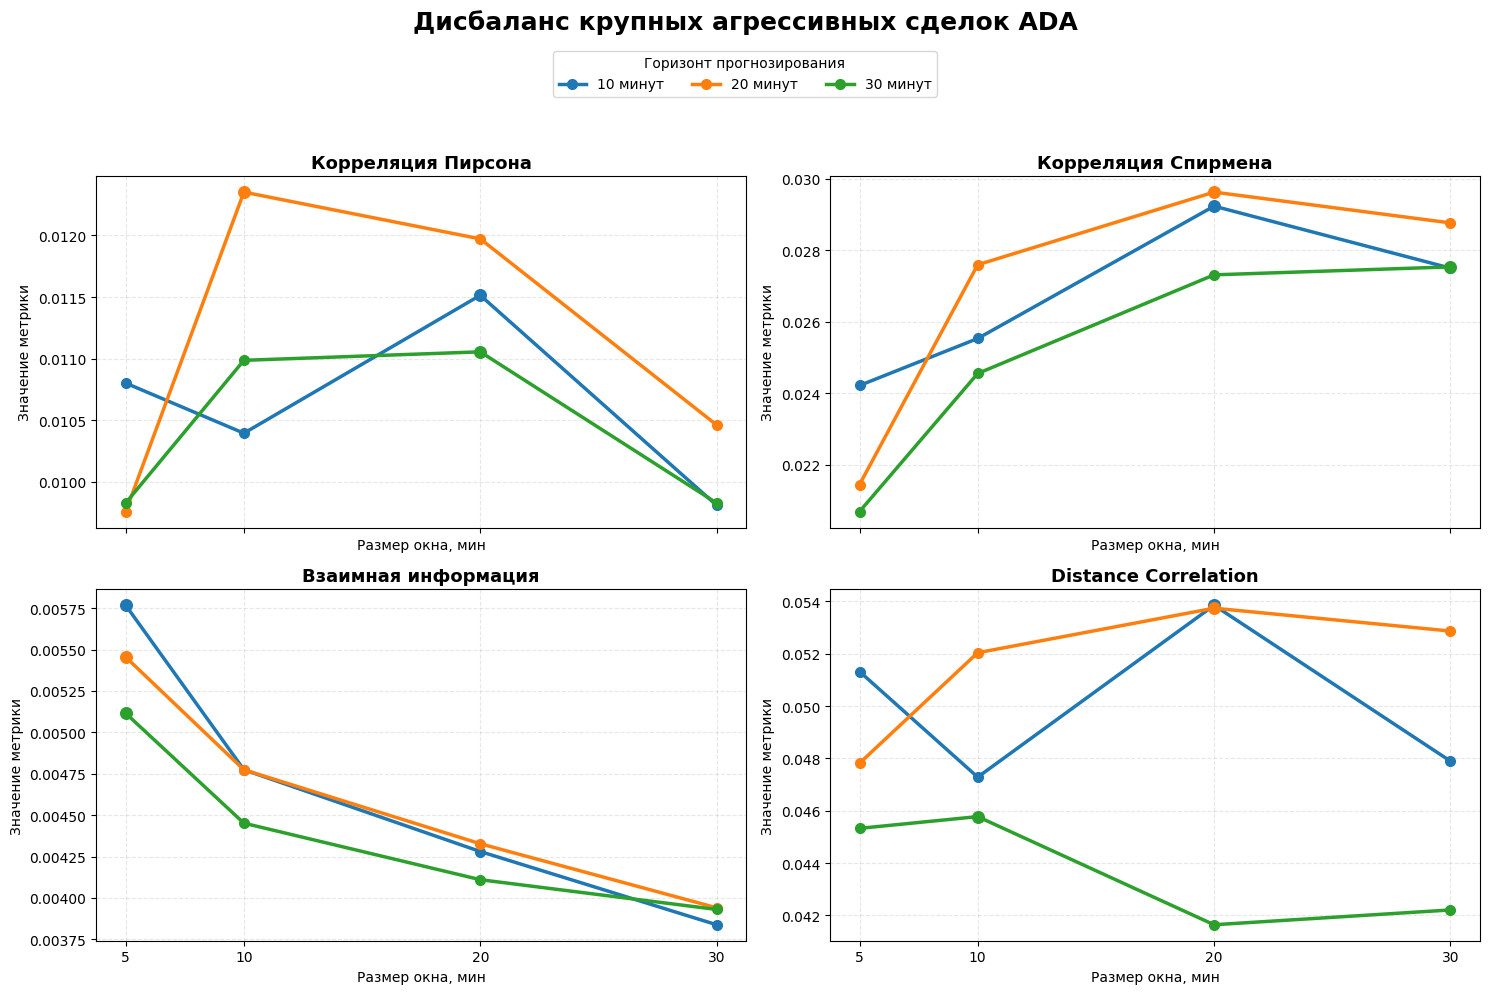

Энтропия объемов ADA


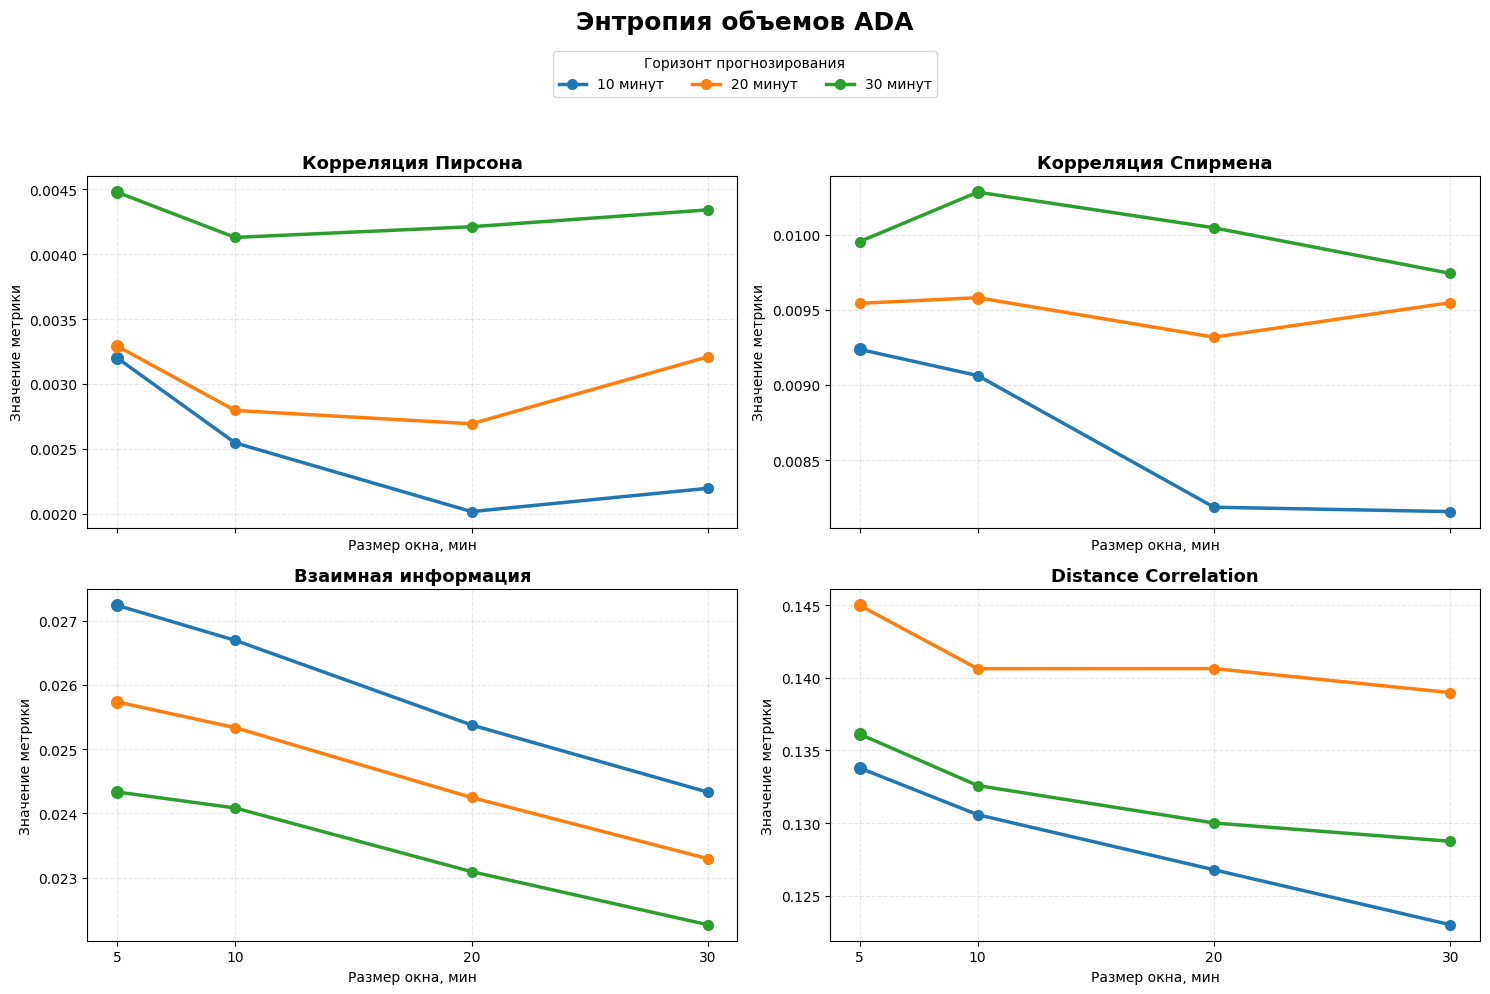

Индекс Симпсона ADA


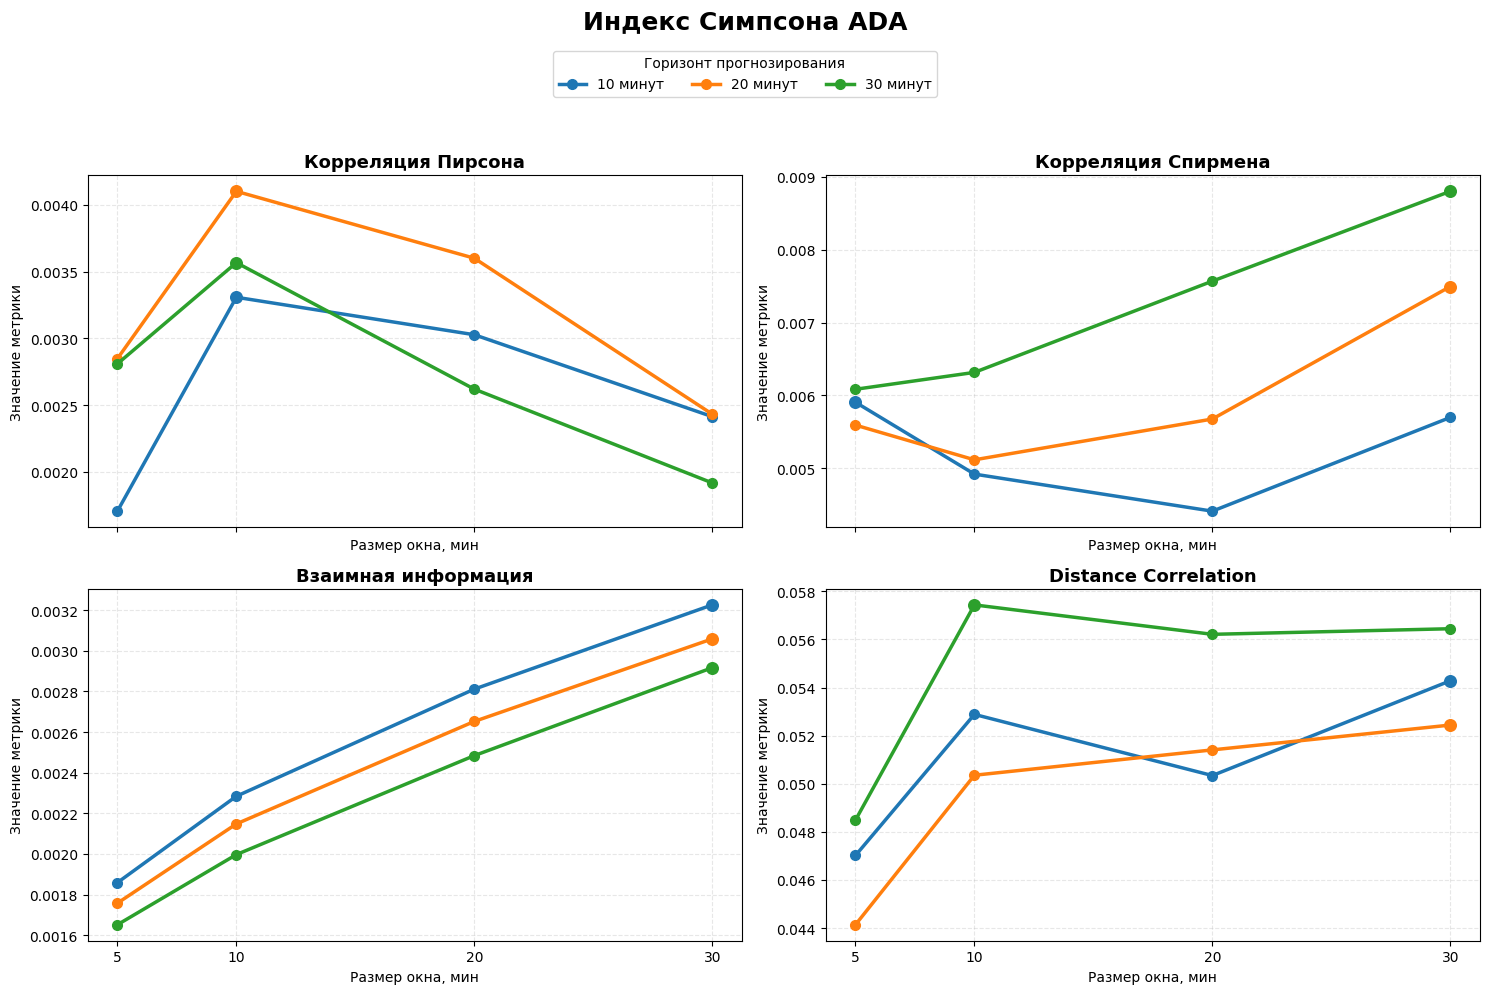

Средний размер сделки ADA


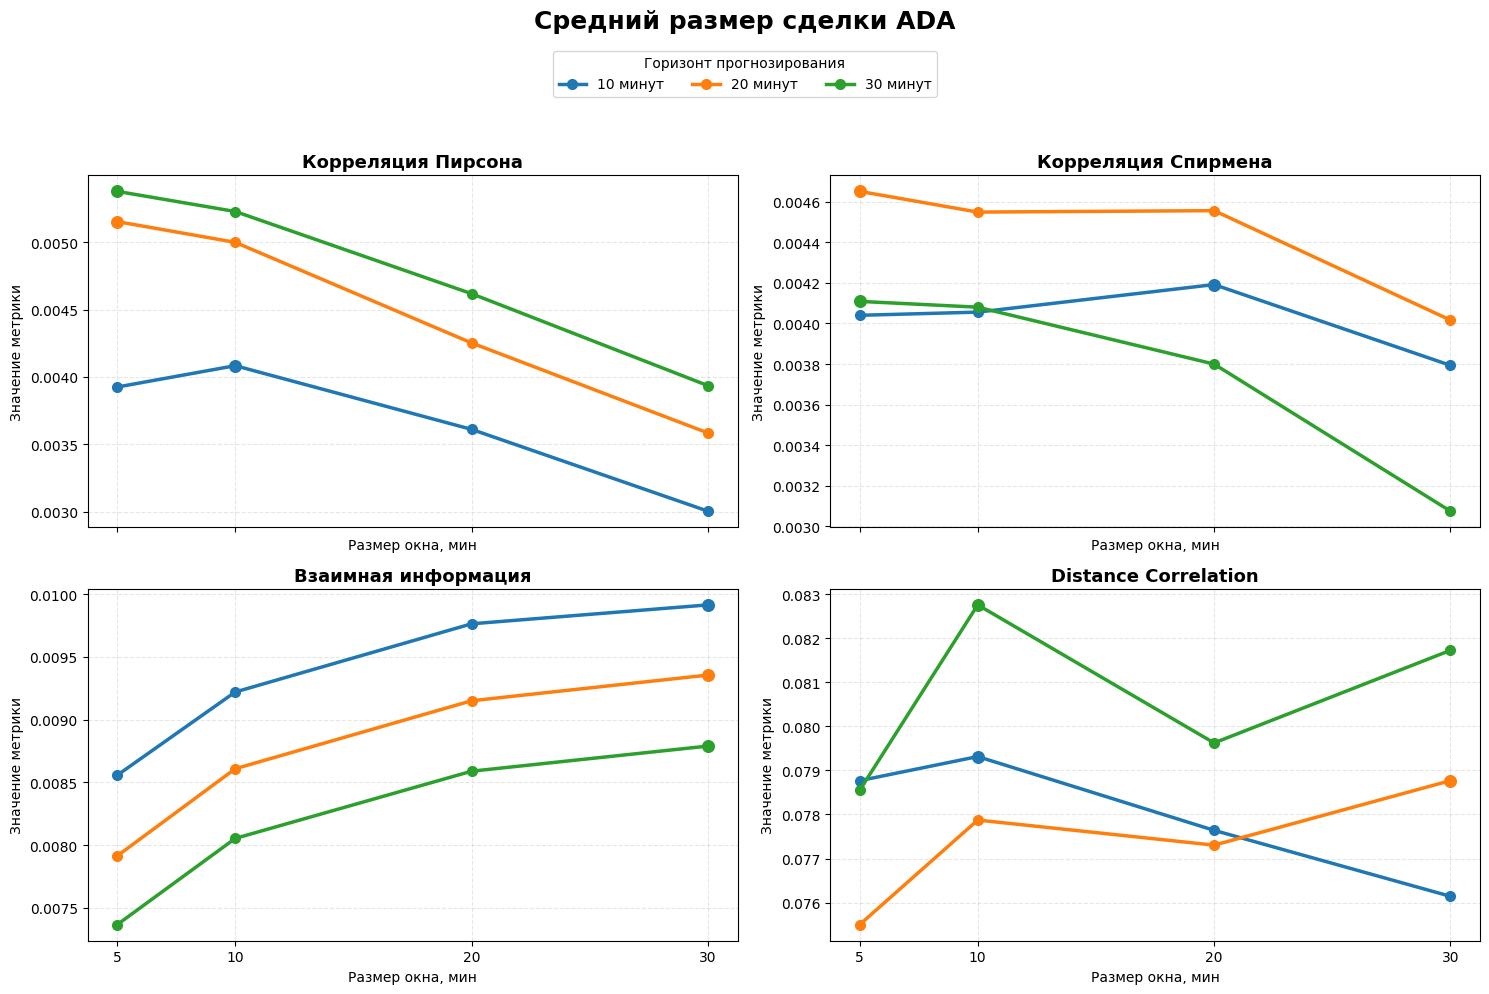

Концентрация торгового давления ADA


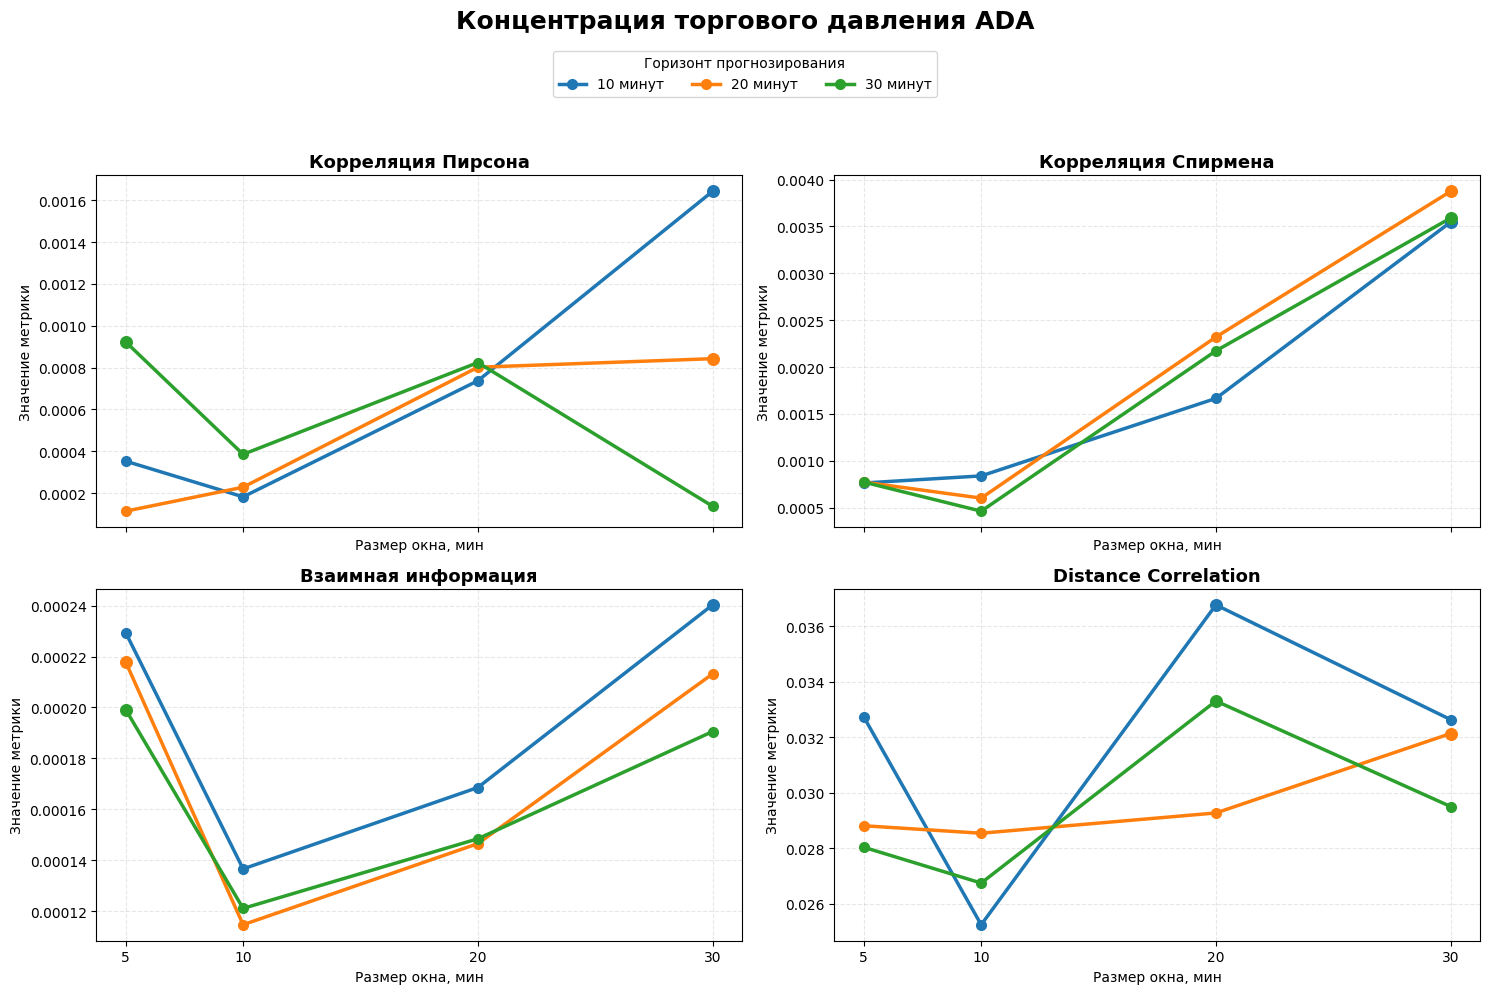

Доходность BTC


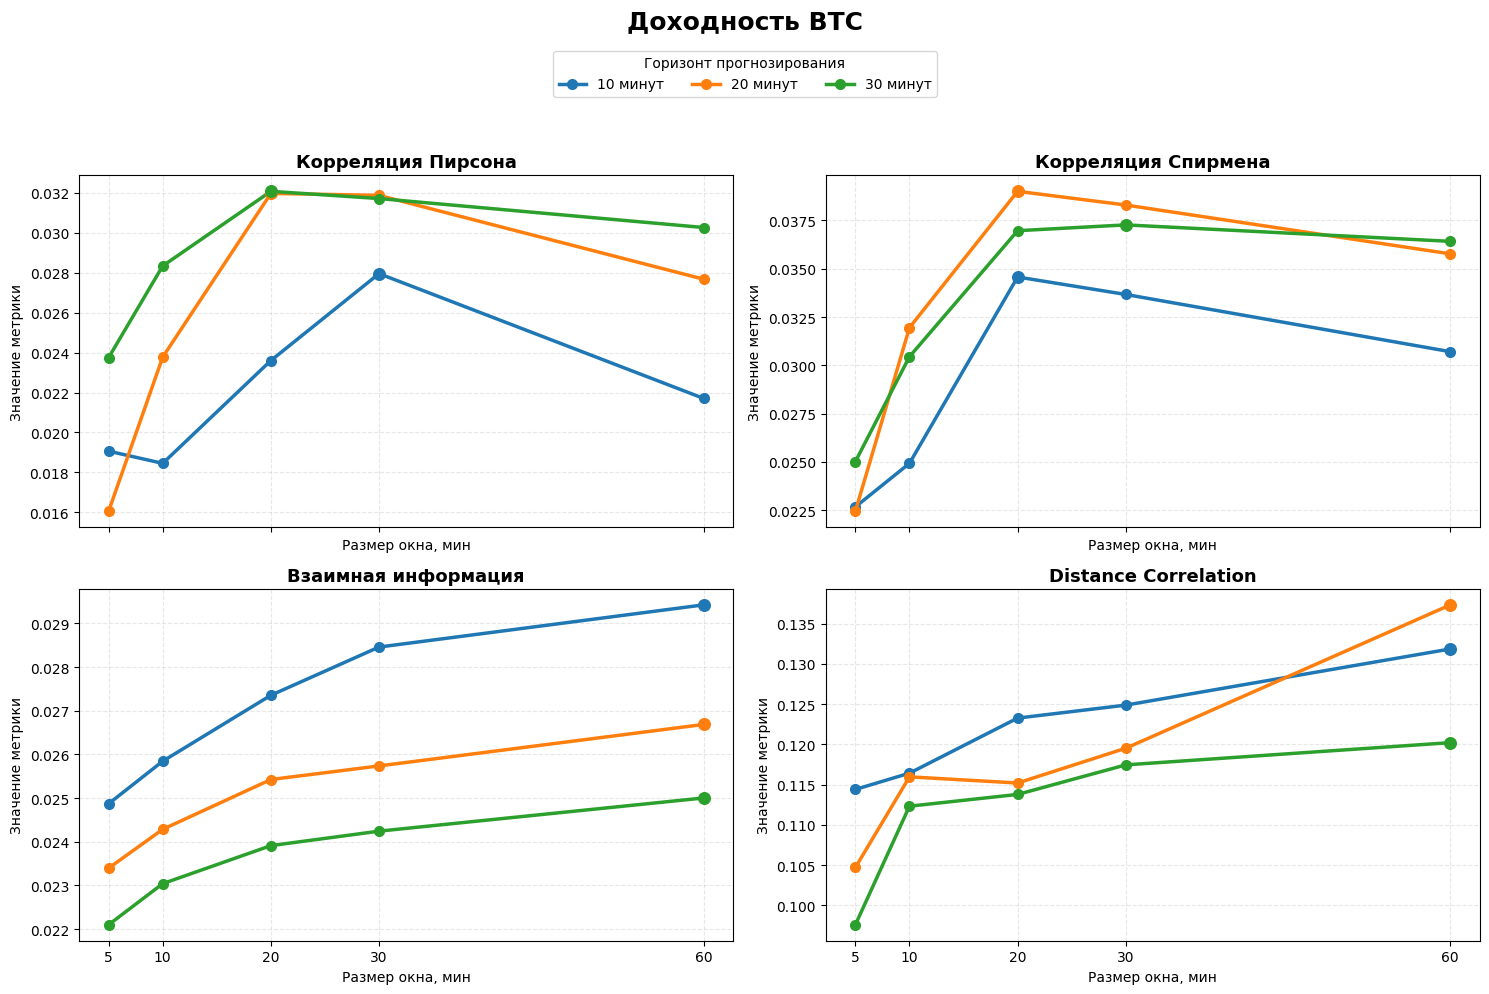

Волатильность BTC


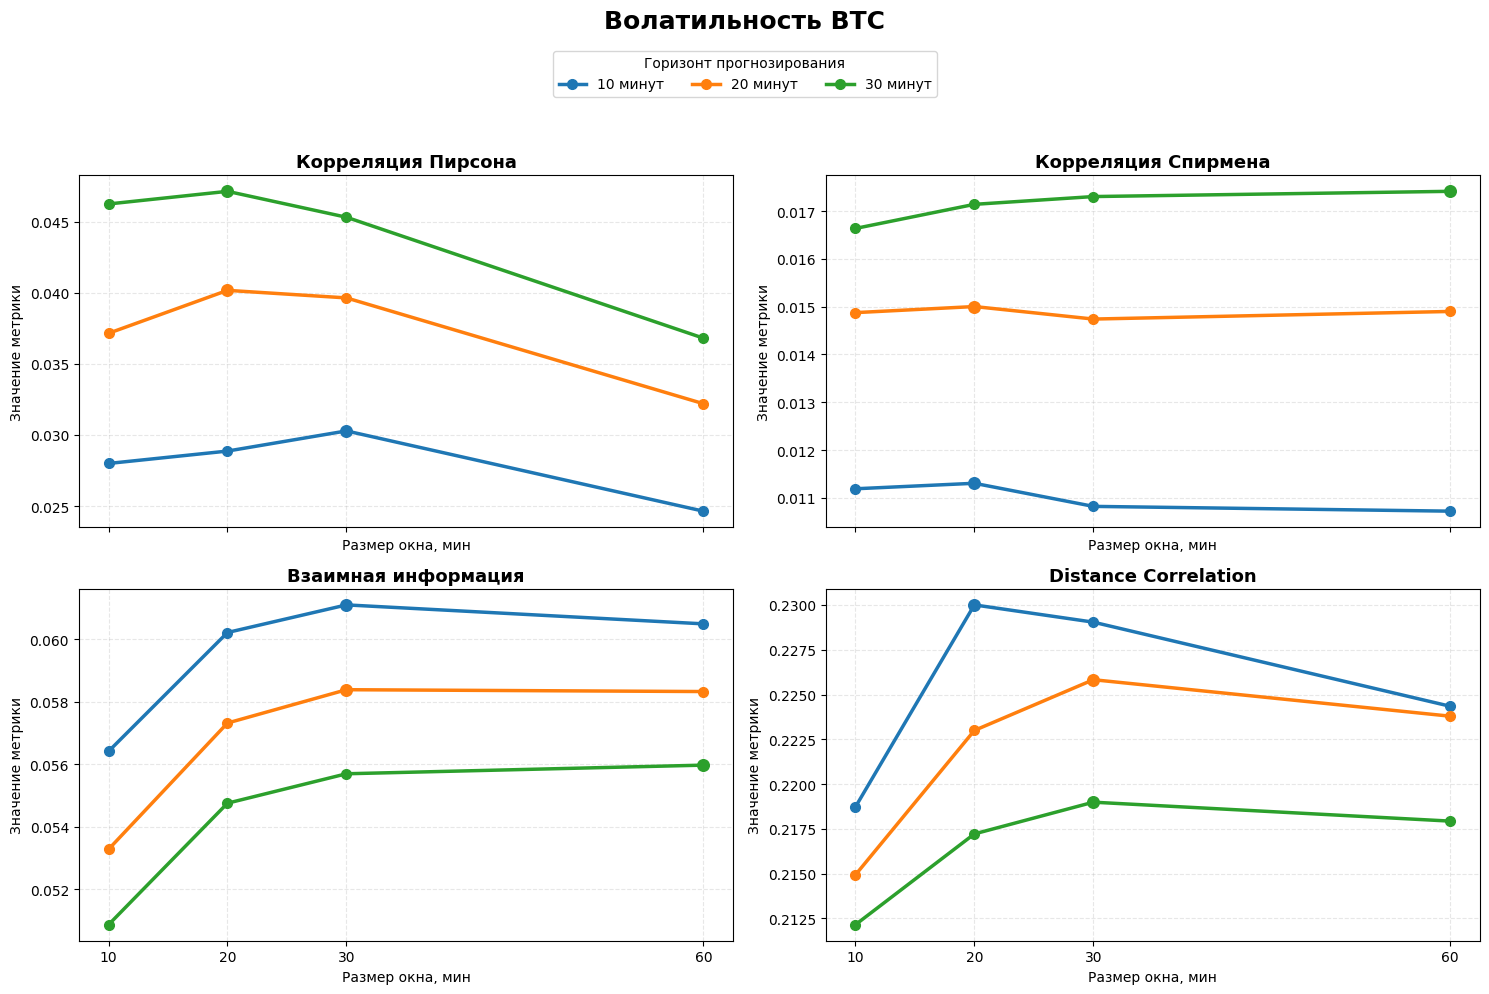

Коэффициент эффективности Кауфмана BTC


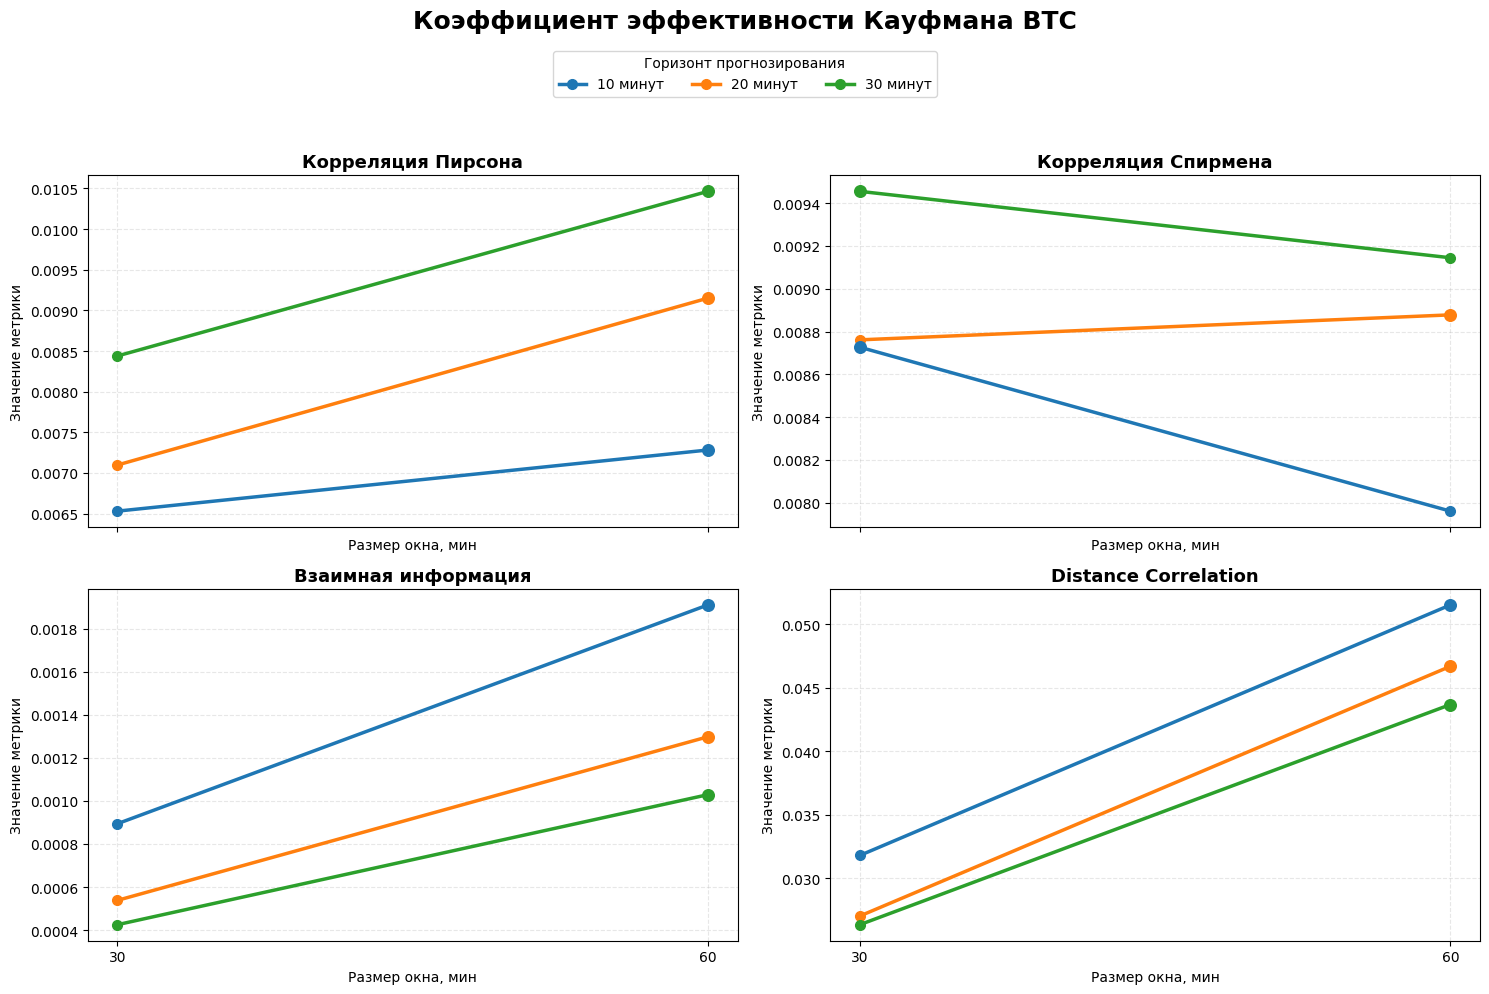

In [23]:
for family in WINDOW_FAMILIES:

    print("=" * 120)
    print(FAMILY_NAMES.get(family, family))
    print("=" * 120)

    plot_family_raw(
        scored_metrics,
        family,
        # normalize=True,
    )